**Project Name:** Mushroom Farm Monitoring System (SMC)

**Company:** South Mill Champs

**Professor:** Dra. María de la Paz Rico

**Team 27:**

Arantxa Stephania Coronel González A01620352

Roberto Ferro Salinas A01374849

Eduardo Rodrigo Silva Orozco A0179593

# **Initializate and Import Libraries**

In [ ]:
# Mount Google Drive to access project files
from google.colab import drive
import os

In [ ]:
import time
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Stats
from scipy.stats import skew
# Scikit-learn: model selection
from sklearn.model_selection import train_test_split, GridSearchCV
# Scikit-learn: preprocessing / feature engineering
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
# Scikit-learn: models (individual)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
# Scikit-learn: models (ensembles)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    VotingRegressor,
    StackingRegressor,
)
# Scikit-learn: metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Scikit-learn: interpretability
from sklearn.inspection import permutation_importance

# **Phase 1. Exploratory Data Analysis**

This first phase focuses on conducting an Exploratory Data Analysis (EDA) to understand the structure, quality, and main characteristics of the dataset. Statistical summaries and visualization techniques (univariate and multivariate analysis) are used to identify relevant patterns, trends, and relationships between variables.

During this stage, preprocessing decisions are applied and justified, including the treatment of missing values, outliers, skewed distributions, and high-cardinality categorical variables. Potential correlations, class imbalance, and temporal patterns (if applicable) are also examined.

The insights obtained from the EDA guide subsequent modeling decisions and ensure that the project is built on a solid understanding of the data. Results are documented and shared through a GitHub repository to promote transparency and reproducibility.

## Raw Data Structure

An overall description of the data structure and data types is included. Descriptive statistics are obtained for all variables in the dataset. For categorical variables, class frequencies are determined. Missing values are identified.

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the Excel file name and the root folder to search within Drive
file_name = 'Flush Yield 2025 - Encrypted 2.xlsx'
search_root = '/content/drive/MyDrive'

# Search for the file recursively inside Google Drive
file_path = None
for root, dirs, files in os.walk(search_root):
    if file_name in files:
        file_path = os.path.join(root, file_name)
        break

# Raise an error if the file is not found
if file_path is None:
    raise FileNotFoundError(f'The file {file_name} was not found in Google Drive.')

# Print the full path of the located file
print(f'File found at: {file_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found at: /content/drive/MyDrive/Flush Yield 2025 - Encrypted 2.xlsx


In [ ]:
df = pd.read_excel(file_path, header=[0, 1, 2])
# Flatten the multi-index columns into a single string name
df.columns = ['_'.join(str(level) for level in col if 'Unnamed' not in str(level)).strip('_') for col in df.columns]

# Basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (266, 72)


,SerialKey,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,...,3rd Flush_total hours,3rd Flush_lbs/hr,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/hour,Total_lbs/sqft,Total_lbs/ton,Total_Target,"Room Finished ( Type ""Y"" when finished)"
0,CT001,15.359838,0.0129,6.7,4673,NaN,434,39.26,28,39260,...,NaN,NaN,0.78,93.24,33212.69,NaN,7.11,845.97,820,Y
1,CT002,14.925547,0.0126,7.08,4673,NaN,434,41.37,26,41370,...,NaN,NaN,0.73,82.12,32741.15,NaN,7.01,791.42,820,Y
2,CT003,15.800000,1.3%/1.22%,7.81/9.16,4643,1.4,431,38.89,32,38890,...,NaN,NaN,0.97,116.35,31991.59,NaN,6.89,822.62,820,Y
3,CT004,14.700000,0.0122,9.16,4673,NaN,434,39.79,27,39790,...,NaN,NaN,0.84,98.72,32193.04,NaN,6.89,809.07,820,Y
4,CT005,15.200000,0.0127,8.15,4673,NaN,434,38.69,27,38690,...,NaN,NaN,0.84,101.38,29322.94,NaN,6.27,757.89,820,Y


In [ ]:
# Display the general structure of the dataset, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   SerialKey                                     175 non-null    object        
 1   Compost Information_Spawn Rate                60 non-null     float64       
 2   Compost Information_Supplement Rate           69 non-null     object        
 3   Compost Information_Water Added               68 non-null     object        
 4   Farm Filling Information_Sqft Filled          266 non-null    int64         
 5   Farm Filling Information_Missing Sections     87 non-null     float64       
 6   Farm Filling Information_Sqm Filled           266 non-null    int64         
 7   Farm Filling Information_Tons                 174 non-null    float64       
 8   Farm Filling Information_Filled heights (cm)  175 non-null    object  

**Identification of missing values**

In [ ]:
# Calculate the number and percentage of missing values per variable
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing_Count', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Total_lbs/hour,266,100.0
2nd Flush_lbs/hr,266,100.0
3rd Flush_lbs/hr,266,100.0
3rd Flush_total hours,266,100.0
1st Flush_Total Hours,266,100.0
...,...,...
3rd Flush_lbs/sqft,0,0.0
Total_lbs,0,0.0
Total_lbs/sqft,0,0.0
Total_lbs/ton,0,0.0


**Separation of numerical and categorical variables**

In [ ]:
# Identify numerical, datetime, and categorical variables based on data types
numerical_vars = df.select_dtypes(include=[np.number]).columns
datetime_vars = df.select_dtypes(include=['datetime64[ns]']).columns
categorical_vars = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

# Display the number and names of numerical variables
print(f"Number of numerical variables: {len(numerical_vars)}")
print("\nNumerical variables:")
for var in numerical_vars:
    print(f"- {var}")

# Display the number and names of datetime variables
print(f"\nNumber of datetime variables: {len(datetime_vars)}")
print("\nDatetime variables:")
for var in datetime_vars:
    print(f"- {var}")

# Display the number and names of categorical variables
print(f"\nNumber of categorical variables: {len(categorical_vars)}")
print("\nCategorical variables:")
for var in categorical_vars:
    print(f"- {var}")

Number of numerical variables: 56

Numerical variables:
- Compost Information_Spawn Rate
- Farm Filling Information_Sqft Filled
- Farm Filling Information_Missing Sections
- Farm Filling Information_Sqm Filled
- Farm Filling Information_Tons
- Farm Filling Information_Filled kg
- Farm Filling Information_Fill rate kg/m²
- Stagger/Pincount Info_Picking Day_Actual
- Stagger/Pincount Info_Picking Day_Target
- Stagger/Pincount Info_Pin Count_Actual
- Stagger/Pincount Info_Pin Count_Target
- Stagger/Pincount Info_Stagger_Actual
- Stagger/Pincount Info_Stagger_Target
- Watering_Water Applied (L)_1st Flush
- Watering_Water Applied (L)_2nd Flush
- Watering_Water Applied (L)_3rd Flush
- Watering_Water Applied (L)_Total (L)
- 1st Flush_Day 1
- 1st Flush_Sep lbs
- 1st Flush_Day 2
- 1st Flush_Sep lbs
- 1st Flush_Day 3
- 1st Flush_Day 4
- 1st Flush_Day 5
- 1st Flush_Day 6
- 1st Flush_Day 7
- 1st Flush_Total Hours
- 1st Flush_lbs/hr
- 1st Flush_lbs/sqft
- 2nd Flush_Day 1
- 2nd Flush_Day 2
- 2nd Flus

**Descriptive statistics for numerical variables**

In [ ]:
# Compute descriptive statistics for all numerical variables
numerical_description = df[numerical_vars].describe().T
numerical_description

,count,mean,std,min,25%,50%,75%,max
Compost Information_Spawn Rate,60.0,15.051961,0.819046,13.292673,14.587278,15.015348,15.710668,17.187976
Farm Filling Information_Sqft Filled,266.0,4568.522556,433.085823,2077.000000,4630.000000,4673.000000,4673.000000,4673.000000
Farm Filling Information_Missing Sections,87.0,14.774713,32.958050,1.000000,2.000000,2.000000,2.000000,120.000000
Farm Filling Information_Sqm Filled,266.0,424.300752,40.211513,193.000000,430.000000,434.000000,434.000000,434.000000
Farm Filling Information_Tons,174.0,37.237874,4.829647,15.960000,36.532500,38.185000,39.380000,45.750000
Farm Filling Information_Filled kg,266.0,24358.609023,18169.546114,0.000000,0.000000,36430.000000,38905.000000,45750.000000
Farm Filling Information_Fill rate kg/m²,266.0,58.086502,42.489120,0.000000,0.000000,85.043201,90.156850,105.382624
Stagger/Pincount Info_Picking Day_Actual,175.0,15.754286,0.559322,14.000000,15.000000,16.000000,16.000000,18.000000
Stagger/Pincount Info_Picking Day_Target,266.0,16.000000,0.000000,16.000000,16.000000,16.000000,16.000000,16.000000
Stagger/Pincount Info_Pin Count_Actual,168.0,84.047619,14.586438,45.000000,75.750000,83.000000,91.000000,140.000000


## Preprocessing

Strategies for handling missing values, outliers, and high cardinality (if applicable) are implemented and justified.

In [ ]:
# Track initial dataset shape
initial_shape = df.shape

# Remove columns with all missing values
cols_all_missing = df.columns[df.isnull().mean() == 1.0].tolist()
df_cleaned = df.drop(columns=cols_all_missing)

# Remove identifier and control columns
removed_id_cols = ['SerialKey', 'Room Finished ( Type "Y" when finished)']
df_cleaned = df_cleaned.drop(columns=removed_id_cols, errors='ignore')

# Identify rows where all values are effectively zero (0 or NaN)
initial_rows_before_sparse_removal = df_cleaned.shape[0]

# Create a boolean mask where True indicates a value is 0 or NaN for each cell in df_cleaned.
# This ensures consistency by operating solely on df_cleaned and handles object types gracefully.
# For object columns, comparison with `0` will usually result in False or an explicit error.
# We explicitly handle potential non-boolean results from `df_cleaned == 0` by converting to boolean.
is_zero_or_nan_mask = (df_cleaned == 0).fillna(False).astype(bool) | df_cleaned.isnull()

# Count the number of non-effectively-zero values per row
# (~x) inverts the boolean Series (row) to count values that are NOT (0 or NaN).
non_empty_value_counts = is_zero_or_nan_mask.apply(lambda x: (~x).sum(), axis=1)

# Define a threshold for 'sparse' rows (less than 10 non-empty values)
threshold_sparse_rows = 20

# Filter out rows that are 'sparse' based on the threshold
rows_to_remove_sparse_mask = non_empty_value_counts < threshold_sparse_rows
rows_to_drop_sparse_count = rows_to_remove_sparse_mask.sum()
df_cleaned = df_cleaned[~rows_to_remove_sparse_mask] # Keep rows that are NOT sparse

# Reset index after removing rows to ensure unique index for subsequent operations
df_cleaned = df_cleaned.reset_index(drop=True)

print(f"Removed {rows_to_drop_sparse_count} rows where less than {threshold_sparse_rows} values were non-zero or non-NaN.")


# Convert object columns with string errors (like '#DIV/0!' or '-') to numeric ---
# This list now explicitly includes the flush yield columns and total yield.
columns_with_string_errors_to_convert = [
    '1st Flush_Sep %',
    '1st Flush_lbs/ton',
    '2nd Flush_lbs/ton',
    '3rd Flush_lbs/ton',
    'Total_lbs/ton',
    '1st Flush_lbs',
    '2nd Flush_lbs',
    '3rd Flush_lbs',
    'Total_lbs'
]

for col in columns_with_string_errors_to_convert:
    if col in df_cleaned.columns:
        # Convert column to numeric, coercing any errors (like '#DIV/0!' or '-') to NaN
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Identify numerical columns (may include duplicate names)
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Count missing numeric values BEFORE imputation
missing_before = int(df_cleaned[numerical_cols].isnull().sum().sum())

# Impute missing values in numerical variables using the median
for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Outlier treatment using IQR-based capping
outlier_count = 0

for col in numerical_cols:
    # IMPORTANT: df_cleaned[col] may be a DataFrame if column names are duplicated.
    # Convert to NumPy to count outlier values safely in all cases.
    values = np.asarray(df_cleaned[col])

    Q1 = np.nanquantile(values, 0.25)
    Q3 = np.nanquantile(values, 0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall outside the bounds (value-level count)
    outlier_count += int(np.sum((values < lower_bound) | (values > upper_bound)))

    # Apply capping (np.where keeps the structure stable)
    df_cleaned[col] = np.where(
        df_cleaned[col] < lower_bound, lower_bound,
        np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
    )



# Track final dataset shape
final_shape = df_cleaned.shape

# Preprocessing Summary
print(f"Filled {missing_before} missing values in numeric columns.")
print(f"Removed {len(cols_all_missing)} columns with no data: {cols_all_missing}")
print(f"Removed identifier/control columns: {removed_id_cols}")
print(f"Number of outlier values capped across all numeric variables: {outlier_count}")
print(f"Dataset shape changed from {initial_shape} to {final_shape}.")

Removed 96 rows where less than 20 values were non-zero or non-NaN.
Filled 469 missing values in numeric columns.
Removed 7 columns with no data: ['1st Flush_Total Hours', '1st Flush_lbs/hr', '2nd Flush_total hours', '2nd Flush_lbs/hr', '3rd Flush_total hours', '3rd Flush_lbs/hr', 'Total_lbs/hour']
Removed identifier/control columns: ['SerialKey', 'Room Finished ( Type "Y" when finished)']
Number of outlier values capped across all numeric variables: 547
Dataset shape changed from (266, 72) to (170, 63).


In [ ]:
print("\n--- Current DataFrame Info (df_cleaned) ---\n")
df_cleaned.info()

print("\n--- Current First 5 Rows (df_cleaned) ---\n")
display(df_cleaned.head())


--- Current DataFrame Info (df_cleaned) ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 63 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Compost Information_Spawn Rate                170 non-null    float64       
 1   Compost Information_Supplement Rate           69 non-null     object        
 2   Compost Information_Water Added               68 non-null     object        
 3   Farm Filling Information_Sqft Filled          170 non-null    float64       
 4   Farm Filling Information_Missing Sections     170 non-null    float64       
 5   Farm Filling Information_Sqm Filled           170 non-null    float64       
 6   Farm Filling Information_Tons                 170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)  170 non-null    object        
 8   Farm Filling Information

,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,...,3rd Flush_Day 7,3rd Flush_Day 8,3rd Flush_Day 9,3rd Flush_lbs,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/sqft,Total_lbs/ton,Total_Target
0,15.015348,0.0129,6.7,4673.0,2.0,434.0,39.26,28,39260.0,90.433263,...,152.0000,0.0,0.0,3660.42,0.78,93.24,33212.69,7.11,845.97,820.0
1,15.015348,0.0126,7.08,4673.0,2.0,434.0,41.37,26,41370.0,95.293533,...,0.0000,0.0,0.0,3397.35,0.73,82.12,32741.15,7.01,791.42,820.0
2,15.015348,1.3%/1.22%,7.81/9.16,4643.0,2.0,431.0,38.89,32,38890.0,90.165394,...,0.0000,0.0,0.0,4524.73,0.97,116.35,31991.59,6.89,822.62,820.0
3,15.015348,0.0122,9.16,4673.0,2.0,434.0,39.79,27,39790.0,91.654089,...,772.0375,0.0,0.0,3928.08,0.84,98.72,32193.04,6.89,809.07,820.0
4,15.015348,0.0127,8.15,4673.0,2.0,434.0,38.69,27,38690.0,89.120300,...,0.0000,0.0,0.0,3922.24,0.84,101.38,29322.94,6.27,757.89,820.0


In [ ]:
# Final validation of the preprocessed dataset
print(f"Dataset Shape: {df_cleaned.shape}")
df_cleaned.info()
df_cleaned.describe()

Dataset Shape: (170, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 63 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Compost Information_Spawn Rate                170 non-null    float64       
 1   Compost Information_Supplement Rate           69 non-null     object        
 2   Compost Information_Water Added               68 non-null     object        
 3   Farm Filling Information_Sqft Filled          170 non-null    float64       
 4   Farm Filling Information_Missing Sections     170 non-null    float64       
 5   Farm Filling Information_Sqm Filled           170 non-null    float64       
 6   Farm Filling Information_Tons                 170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)  170 non-null    object        
 8   Farm Filling Information_Filled kg           

,Compost Information_Spawn Rate,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,Farm Filling Information_Loading Date,Stagger/Pincount Info_Picking Date,Stagger/Pincount Info_Picking Day_Actual,...,3rd Flush_Day 7,3rd Flush_Day 8,3rd Flush_Day 9,3rd Flush_lbs,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/sqft,Total_lbs/ton,Total_Target
count,1.700000e+02,170.000000,170.0,170.000000,170.000000,170.000000,170.000000,170,170,170.000000,...,170.000000,170.0,170.0,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.0
mean,1.501535e+01,4644.923529,2.0,431.388235,37.869412,37869.411765,88.570818,2025-06-24 06:29:38.823529472,2025-07-09 00:25:24.705882368,15.744118,...,180.279676,0.0,0.0,3430.409000,0.712824,87.314625,32525.685154,7.009176,853.234228,820.0
min,1.501535e+01,4565.500000,2.0,424.000000,32.310000,32310.000000,75.978860,2024-12-25 00:00:00,2025-01-09 00:00:00,14.000000,...,0.000000,0.0,0.0,2097.416250,0.355000,45.673750,27046.231250,5.840000,677.513750,820.0
25%,1.501535e+01,4630.000000,2.0,430.000000,36.532500,36532.500000,85.123068,2025-03-26 06:00:00,2025-04-10 06:00:00,15.000000,...,0.000000,0.0,0.0,3140.895000,0.640000,78.422500,31353.492500,6.762500,813.185000,820.0
50%,1.501535e+01,4647.000000,2.0,431.500000,38.140000,38140.000000,88.779088,2025-06-25 12:00:00,2025-07-10 00:00:00,16.000000,...,0.000000,0.0,0.0,3487.060000,0.750000,91.005000,32741.150000,7.040000,864.605000,820.0
75%,1.501535e+01,4673.000000,2.0,434.000000,39.347500,39347.500000,91.233711,2025-09-21 06:00:00,2025-10-05 12:00:00,16.000000,...,308.815000,0.0,0.0,3836.547500,0.830000,100.255000,34225.000000,7.377500,903.632500,820.0
max,1.501535e+01,4673.000000,2.0,434.000000,43.570000,43570.000000,100.399675,2025-12-19 00:00:00,2026-01-03 00:00:00,17.500000,...,772.037500,0.0,0.0,4880.026250,1.070000,133.003750,37156.920000,8.270000,1039.303750,820.0
std,3.028728e-14,33.322346,0.0,3.098364,2.364179,2364.179106,4.334507,NaN,NaN,0.555335,...,294.494051,0.0,0.0,626.891268,0.171436,20.724567,2566.510801,0.553589,77.436305,0.0


Data preprocessing was conducted to improve data quality and ensure reliable analysis. Columns with 100% missing values, as well as identifier and control variables, were removed due to their lack of analytical relevance. Missing values in numerical variables were imputed using the median to maintain robustness against outliers. Extreme values were treated using an IQR-based capping approach to reduce their influence while preserving all observations. These steps resulted in a clean and consistent dataset suitable for exploratory and correlation analysis.

## Analysis with clean data set
Now that the data is cleaner, we repeat the analysis to see the impact on the results

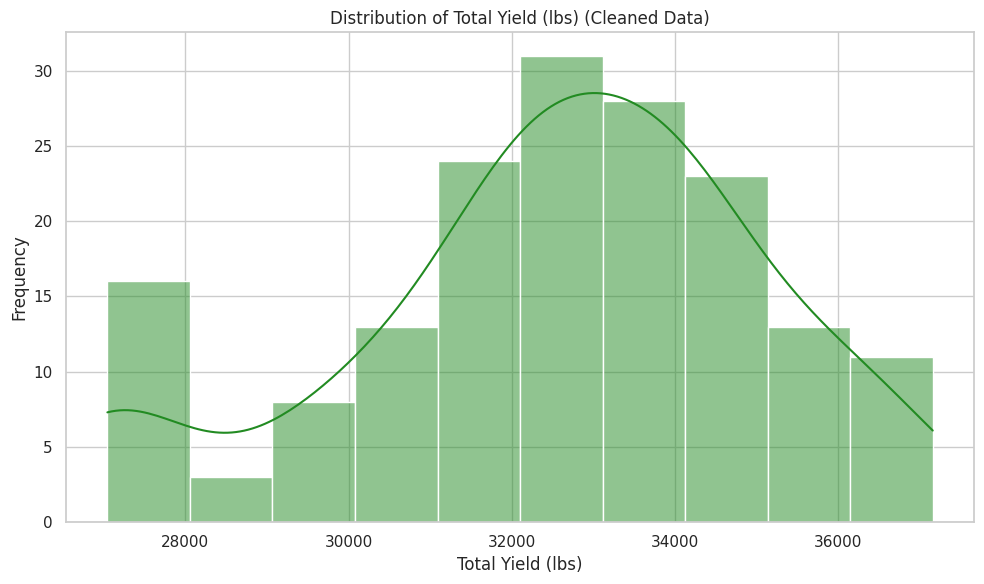

Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.


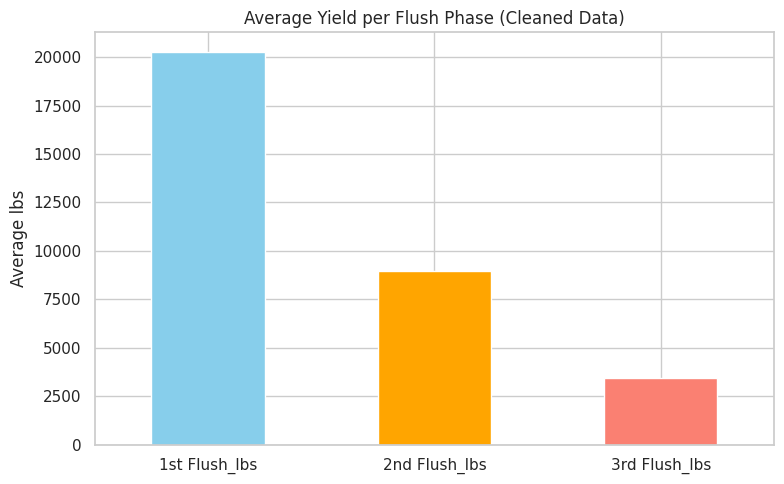

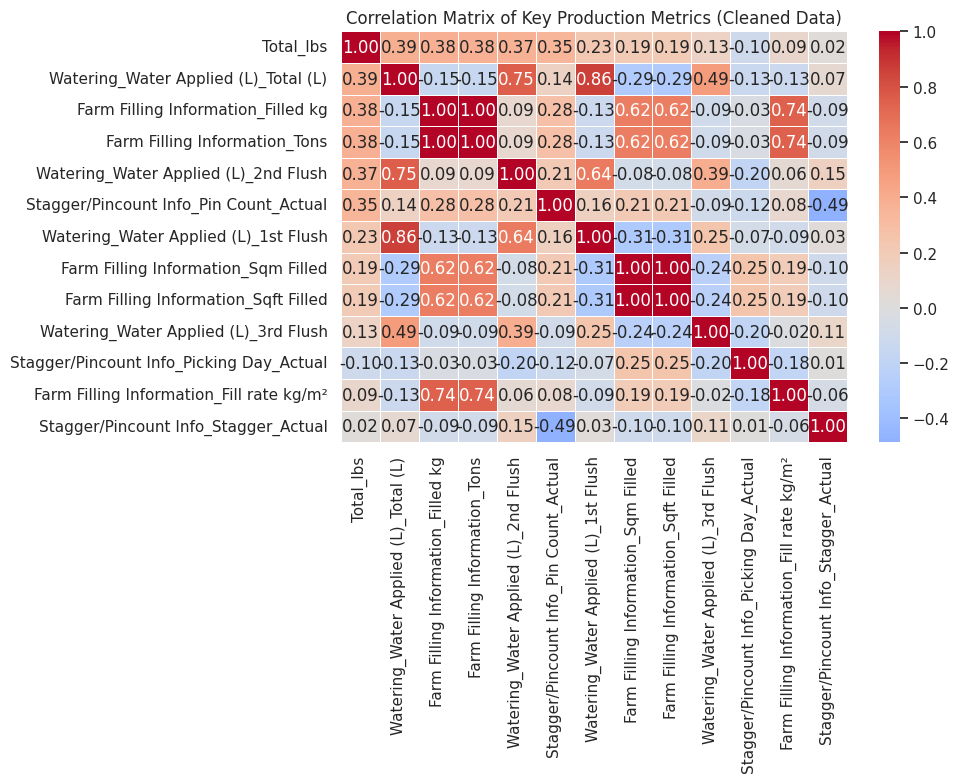

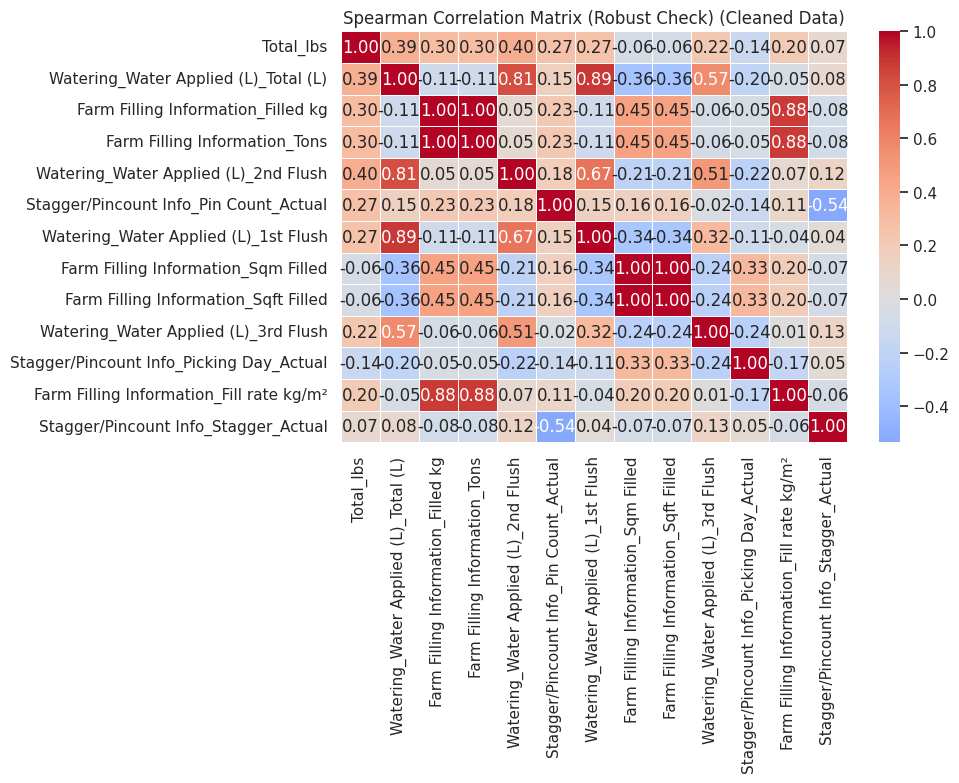

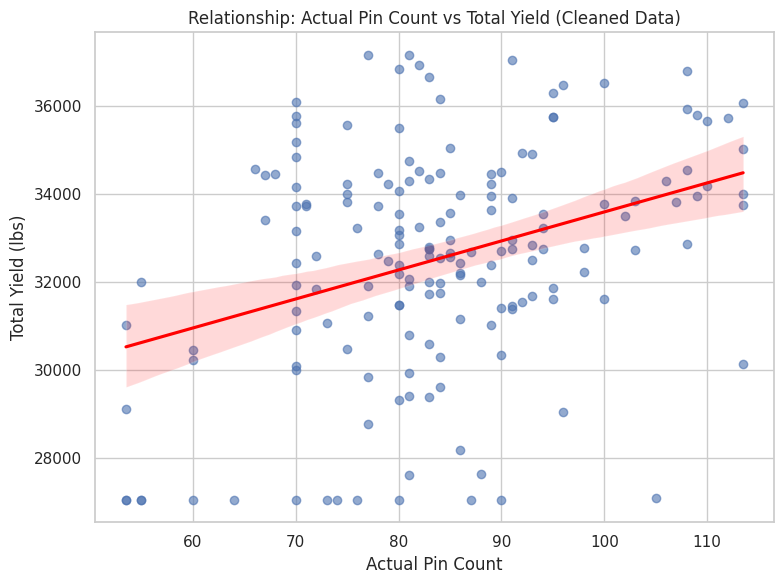

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Histogram: Distribution of Total Yield (lbs) using the cleaned dataset
if 'Total_lbs' in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs']):
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned['Total_lbs'].dropna(), kde=True, color='forestgreen')
    plt.title('Distribution of Total Yield (lbs) (Cleaned Data)')
    plt.xlabel('Total Yield (lbs)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Histogram: 'Total_lbs' is missing or not numeric in df_cleaned.")

# 2. Boxplot: Yield distribution across Spawn Rate bins (only if Spawn Rate has enough variability)
if ('Compost Information_Spawn Rate' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Compost Information_Spawn Rate']) and
    df_cleaned['Compost Information_Spawn Rate'].nunique(dropna=True) > 1 and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=pd.cut(df_cleaned['Compost Information_Spawn Rate'], bins=5),
        y=df_cleaned['Total_lbs']
    )
    plt.title('Yield Distribution by Spawn Rate Bins (Cleaned Data)')
    plt.xlabel('Spawn Rate (binned)')
    plt.ylabel('Total Yield (lbs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.")

# 3. Bar Chart: Average yield per flush phase (cleaned data)
flush_cols = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
existing_flush_cols = [c for c in flush_cols if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])]

if len(existing_flush_cols) >= 2:
    flush_means_cleaned = df_cleaned[existing_flush_cols].mean()
    plt.figure(figsize=(8, 5))
    flush_means_cleaned.plot(kind='bar', color=['skyblue', 'orange', 'salmon'][:len(existing_flush_cols)])
    plt.title('Average Yield per Flush Phase (Cleaned Data)')
    plt.ylabel('Average lbs')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Bar Chart: Not enough flush yield columns are available and numeric in df_cleaned.")

# 4. Correlation analysis (cleaned data): key variables only, with near-zero variance removal and optional target-based ordering
key_corr_cols = [
    # Inputs
'Compost Information_Spawn Rate', 'Compost Information_Supplement Rate', 'Compost Information_Water Added',
 'Farm Filling Information_Sqft Filled', 'Farm Filling Information_Missing Sections',
 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons', 'Farm Filling Information_Filled heights (cm)',
 'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²', 'Stagger/Pincount Info_Picking Day_Actual',
 'Stagger/Pincount Info_Picking Day_Target', 'Stagger/Pincount Info_Pin Count_Actual',
 'Stagger/Pincount Info_Pin Count_Target', 'Stagger/Pincount Info_Stagger_Actual', 'Stagger/Pincount Info_Stagger_Target',
 'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush', 'Watering_Water Applied (L)_3rd Flush',
 'Watering_Water Applied (L)_Total (L)', 'Farm_Filling_Information_Loading_Date_Year',


    # Outputs
    #'1st Flush_lbs',
    #'2nd Flush_lbs',
    #'3rd Flush_lbs',
    'Total_lbs',
    #'Total_lbs/sqft'

]

# Keep only existing numeric columns
existing_corr_cols = [
    c for c in key_corr_cols
    if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])
]

# Remove near-zero variance columns (correlation would be unstable or undefined)
existing_corr_cols = [
    c for c in existing_corr_cols
    if df_cleaned[c].dropna().std() > 1e-6
]

if len(existing_corr_cols) > 1:
    # Pearson correlation (linear association)
    corr_matrix_cleaned = df_cleaned[existing_corr_cols].corr(method='pearson')

    # Reorder the matrix by correlation with the target variable (if present)
    target_var = 'Total_lbs'
    if target_var in corr_matrix_cleaned.columns:
        ordered = corr_matrix_cleaned[target_var].abs().sort_values(ascending=False).index
        corr_matrix_cleaned = corr_matrix_cleaned.loc[ordered, ordered]

    # Heatmap visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Correlation Matrix of Key Production Metrics (Cleaned Data)')
    plt.tight_layout()
    plt.show()

    # Spearman correlation (rank-based robustness check)
    corr_matrix_cleaned_spearman = df_cleaned[existing_corr_cols].corr(method='spearman')
    if target_var in corr_matrix_cleaned_spearman.columns:
        corr_matrix_cleaned_spearman = corr_matrix_cleaned_spearman.loc[corr_matrix_cleaned.index, corr_matrix_cleaned.columns]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned_spearman, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Spearman Correlation Matrix (Robust Check) (Cleaned Data)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Correlation Matrices: Insufficient numeric, non-constant columns for correlation after cleaning.")

# 5. Quantitative relationship: Pin Count vs Total Yield (cleaned data), including regression trend
if ('Stagger/Pincount Info_Pin Count_Actual' in df_cleaned.columns and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Stagger/Pincount Info_Pin Count_Actual']) and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df_cleaned,
        x='Stagger/Pincount Info_Pin Count_Actual',
        y='Total_lbs',
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    plt.title('Relationship: Actual Pin Count vs Total Yield (Cleaned Data)')
    plt.xlabel('Actual Pin Count')
    plt.ylabel('Total Yield (lbs)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Scatter/Regression Plot: Required columns are missing or not numeric in df_cleaned.")

**Top Pairwise Correlations Between Numerical Variables**

In [ ]:
corr_pairs = (
    corr_matrix_cleaned
    .where(np.triu(np.ones(corr_matrix_cleaned.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Sort by absolute correlation strength
strong_correlations = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
)
# Display top correlations
strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
23,Farm Filling Information_Filled kg,Farm Filling Information_Tons,1.000000
63,Farm Filling Information_Sqm Filled,Farm Filling Information_Sqft Filled,0.999982
16,Watering_Water Applied (L)_Total (L),Watering_Water Applied (L)_1st Flush,0.857012
14,Watering_Water Applied (L)_Total (L),Watering_Water Applied (L)_2nd Flush,0.752894
31,Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,0.744978
40,Farm Filling Information_Tons,Farm Filling Information_Fill rate kg/m²,0.744978
43,Watering_Water Applied (L)_2nd Flush,Watering_Water Applied (L)_1st Flush,0.639833
36,Farm Filling Information_Tons,Farm Filling Information_Sqm Filled,0.624480
27,Farm Filling Information_Filled kg,Farm Filling Information_Sqm Filled,0.624480
37,Farm Filling Information_Tons,Farm Filling Information_Sqft Filled,0.624459


**Correlation of Key Variables with Total Yield (Total_lbs)**

In [ ]:
target_var = 'Total_lbs'

yield_correlations = (
    corr_matrix_cleaned[target_var]
    .drop(target_var)
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Total_lbs
Watering_Water Applied (L)_Total (L),0.388381
Farm Filling Information_Filled kg,0.381929
Farm Filling Information_Tons,0.381929
Watering_Water Applied (L)_2nd Flush,0.372436
Stagger/Pincount Info_Pin Count_Actual,0.346093
Watering_Water Applied (L)_1st Flush,0.225014
Farm Filling Information_Sqm Filled,0.194966
Farm Filling Information_Sqft Filled,0.194740
Watering_Water Applied (L)_3rd Flush,0.125145
Stagger/Pincount Info_Picking Day_Actual,-0.104220


## Conclusions

**Univariable Analysis (Cleaned Data)**

* **Total Yield (lbs) Distribution:**

  Using the cleaned dataset, the histogram of Total_lbs shows a more representative distribution of production outcomes. The removal of extreme and missing-value distortions results in clearer yield ranges and improved interpretability of typical production behavior.

* **Spawn Rate Impact:**

  The boxplot analysis with cleaned data indicates that Compost Information_Spawn Rate exhibits limited variability in its relationship with Total_lbs. Its relatively stable behavior across bins suggests that spawn rate is not a primary driver of yield variability within this dataset.

* **Yield per Flush Phase:**

  The bar chart based on cleaned data consistently shows that 1st Flush_lbs contributes the largest share of total yield, followed by 2nd Flush_lbs and 3rd Flush_lbs. This pattern remains stable after preprocessing, highlighting the importance of early production stages.

**Multivariable Analysis (Cleaned Correlation and Pairwise Analysis)**

* Total Yield (Total_lbs) and Total_lbs/sqft (Cleaned Data):

  * 1st Flush_lbs, 2nd Flush_lbs, and 3rd Flush_lbs maintain very strong positive correlations with total yield, confirming that total production is primarily driven by flush-level performance, particularly during the first flush.

  * Farm Filling Information_Filled kg and Farm Filling Information_Fill rate kg/m² show strong positive correlations with yield metrics, reinforcing the importance of substrate quantity and loading density after noise reduction.

  * Watering_Water Applied (L)_Total (L) remains strongly correlated with total yield, likely reflecting operational scale rather than a direct causal effect.

  * Stagger/Pincount Info_Pin Count_Actual shows a moderate positive correlation with yield, supporting its role as a biological indicator of productive capacity in the cleaned dataset.

  * Compost Information_Spawn Rate and Stagger/Pincount Info_Stagger_Actual continue to display weak or negligible linear relationships with total yield.

* Pairwise Correlation Analysis (Cleaned Data):
The strongest pairwise correlations occur among yield-related variables, indicating redundancy and potential multicollinearity. This confirms that, after cleaning, the dataset retains consistent production relationships while emphasizing the need for careful feature selection in future modeling.

# **Phase 2. Feature Engineering**

The next step in data preparation is to process mixed-type and categorical variables, engineer features from date variables, apply numerical feature transformations and scaling, generate new domain-specific features, and perform feature selection.

Specifically, we will:

1.  **Clean column names** by stripping leading/trailing spaces from all column names in `df_cleaned` to ensure consistency.
2.  **Process mixed-type object columns**:
    *   **'Compost Information_Supplement Rate'**: Convert values like '1.3%/1.22%' to numerical form. We will define a function to parse these strings, interpreting percentages as decimals (e.g., '1.3%' becomes 0.013). If multiple values are present (e.g., 'X%/Y%'), We will calculate their average. Non-parseable values will become NaN.
    *   **'Compost Information_Water Added'**: Convert values like '7.81/9.16' to a single numerical form. We will define a function to parse these strings, calculating the average if multiple values are present. Non-parseable values will become NaN.
    *   **'Farm Filling Information_Filled heights (cm)'**: Convert this column to a numerical data type, coercing any errors to NaN.
    *   After conversion, any new NaNs in these columns will be imputed using the median of their respective columns.
3.  **Engineer features from date variables**:
    *   Extract year, month, day, day of the week, and week of the year from 'Farm Filling Information_Loading Date' and 'Stagger/Pincount Info_Picking Date'.
    *   Calculate the difference in days between 'Stagger/Pincount Info_Picking Date' and 'Farm Filling Information_Loading Date', storing it as a new feature 'Days_Between_Loading_and_Picking'.
4.  **Identify and process remaining categorical variables**: Convert 'Compost Information_Supplement Rate' (if still object after parsing attempts), 'Compost Information_Water Added' (if still object after parsing attempts), and 'Farm Filling Information_Filled heights (cm)' (if still object after name cleaning and numeric conversion attempts) into appropriate numerical representations using one-hot encoding if they are truly categorical. Given the previous analysis and the plan, it's expected these will become numerical after step 2.
5.  **Re-evaluate data types and describe the `df_cleaned` DataFrame** to verify the changes.

## Clean column names


To ensure consistency and ease of use, we will strip any leading or trailing spaces from the column names in the `df_cleaned` DataFrame.



In [ ]:
df_cleaned.columns = df_cleaned.columns.str.strip()
print("Column names in df_cleaned after stripping spaces:")
print(df_cleaned.columns.tolist())

Column names in df_cleaned after stripping spaces:
['Compost Information_Spawn Rate', 'Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Sqft Filled', 'Farm Filling Information_Missing Sections', 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons', 'Farm Filling Information_Filled heights (cm)', 'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²', 'Farm Filling Information_Loading Date', 'Stagger/Pincount Info_Picking Date', 'Stagger/Pincount Info_Picking Day_Actual', 'Stagger/Pincount Info_Picking Day_Target', 'Stagger/Pincount Info_Pin Count_Actual', 'Stagger/Pincount Info_Pin Count_Target', 'Stagger/Pincount Info_Stagger_Actual', 'Stagger/Pincount Info_Stagger_Target', 'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush', 'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)', '1st Flush_Day 1', '1st Flush_Sep lbs', '1st Flush_Day 2', '1s

## Process Mixed-Type and Categorical Variables


We will define two helper functions to parse and convert mixed-type strings containing percentages or multiple numbers separated by slashes into numerical averages. Then, we will apply these functions to the specified columns, and directly convert the 'Farm Filling Information_Filled heights (cm)' column to numeric, handling potential errors by coercing them to NaN. Finally, we will impute any newly created or existing NaN values in these three columns using their respective medians.



In [ ]:
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            # Remove '%' and split by '/'
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    # Interpret percentage as decimal if it's from a percentage string
                    # Assume if a string contains '%' originally, the number should be divided by 100
                    # If it's just a number like '1.22' it should be taken as is.
                    # Given the examples like '1.3%/1.22%', assuming numbers are percentages.
                    numbers.append(num / 100)
                except ValueError:
                    continue # Skip non-numeric parts
            if numbers: # Calculate average of valid numbers
                return np.mean(numbers)
            else:
                return np.nan # No valid numbers found
        except Exception: # Catch any other parsing errors
            return np.nan
    elif pd.isna(value):
        return np.nan # Keep existing NaNs
    else:
        return value # Return non-string, non-NaN values as is (should be already numeric)

# Apply the function to 'Compost Information_Supplement Rate'
df_cleaned['Compost Information_Supplement Rate'] = df_cleaned['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)

def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            # Split by '/'
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue # Skip non-numeric parts
            if numbers: # Calculate average of valid numbers
                return np.mean(numbers)
            else:
                return np.nan # No valid numbers found
        except Exception: # Catch any other parsing errors
            return np.nan
    elif pd.isna(value):
        return np.nan # Keep existing NaNs
    else:
        return value # Return non-string, non-NaN values as is (should be already numeric)

# Apply the function to 'Compost Information_Water Added'
df_cleaned['Compost Information_Water Added'] = df_cleaned['Compost Information_Water Added'].apply(parse_and_average_number)

# Convert 'Farm Filling Information_Filled heights (cm)' to numeric, coercing errors to NaN
df_cleaned['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(
    df_cleaned['Farm Filling Information_Filled heights (cm)'], errors='coerce'
)

# Impute any remaining NaN values in these three columns with their respective medians
columns_to_impute = [
    'Compost Information_Supplement Rate',
    'Compost Information_Water Added',
    'Farm Filling Information_Filled heights (cm)'
]

for col in columns_to_impute:
    if col in df_cleaned.columns:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

print("Processing of mixed-type and categorical variables complete.")
print("Data types after processing:")
print(df_cleaned[columns_to_impute].dtypes)
print("Missing values after processing:")
print(df_cleaned[columns_to_impute].isnull().sum())


Processing of mixed-type and categorical variables complete.
Data types after processing:
Compost Information_Supplement Rate             float64
Compost Information_Water Added                 float64
Farm Filling Information_Filled heights (cm)    float64
dtype: object
Missing values after processing:
Compost Information_Supplement Rate             0
Compost Information_Water Added                 0
Farm Filling Information_Filled heights (cm)    0
dtype: int64


## Engineer Features from Date Variables

To engineer features from date variables, we will extract year, month, day, day of the week, and week of the year from the specified date columns, and then calculate the difference in days between the loading and picking dates.



In [ ]:
date_cols = ['Farm Filling Information_Loading Date', 'Stagger/Pincount Info_Picking Date']

for col in date_cols:
    # Ensure the column is datetime type
    df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

    # Extract year, month, day, filling NaN with -1 before converting to int
    df_cleaned[col.replace(' ', '_') + '_Year'] = df_cleaned[col].dt.year.fillna(-1).astype(pd.Int64Dtype())
    df_cleaned[col.replace(' ', '_') + '_Month'] = df_cleaned[col].dt.month.fillna(-1).astype(pd.Int64Dtype())
    df_cleaned[col.replace(' ', '_') + '_Day'] = df_cleaned[col].dt.day.fillna(-1).astype(pd.Int64Dtype())

    # Extract day of the week (Monday=0, Sunday=6), filling NaN with -1 before converting to int
    df_cleaned[col.replace(' ', '_') + '_DayOfWeek'] = df_cleaned[col].dt.dayofweek.fillna(-1).astype(pd.Int64Dtype())

    # Extract week of the year, convert to signed type before filling NaN with -1
    df_cleaned[col.replace(' ', '_') + '_WeekOfYear'] = df_cleaned[col].dt.isocalendar().week.astype(pd.Int64Dtype()).fillna(-1)

# Calculate the difference in days between 'Picking Date' and 'Loading Date'
df_cleaned['Days_Between_Loading_and_Picking'] = (
    df_cleaned['Stagger/Pincount Info_Picking Date'] - df_cleaned['Farm Filling Information_Loading Date']
).dt.days.fillna(-1).astype(pd.Int64Dtype())

print("Engineered features from date variables:")
print(df_cleaned[['Farm_Filling_Information_Loading_Date_Year',
                  'Farm_Filling_Information_Loading_Date_Month',
                  'Farm_Filling_Information_Loading_Date_Day',
                  'Farm_Filling_Information_Loading_Date_DayOfWeek',
                  'Farm_Filling_Information_Loading_Date_WeekOfYear',
                  'Stagger/Pincount_Info_Picking_Date_Year',
                  'Stagger/Pincount_Info_Picking_Date_Month',
                  'Stagger/Pincount_Info_Picking_Date_Day',
                  'Stagger/Pincount_Info_Picking_Date_DayOfWeek',
                  'Stagger/Pincount_Info_Picking_Date_WeekOfYear',
                  'Days_Between_Loading_and_Picking']].head())

Engineered features from date variables:
   Farm_Filling_Information_Loading_Date_Year  \
0                                        2024   
1                                        2024   
2                                        2024   
3                                        2025   
4                                        2025   

   Farm_Filling_Information_Loading_Date_Month  \
0                                           12   
1                                           12   
2                                           12   
3                                            1   
4                                            1   

   Farm_Filling_Information_Loading_Date_Day  \
0                                         25   
1                                         26   
2                                         31   
3                                          1   
4                                          2   

   Farm_Filling_Information_Loading_Date_DayOfWeek  \
0                   

Now that the date features have been engineered, we will re-evaluate the data types and provide a descriptive summary of the `df_cleaned` DataFrame to verify all the changes made so far and ensure the data is in the expected format for further processing.



In [ ]:
print("Updated DataFrame Information:")
df_cleaned.info()

print("\nDescriptive statistics for the updated DataFrame:")
df_cleaned.describe()

Updated DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 74 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Compost Information_Spawn Rate                    170 non-null    float64       
 1   Compost Information_Supplement Rate               170 non-null    float64       
 2   Compost Information_Water Added                   170 non-null    float64       
 3   Farm Filling Information_Sqft Filled              170 non-null    float64       
 4   Farm Filling Information_Missing Sections         170 non-null    float64       
 5   Farm Filling Information_Sqm Filled               170 non-null    float64       
 6   Farm Filling Information_Tons                     170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)      170 non-null    float64       
 8  

,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,...,Farm_Filling_Information_Loading_Date_Month,Farm_Filling_Information_Loading_Date_Day,Farm_Filling_Information_Loading_Date_DayOfWeek,Farm_Filling_Information_Loading_Date_WeekOfYear,Stagger/Pincount_Info_Picking_Date_Year,Stagger/Pincount_Info_Picking_Date_Month,Stagger/Pincount_Info_Picking_Date_Day,Stagger/Pincount_Info_Picking_Date_DayOfWeek,Stagger/Pincount_Info_Picking_Date_WeekOfYear,Days_Between_Loading_and_Picking
count,1.700000e+02,170.000000,170.000000,170.000000,170.0,170.000000,170.000000,170.000000,170.000000,170.000000,...,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0
mean,1.501535e+01,0.013736,4.980206,4644.923529,2.0,431.388235,37.869412,29.182353,37869.411765,88.570818,...,6.476471,15.952941,1.888235,26.523529,2025.011765,6.629412,15.305882,2.635294,26.994118,14.747059
min,1.501535e+01,0.011300,0.000000,4565.500000,2.0,424.000000,32.310000,26.000000,32310.000000,75.978860,...,1.0,1.0,0.0,1.0,2025.0,1.0,1.0,0.0,1.0,13.0
25%,1.501535e+01,0.013500,5.140000,4630.000000,2.0,430.000000,36.532500,28.000000,36532.500000,85.123068,...,4.0,8.25,0.0,14.0,2025.0,4.0,7.25,1.0,14.0,14.0
50%,1.501535e+01,0.013500,5.140000,4647.000000,2.0,431.500000,38.140000,29.000000,38140.000000,88.779088,...,7.0,16.0,2.0,27.0,2025.0,7.0,15.0,3.0,27.0,15.0
75%,1.501535e+01,0.013500,5.140000,4673.000000,2.0,434.000000,39.347500,30.000000,39347.500000,91.233711,...,9.0,23.0,3.0,39.0,2025.0,10.0,23.0,4.0,40.0,15.0
max,1.501535e+01,0.040000,9.210000,4673.000000,2.0,434.000000,43.570000,35.000000,43570.000000,100.399675,...,12.0,31.0,4.0,52.0,2026.0,12.0,31.0,6.0,52.0,17.0
std,3.028728e-14,0.002174,1.502802,33.322346,0.0,3.098364,2.364179,1.801293,2364.179106,4.334507,...,3.418022,8.876411,1.311931,14.863164,0.108144,3.419101,8.888559,1.335426,14.900259,0.565913


# **Phases 3. Baseline**
Prepare the data for modeling by identifying the target variables (`1st Flush_lbs`, `2nd Flush_lbs`, `3rd Flush_lbs`) and features. Perform a train-test split, apply skewness transformation using `log1p`, scale numerical features with `StandardScaler` (fitting only on `X_train`), and then apply PCA to the scaled features, retaining 95% of the variance, transforming both `X_train` and `X_test`.

## Prepare Data for Modeling (Train-Test Split, Scaling, and PCA)

Identify target variables and features, perform a train-test split, apply skewness transformation using log1p, scale numerical features with StandardScaler (fitting only on X_train), and then apply PCA to the scaled features, retaining 95% of the variance, transforming both X_train and X_test.


In [ ]:
# Function to make column names unique by appending a suffix if duplicates exist
def make_columns_unique_simple(df_input):
    df = df_input.copy() # Work on a copy
    cols = []
    seen_counts = {} # Dictionary to store counts of each column name
    for col in df.columns:
        current_name = col
        if current_name in seen_counts:
            # If seen, increment count and append to name
            seen_counts[current_name] += 1
            new_name = f"{current_name}_{seen_counts[current_name]}"
            # Ensure the new_name is also unique across all columns already processed/existing
            while new_name in df.columns.tolist() or new_name in cols:
                seen_counts[current_name] += 1
                new_name = f"{current_name}_{seen_counts[current_name]}"
            cols.append(new_name)
        else:
            # First time seeing this name, add it as is
            seen_counts[current_name] = 0 # Initialize count for this name
            cols.append(current_name)
    df.columns = cols
    return df

# Apply this function first to df_cleaned to ensure all column names are unique
df_cleaned = make_columns_unique_simple(df_cleaned)

# 1. Define target variables (y) and feature set (X)
# Target variables: '1st Flush_lbs', '2nd Flush_lbs', and '3rd Flush_lbs'
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
y = df_cleaned[target_columns].copy()

# Feature set (X): drop target variables, 'Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton', 'Total_Target',
# and original datetime columns
columns_to_drop_from_X_raw = target_columns + \
                         ['Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton', 'Total_Target','1st Flush_Day 1',
                          '1st Flush_Sep lbs', '1st Flush_Day 2', '1st Flush_Sep lbs_1', '1st Flush_Day 3',
                          '1st Flush_Day 4', '1st Flush_Day 5', '1st Flush_Day 6', '1st Flush_Day 7',
                          '1st Flush_Sep %', '1st Flush_lbs/sqft', '1st Flush_lbs/ton', '2nd Flush_Day 1',
                          '2nd Flush_Day 2', '2nd Flush_Day 3', '2nd Flush_Day 4', '2nd Flush_Day 5',
                          '2nd Flush_Day 6', '2nd Flush_Day 7', '2nd Flush_Day 8', '2nd Flush_Day 9', '2nd Flush_lbs/sqft',
                          '2nd Flush_lbs/ton', '3rd Flush_Day 1', '3rd Flush_Day 2', '3rd Flush_Day 3', '3rd Flush_Day 4',
                          '3rd Flush_Day 5', '3rd Flush_Day 6', '3rd Flush_Day 7', '3rd Flush_Day 8', '3rd Flush_Day 9',
                          '3rd Flush_lbs/sqft', '3rd Flush_lbs/ton', 'Farm_Filling_Information_Loading_Date_Month','Farm_Filling_Information_Loading_Date_Day',
                          'Farm_Filling_Information_Loading_Date_DayOfWeek','Farm_Filling_Information_Loading_Date_WeekOfYear', 'Stagger/Pincount_Info_Picking_Date_Year'
                          ,'Stagger/Pincount_Info_Picking_Date_Month', 'Stagger/Pincount_Info_Picking_Date_Day','Stagger/Pincount_Info_Picking_Date_DayOfWeek','Stagger/Pincount_Info_Picking_Date_WeekOfYear',
                          'Stagger/Pincount Info_Picking Date','Stagger/Pincount Info_Picking Day_Actual','Stagger/Pincount Info_Picking Day_Target', 'Stagger/Pincount Info_Pin Count_Target'
                          'Stagger/Pincount Info_Stagger_Target','Stagger/Pincount Info_Stagger_Actual', 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons']

# Filter columns_to_drop_from_X_raw to ensure only existing (and now unique) columns are dropped
columns_to_drop_from_X = [col for col in columns_to_drop_from_X_raw if col in df_cleaned.columns]
X = df_cleaned.drop(columns=columns_to_drop_from_X, errors='ignore').copy()

# Ensure only numerical and engineered categorical columns remain in X
# All columns in X should now be numerical (or pd.Int64Dtype) and have unique names due to preprocessing
X = X.select_dtypes(include=[np.number, pd.Int64Dtype()])

print(f"Shape of X before split: {X.shape}")
print(f"Shape of y before split: {y.shape}")

# 2. Split the X and y data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Identify numerical columns in X_train for transformations
# After making columns unique and selecting only numerical types, all columns in X_train are numerical for processing
numerical_cols_X = X_train.columns

# 3. Apply log1p transformation to numerical columns in X_train and X_test
for col in numerical_cols_X:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

print("\nApplied log1p transformation to numerical columns.")

# Store X_train and X_test before PCA for the 'no PCA' scenario
X_train_pre_pca = X_train.copy()
X_test_pre_pca = X_test.copy()

# Remove constant columns (zero variance) before scaling and PCA
# These columns cause StandardScaler to output inf values
constant_columns = X_train.columns[X_train.std() == 0]
if len(constant_columns) > 0:
    X_train = X_train.drop(columns=constant_columns)
    X_test = X_test.drop(columns=constant_columns)
    X_train_pre_pca = X_train_pre_pca.drop(columns=constant_columns)
    X_test_pre_pca = X_test_pre_pca.drop(columns=constant_columns)
    print(f"Removed constant columns with zero variance: {list(constant_columns)}")

# 4. Initialize StandardScaler, fit on X_train, and transform both X_train and X_test
scaler = StandardScaler()

# Since X_train and X_test now contain only the numerical columns to be scaled
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame, retaining column names and index
X_train = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

print("Applied StandardScaler to numerical columns.")

# 5. Initialize PCA with n_components=0.95, fit on scaled X_train, and transform both
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train) # X_train now contains the scaled values
X_test_pca = pca.transform(X_test) # X_test now contains the scaled values

# Convert PCA transformed arrays back to DataFrame for consistency
X_train_pca = pd.DataFrame(X_train_pca, index=X_train.index, columns=[f'PC_{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca = pd.DataFrame(X_test_pca, index=X_test.index, columns=[f'PC_{i+1}' for i in range(X_test_pca.shape[1])])

print(f"\nShape of X_train after PCA: {X_train_pca.shape}")
print(f"Shape of X_test after PCA: {X_test_pca.shape}")
print(f"Number of components retained by PCA: {pca.n_components_}")

print("\nData preparation for modeling (Train-Test Split, Scaling, and PCA) complete.")


Shape of X before split: (170, 17)
Shape of y before split: (170, 3)

Shape of X_train: (136, 17)
Shape of X_test: (34, 17)
Shape of y_train: (136, 3)
Shape of y_test: (34, 3)

Applied log1p transformation to numerical columns.
Applied StandardScaler to numerical columns.

Shape of X_train after PCA: (136, 10)
Shape of X_test after PCA: (34, 10)
Number of components retained by PCA: 10

Data preparation for modeling (Train-Test Split, Scaling, and PCA) complete.


In [ ]:
print(X.columns.tolist())

['Compost Information_Spawn Rate', 'Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Sqft Filled', 'Farm Filling Information_Missing Sections', 'Farm Filling Information_Filled heights (cm)', 'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²', 'Stagger/Pincount Info_Pin Count_Actual', 'Stagger/Pincount Info_Pin Count_Target', 'Stagger/Pincount Info_Stagger_Target', 'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush', 'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)', 'Farm_Filling_Information_Loading_Date_Year', 'Days_Between_Loading_and_Picking']


In [ ]:
num_vars_before_pca = X.shape[1]
num_vars_after_pca = X_train_pca.shape[1]
num_vars_reduced = num_vars_before_pca - num_vars_after_pca

print(f"Number of variables before PCA: {num_vars_before_pca}")
print(f"Number of components retained after PCA: {num_vars_after_pca}")
print(f"Number of variables reduced by PCA: {num_vars_reduced}")

Number of variables before PCA: 17
Number of components retained after PCA: 10
Number of variables reduced by PCA: 7


In [ ]:
print("Variables used in the model after PCA:")
print(X_train_pca.columns.tolist())

Variables used in the model after PCA:
['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10']


## Define Baselines, Metrics, and Performance Benchmarks

Establish a Naive (mean prediction) and Linear Regression model as baselines for each flush target. Define RMSE, MAE, and R-squared as primary evaluation metrics. Discuss methods for identifying overfitting/underfitting and set the minimum performance benchmark based on the Naive baseline. Clarify 'Total_lbs' as an overall business metric versus individual flush predictions as primary targets.


In [ ]:
# Initialize Linear Regression model
linear_model = LinearRegression()

# Target variables
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Dictionary to store metrics for each target
results = {}

print("Establishing Baselines and Calculating Metrics:")

for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # 1. Naive Baseline (Mean Prediction)
    # Calculate Naive baseline prediction as the mean of the respective y_train target variable
    naive_pred_train = y_train[target].mean()
    naive_pred_test = y_train[target].mean() # The naive prediction for test is also based on training data mean

    # Convert scalar predictions to arrays matching the shape of y_train/y_test for metric calculation
    naive_predictions_train_array = np.full(y_train[target].shape, naive_pred_train)
    naive_predictions_test_array = np.full(y_test[target].shape, naive_pred_test)

    # Calculate metrics for Naive baseline on training set
    naive_mse_train = mean_squared_error(y_train[target], naive_predictions_train_array)
    naive_rmse_train = np.sqrt(naive_mse_train)
    naive_mae_train = mean_absolute_error(y_train[target], naive_predictions_train_array)
    naive_r2_train = r2_score(y_train[target], naive_predictions_train_array)

    # Calculate metrics for Naive baseline on test set
    naive_mse_test = mean_squared_error(y_test[target], naive_predictions_test_array)
    naive_rmse_test = np.sqrt(naive_mse_test)
    naive_mae_test = mean_absolute_error(y_test[target], naive_predictions_test_array)
    naive_r2_test = r2_score(y_test[target], naive_predictions_test_array)

    # Store Naive baseline metrics
    results[target] = {
        'Naive_RMSE_Train': naive_rmse_train,
        'Naive_MAE_Train': naive_mae_train,
        'Naive_R2_Train': naive_r2_train,
        'Naive_RMSE_Test': naive_rmse_test,
        'Naive_MAE_Test': naive_mae_test,
        'Naive_R2_Test': naive_r2_test
    }

    print(f"Naive Baseline (mean of y_train[{target}]={naive_pred_train:.2f}):")
    print(f"  Train RMSE: {naive_rmse_train:.2f}, MAE: {naive_mae_train:.2f}, R2: {naive_r2_train:.2f}")
    print(f"  Test RMSE: {naive_rmse_test:.2f}, MAE: {naive_mae_test:.2f}, R2: {naive_r2_test:.2f}")

    # 2. Linear Regression Model
    # Fit the Linear Regression model
    linear_model.fit(X_train_pca, y_train[target])

    # Make predictions
    lr_predictions_train = linear_model.predict(X_train_pca)
    lr_predictions_test = linear_model.predict(X_test_pca)

    # Calculate metrics for Linear Regression on training set
    lr_mse_train = mean_squared_error(y_train[target], lr_predictions_train)
    lr_rmse_train = np.sqrt(lr_mse_train)
    lr_mae_train = mean_absolute_error(y_train[target], lr_predictions_train)
    lr_r2_train = r2_score(y_train[target], lr_predictions_train)

    # Calculate metrics for Linear Regression on test set
    lr_mse_test = mean_squared_error(y_test[target], lr_predictions_test)
    lr_rmse_test = np.sqrt(lr_mse_test)
    lr_mae_test = mean_absolute_error(y_test[target], lr_predictions_test)
    lr_r2_test = r2_score(y_test[target], lr_predictions_test)

    # Store Linear Regression metrics
    results[target].update({
        'LR_RMSE_Train': lr_rmse_train,
        'LR_MAE_Train': lr_mae_train,
        'LR_R2_Train': lr_r2_train,
        'LR_RMSE_Test': lr_rmse_test,
        'LR_MAE_Test': lr_mae_test,
        'LR_R2_Test': lr_r2_test
    })

    print(f"Linear Regression Model:")
    print(f"  Train RMSE: {lr_rmse_train:.2f}, MAE: {lr_mae_train:.2f}, R2: {lr_r2_train:.2f}")
    print(f"  Test RMSE: {lr_rmse_test:.2f}, MAE: {lr_mae_test:.2f}, R2: {lr_r2_test:.2f}")

# Convert results to DataFrame for better presentation
metrics_df = pd.DataFrame.from_dict(results, orient='index')
metrics_df.index.name = 'Target Variable'

print("\n=======================================================")
print("Summary of Baseline Model Performance (RMSE, MAE, R2)")
print("=======================================================")
display(metrics_df)

print("\n=======================================================")
print("Minimum Performance Benchmarks (based on Naive Test Set performance):")
print("=======================================================")
for target in target_columns:
    print(f"For {target}:\n"\
          f"  RMSE must be significantly lower than {results[target]['Naive_RMSE_Test']:.2f}\n"\
          f"  MAE must be significantly lower than {results[target]['Naive_MAE_Test']:.2f}\n"\
          f"  R2 must be significantly higher than {results[target]['Naive_R2_Test']:.2f} (ideally > 0)")
    if results[target]['Naive_R2_Test'] < 0:
        print(f"    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.")

print("\nAny developed model should aim to achieve an R-squared significantly greater than the Naive baseline's R-squared on the test set, and correspondingly lower RMSE and MAE values. An R-squared value of 0 indicates that the model explains no more variance than the mean of the target variable. Therefore, a model should strive for a positive R-squared, ideally much closer to 1, to demonstrate predictive power.")


Establishing Baselines and Calculating Metrics:

--- Processing Target: 1st Flush_lbs ---
Naive Baseline (mean of y_train[1st Flush_lbs]=20372.69):
  Train RMSE: 1849.09, MAE: 1408.26, R2: 0.00
  Test RMSE: 2191.98, MAE: 1664.59, R2: -0.06
Linear Regression Model:
  Train RMSE: 1394.64, MAE: 1025.79, R2: 0.43
  Test RMSE: 1920.70, MAE: 1539.40, R2: 0.18

--- Processing Target: 2nd Flush_lbs ---
Naive Baseline (mean of y_train[2nd Flush_lbs]=9018.53):
  Train RMSE: 961.23, MAE: 734.64, R2: 0.00
  Test RMSE: 1210.92, MAE: 939.62, R2: -0.03
Linear Regression Model:
  Train RMSE: 841.02, MAE: 667.74, R2: 0.23
  Test RMSE: 1120.43, MAE: 894.98, R2: 0.12

--- Processing Target: 3rd Flush_lbs ---
Naive Baseline (mean of y_train[3rd Flush_lbs]=3452.51):
  Train RMSE: 623.45, MAE: 468.07, R2: 0.00
  Test RMSE: 633.32, MAE: 450.82, R2: -0.03
Linear Regression Model:
  Train RMSE: 561.98, MAE: 432.60, R2: 0.19
  Test RMSE: 618.77, MAE: 455.64, R2: 0.02

Summary of Baseline Model Performance (RMSE

,Naive_RMSE_Train,Naive_MAE_Train,Naive_R2_Train,Naive_RMSE_Test,Naive_MAE_Test,Naive_R2_Test,LR_RMSE_Train,LR_MAE_Train,LR_R2_Train,LR_RMSE_Test,LR_MAE_Test,LR_R2_Test
Target Variable,,,,,,,,,,,,
1st Flush_lbs,1849.085661,1408.259833,0.0,2191.983077,1664.585662,-0.064707,1394.638501,1025.785031,0.431135,1920.699447,1539.395952,0.182525
2nd Flush_lbs,961.228518,734.644720,0.0,1210.921948,939.623199,-0.027726,841.021726,667.735352,0.234472,1120.433650,894.982071,0.120132
3rd Flush_lbs,623.448330,468.066775,0.0,633.320768,450.818778,-0.031394,561.977973,432.598301,0.187473,618.772760,455.642701,0.015446



Minimum Performance Benchmarks (based on Naive Test Set performance):
For 1st Flush_lbs:
  RMSE must be significantly lower than 2191.98
  MAE must be significantly lower than 1664.59
  R2 must be significantly higher than -0.06 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.
For 2nd Flush_lbs:
  RMSE must be significantly lower than 1210.92
  MAE must be significantly lower than 939.62
  R2 must be significantly higher than -0.03 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.
For 3rd Flush_lbs:
  RMSE must be significantly lower than 633.32
  MAE must be significantly lower than 450.82
  R2 must be significantly higher than -0.03 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.

Any developed model should aim to achieve an R-squared significantly greater than the Naive baseline's R-squared on the test set, 

#**Phase 4. Individual Models**

## Build and Evaluate Individual Models

Train and evaluate 6 different individual regression models (beyond Linear Regression, such as Ridge, Lasso, Decision Tree, SVR, KNeighbors, and RandomForest) for each flush target. Systematically evaluate their performance using the defined metrics and record training times.


In [ ]:
# 1. Initialize the regression models
# Using default parameters as specified
models = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=2000), # Increased max_iter to prevent convergence warnings
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1) # Use all available cores
}

# Target variables (already defined in previous step)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# 2. Dictionary to store results
all_results = []

print("Training and Evaluating Individual Models:")

# 3. Iterate through each target variable
for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Iterate through each model
    for model_name, model in models.items():
        print(f"  Training {model_name}...")

        # b. Record start time
        start_time = time.time()

        # c. Train the current model
        model.fit(X_train_pca, y_train[target])

        # d. Record end time and calculate training duration
        end_time = time.time()
        training_duration = end_time - start_time

        # e. Make predictions on both X_train_pca and X_test_pca
        train_predictions = model.predict(X_train_pca)
        test_predictions = model.predict(X_test_pca)

        # f. Calculate RMSE, MAE, and R-squared for both train and test
        rmse_train = np.sqrt(mean_squared_error(y_train[target], train_predictions))
        mae_train = mean_absolute_error(y_train[target], train_predictions)
        r2_train = r2_score(y_train[target], train_predictions)

        rmse_test = np.sqrt(mean_squared_error(y_test[target], test_predictions))
        mae_test = mean_absolute_error(y_test[target], test_predictions)
        r2_test = r2_score(y_test[target], test_predictions)

        # g. Store all calculated metrics and the training time
        all_results.append({
            'Target': target,
            'Model': model_name,
            'RMSE_Train': rmse_train,
            'MAE_Train': mae_train,
            'R2_Train': r2_train,
            'RMSE_Test': rmse_test,
            'MAE_Test': mae_test,
            'R2_Test': r2_test,
            'Training_Time_seconds': training_duration
        })

# 4. Present the stored metrics and training times in a DataFrame
results_df = pd.DataFrame(all_results)

print("\n=======================================================")
print("Summary of Individual Model Performance")
print("=======================================================")
display(results_df)


Training and Evaluating Individual Models:

--- Processing Target: 1st Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 2nd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 3rd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

Summary of Individual Model Performance


,Target,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
0,1st Flush_lbs,Ridge,1394.651008,1026.051301,0.431125,1918.284878,1538.096241,0.184579,0.012702
1,1st Flush_lbs,Lasso,1394.642601,1025.811492,0.431132,1918.693730,1538.091230,0.184231,0.012977
2,1st Flush_lbs,DecisionTreeRegressor,0.000000,0.000000,1.000000,2455.357322,1849.044485,-0.335935,0.011745
3,1st Flush_lbs,SVR,1845.682491,1404.736386,0.003678,2188.589793,1662.312481,-0.061414,0.013031
4,1st Flush_lbs,KNeighborsRegressor,1121.655671,863.814164,0.632036,1670.875594,1366.632265,0.381351,0.012249
5,1st Flush_lbs,RandomForestRegressor,519.739055,399.846106,0.920995,1746.551679,1347.092403,0.324043,0.944619
6,2nd Flush_lbs,Ridge,841.029337,667.898274,0.234458,1120.030261,894.801557,0.120766,0.017476
7,2nd Flush_lbs,Lasso,841.028527,667.850386,0.234460,1119.937797,894.726970,0.120911,0.016699
8,2nd Flush_lbs,DecisionTreeRegressor,0.000000,0.000000,1.000000,1294.191472,1084.057426,-0.173930,0.033630
9,2nd Flush_lbs,SVR,961.728341,729.683424,-0.001040,1221.142849,942.538119,-0.045149,0.006223


## Select Top Individual Models and Tune Hyperparameters

Based on the initial evaluation, identify the top two performing individual models for each flush target. Perform hyperparameter tuning on these selected models using GridSearchCV or RandomizedSearchCV to optimize their performance.


In [ ]:
# Group by target and sort by R2_Test to find top models
top_models_per_target = {}
for target in target_columns:
    target_df = results_df[results_df['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_per_target[target] = target_df.head(2)

print("Top 2 models for each target based on R2_Test:")
for target, models_df in top_models_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'R2_Test', 'RMSE_Test', 'MAE_Test']])


Top 2 models for each target based on R2_Test:

--- Target: 1st Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
4,KNeighborsRegressor,0.381351,1670.875594,1366.632265
5,RandomForestRegressor,0.324043,1746.551679,1347.092403



--- Target: 2nd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
7,Lasso,0.120911,1119.937797,894.726970
6,Ridge,0.120766,1120.030261,894.801557



--- Target: 3rd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
16,KNeighborsRegressor,0.126470,582.841116,439.888721
17,RandomForestRegressor,0.082706,597.262948,433.540597


Now that the top models for each target have been identified, the next step is to perform hyperparameter tuning using GridSearchCV to optimize their performance. This involves defining parameter grids, fitting GridSearchCV, and evaluating the tuned models.



In [ ]:
# Dictionary to store all tuned model results
tuned_results = []

# Define parameter grids for the selected models
param_grids = {
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0], 'max_iter': [2000, 5000]},
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200],
        'max_features': [0.6, 0.8, 1.0],
        'max_depth': [None, 10, 20]
    }
}

# Initialize models (using default random_state where applicable for reproducibility)
models_for_tuning = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("Starting Hyperparameter Tuning with GridSearchCV...")

# Iterate through each target and its top models
for target, models_df in top_models_per_target.items():
    print(f"\n=== Tuning Models for Target: {target} ===")
    for index, row in models_df.iterrows():
        model_name = row['Model']
        if model_name not in models_for_tuning: # Ensure we have the model initialized
            print(f"Skipping tuning for {model_name} as it's not configured for tuning.")
            continue

        print(f"  Tuning {model_name}...")
        model_instance = models_for_tuning[model_name]
        param_grid = param_grids[model_name]

        # Initialize GridSearchCV
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grid,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=0 # Suppress verbose output for cleaner display
        )

        # Record start time for tuning
        start_time = time.time()

        # Fit GridSearchCV
        grid_search.fit(X_train_pca, y_train[target])

        # Record end time
        end_time = time.time()
        tuning_duration = end_time - start_time

        # Get best model and its performance
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score_cv = grid_search.best_score_

        print(f"    Best parameters for {model_name}: {best_params}")
        print(f"    Best R2 (CV score) for {model_name}: {best_score_cv:.4f}")

        # Evaluate the best model on the test set
        test_predictions = best_model.predict(X_test_pca)
        rmse_test = np.sqrt(mean_squared_error(y_test[target], test_predictions))
        mae_test = mean_absolute_error(y_test[target], test_predictions)
        r2_test = r2_score(y_test[target], test_predictions)

        print(f"    Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        tuned_results.append({
            'Target': target,
            'Model': model_name,
            'Tuned_Best_Params': best_params,
            'Tuned_R2_CV': best_score_cv,
            'Tuned_RMSE_Test': rmse_test,
            'Tuned_MAE_Test': mae_test,
            'Tuned_R2_Test': r2_test,
            'Tuning_Time_seconds': tuning_duration
        })

# Convert tuned results to DataFrame for display
tuned_results_df = pd.DataFrame(tuned_results)

print("\n=======================================================")
print("Summary of Tuned Individual Model Performance")
print("=======================================================")
display(tuned_results_df)


Starting Hyperparameter Tuning with GridSearchCV...

=== Tuning Models for Target: 1st Flush_lbs ===
Skipping tuning for KNeighborsRegressor as it's not configured for tuning.
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': 20, 'max_features': 0.6, 'n_estimators': 50}
    Best R2 (CV score) for RandomForestRegressor: 0.3767
    Test RMSE: 1661.83, MAE: 1285.29, R2: 0.39

=== Tuning Models for Target: 2nd Flush_lbs ===
  Tuning Lasso...
    Best parameters for Lasso: {'alpha': 10.0, 'max_iter': 2000}
    Best R2 (CV score) for Lasso: -0.2075
    Test RMSE: 1118.45, MAE: 893.29, R2: 0.12
  Tuning Ridge...
    Best parameters for Ridge: {'alpha': 100.0}
    Best R2 (CV score) for Ridge: -0.0738
    Test RMSE: 1120.50, MAE: 887.76, R2: 0.12

=== Tuning Models for Target: 3rd Flush_lbs ===
Skipping tuning for KNeighborsRegressor as it's not configured for tuning.
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Tuning_Time_seconds
0,1st Flush_lbs,RandomForestRegressor,"{'max_depth': 20, 'max_features': 0.6, 'n_esti...",0.376661,1661.825187,1285.292703,0.388035,61.799579
1,2nd Flush_lbs,Lasso,"{'alpha': 10.0, 'max_iter': 2000}",-0.207526,1118.447475,893.290141,0.123249,0.323622
2,2nd Flush_lbs,Ridge,{'alpha': 100.0},-0.073825,1120.501363,887.762403,0.120026,0.146013
3,3rd Flush_lbs,RandomForestRegressor,"{'max_depth': 20, 'max_features': 0.6, 'n_esti...",0.037913,600.788609,444.355393,0.071845,57.959960


#**Phase 5. Ensemble Models**

## Develop and Evaluate Ensemble Models

Implement and evaluate 3 ensemble models: a homogeneous ensemble (Gradient Boosting with hyperparameter tuning) and two heterogeneous ensembles (Voting and Stacking) using the best individual models from the previous step as base estimators. Evaluate all ensemble models using the established metrics and record training times.


First, we will set up the Gradient Boosting Regressor by initializing the model and defining a parameter grid for hyperparameter tuning. This prepares for the homogeneous ensemble evaluation.



In [ ]:
# Dictionary to store all ensemble model results
ensemble_results = []

# --- 1. Homogeneous Ensemble: Gradient Boosting Regressor ---

# Initialize GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Define parameter grid for GradientBoostingRegressor
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

print("Starting Gradient Boosting Regressor Tuning...")

for target in target_columns:
    print(f"\n=== Tuning GradientBoostingRegressor for Target: {target} ===")

    # Initialize GridSearchCV for GBR
    grid_search_gbr = GridSearchCV(
        estimator=gbr,
        param_grid=param_grid_gbr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_gbr.fit(X_train_pca, y_train[target])
    tuning_duration = time.time() - start_time

    best_gbr_model = grid_search_gbr.best_estimator_
    best_gbr_params = grid_search_gbr.best_params_
    best_gbr_score_cv = grid_search_gbr.best_score_

    print(f"    Best parameters for GBR: {best_gbr_params}")
    print(f"    Best R2 (CV score) for GBR: {best_gbr_score_cv:.4f}")

    # Evaluate the best GBR model on the test set
    gbr_test_predictions = best_gbr_model.predict(X_test_pca)
    gbr_rmse_test = np.sqrt(mean_squared_error(y_test[target], gbr_test_predictions))
    gbr_mae_test = mean_absolute_error(y_test[target], gbr_test_predictions)
    gbr_r2_test = r2_score(y_test[target], gbr_test_predictions)

    print(f"    Test RMSE: {gbr_rmse_test:.2f}, MAE: {gbr_mae_test:.2f}, R2: {gbr_r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'GradientBoostingRegressor (Tuned)',
        'Tuned_Best_Params': best_gbr_params,
        'Tuned_R2_CV': best_gbr_score_cv,
        'Tuned_RMSE_Test': gbr_rmse_test,
        'Tuned_MAE_Test': gbr_mae_test,
        'Tuned_R2_Test': gbr_r2_test,
        'Training_Time_seconds': tuning_duration
    })


Starting Gradient Boosting Regressor Tuning...

=== Tuning GradientBoostingRegressor for Target: 1st Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.3445
    Test RMSE: 1722.08, MAE: 1382.74, R2: 0.34

=== Tuning GradientBoostingRegressor for Target: 2nd Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: -0.1880
    Test RMSE: 1177.19, MAE: 937.74, R2: 0.03

=== Tuning GradientBoostingRegressor for Target: 3rd Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.0351
    Test RMSE: 649.54, MAE: 468.77, R2: -0.08


As an additional homogeneous ensemble method, AdaBoostRegressor was included to strengthen the comparison of ensemble strategies in this phase. This model builds a sequence of weak learners, where each new model focuses more on the observations that were harder to predict in previous iterations. In this way, AdaBoost can reduce prediction error and provide a complementary ensemble approach to Gradient Boosting, Voting, and Stacking.

In [ ]:
# --- 1.1 Homogeneous Ensemble: AdaBoost Regressor ---

# Initialize AdaBoostRegressor
abr = AdaBoostRegressor(random_state=42)

# Define parameter grid for AdaBoostRegressor
param_grid_abr = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

print("\nStarting AdaBoost Regressor Tuning...")

for target in target_columns:
    print(f"\n=== Tuning AdaBoostRegressor for Target: {target} ===")

    # Initialize GridSearchCV for ABR
    grid_search_abr = GridSearchCV(
        estimator=abr,
        param_grid=param_grid_abr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_abr.fit(X_train_pca, y_train[target])
    tuning_duration = time.time() - start_time

    best_abr_model = grid_search_abr.best_estimator_
    best_abr_params = grid_search_abr.best_params_
    best_abr_score_cv = grid_search_abr.best_score_

    print(f"    Best parameters for ABR: {best_abr_params}")
    print(f"    Best R2 (CV score) for ABR: {best_abr_score_cv:.4f}")

    # Evaluate the best ABR model on the test set
    abr_test_predictions = best_abr_model.predict(X_test_pca)
    abr_rmse_test = np.sqrt(mean_squared_error(y_test[target], abr_test_predictions))
    abr_mae_test = mean_absolute_error(y_test[target], abr_test_predictions)
    abr_r2_test = r2_score(y_test[target], abr_test_predictions)

    print(f"    Test RMSE: {abr_rmse_test:.2f}, MAE: {abr_mae_test:.2f}, R2: {abr_r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'AdaBoostRegressor (Tuned)',
        'Tuned_Best_Params': best_abr_params,
        'Tuned_R2_CV': best_abr_score_cv,
        'Tuned_RMSE_Test': abr_rmse_test,
        'Tuned_MAE_Test': abr_mae_test,
        'Tuned_R2_Test': abr_r2_test,
        'Training_Time_seconds': tuning_duration
    })


Starting AdaBoost Regressor Tuning...

=== Tuning AdaBoostRegressor for Target: 1st Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 1.0, 'loss': 'linear', 'n_estimators': 300}
    Best R2 (CV score) for ABR: 0.3432
    Test RMSE: 1837.32, MAE: 1406.74, R2: 0.25

=== Tuning AdaBoostRegressor for Target: 2nd Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 100}
    Best R2 (CV score) for ABR: -0.0845
    Test RMSE: 1154.85, MAE: 892.64, R2: 0.07

=== Tuning AdaBoostRegressor for Target: 3rd Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 0.01, 'loss': 'linear', 'n_estimators': 200}
    Best R2 (CV score) for ABR: 0.0450
    Test RMSE: 595.65, MAE: 410.94, R2: 0.09


Now that the ensemble models, including Gradient Boosting Regressor and AdaBoost Regressor, have been tuned for each target, the next step is to identify the top two performing tuned individual models from `tuned_results_df` for each target. These models will be used as base estimators for the `VotingRegressor` and `StackingRegressor` in the following steps.


In [ ]:
best_tuned_models_per_target = {}

for target in target_columns:
    # Filter tuned_results_df for the current target
    target_tuned_df = tuned_results_df[tuned_results_df['Target'] == target]

    # Sort by Tuned_R2_Test to get the best models. We use Tuned_R2_Test because this is what we want to optimize.
    # In a real scenario, we might also consider RMSE/MAE.
    sorted_models = target_tuned_df.sort_values(by='Tuned_R2_Test', ascending=False)

    # Get the top two models
    # If there are fewer than two models, it will take all available.
    best_models_for_target = sorted_models.head(2)
    best_tuned_models_per_target[target] = best_models_for_target

print("Top 2 Tuned Individual Models for each target based on Test R2:")
for target, models_df in best_tuned_models_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'Tuned_R2_Test', 'Tuned_RMSE_Test', 'Tuned_MAE_Test']])


Top 2 Tuned Individual Models for each target based on Test R2:

--- Target: 1st Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
0,RandomForestRegressor,0.388035,1661.825187,1285.292703



--- Target: 2nd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
1,Lasso,0.123249,1118.447475,893.290141
2,Ridge,0.120026,1120.501363,887.762403



--- Target: 3rd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
3,RandomForestRegressor,0.071845,600.788609,444.355393


Now that the top tuned individual models are identified, we will implement and evaluate the VotingRegressor for each target using these models as base estimators.



In [ ]:
print("Starting Heterogeneous Ensembles: Voting Regressor...")

for target in target_columns:
    print(f"\n=== Evaluating VotingRegressor for Target: {target} ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_per_target[target]

    # Prepare estimators list for VotingRegressor
    estimators = []
    weights = []
    model_instances = {}

    # Manually recreate model instances as the DataFrame stores only model names/params
    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_df for this specific model and target
        best_params_entry = tuned_results_df[
            (tuned_results_df['Target'] == target) &
            (tuned_results_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        # Create model instance with best parameters
        if model_name == 'Ridge':
            model_instances[model_name] = Ridge(**best_params, random_state=42)
        elif model_name == 'Lasso':
            model_instances[model_name] = Lasso(**best_params, random_state=42)
        elif model_name == 'RandomForestRegressor':
            model_instances[model_name] = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        # Add other model types as needed

        estimators.append((model_name.lower().replace('regressor', ''), model_instances[model_name]))
        weights.append(row['Tuned_R2_Test']) # Using test R2 as weights

    # Handle cases where there might be fewer than 2 models (though problem implies 2)
    if not estimators:
        print(f"  Not enough tuned models to form a VotingRegressor for {target}. Skipping.")
        continue

    # Normalize weights if they are not summing to 1 (optional, VotingRegressor handles it)
    # weights = np.array(weights) / np.sum(weights)

    # Initialize VotingRegressor
    voting_reg = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)

    start_time = time.time()
    voting_reg.fit(X_train_pca, y_train[target])
    training_duration = time.time() - start_time

    # Make predictions
    voting_predictions_train = voting_reg.predict(X_train_pca)
    voting_predictions_test = voting_reg.predict(X_test_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train[target], voting_predictions_train))
    mae_train = mean_absolute_error(y_train[target], voting_predictions_train)
    r2_train = r2_score(y_train[target], voting_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test[target], voting_predictions_test))
    mae_test = mean_absolute_error(y_test[target], voting_predictions_test)
    r2_test = r2_score(y_test[target], voting_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'VotingRegressor',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'weights': weights},
        'Tuned_R2_CV': None, # CV score not directly available for VotingRegressor without extra step
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

print("\nStarting Heterogeneous Ensembles: Stacking Regressor...")

for target in target_columns:
    print(f"\n=== Evaluating StackingRegressor for Target: {target} ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_per_target[target]

    # Prepare estimators list for StackingRegressor
    estimators = []
    model_instances = {}

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_df for this specific model and target
        best_params_entry = tuned_results_df[
            (tuned_results_df['Target'] == target) &
            (tuned_results_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        # Create model instance with best parameters
        if model_name == 'Ridge':
            model_instances[model_name] = Ridge(**best_params, random_state=42)
        elif model_name == 'Lasso':
            model_instances[model_name] = Lasso(**best_params, random_state=42)
        elif model_name == 'RandomForestRegressor':
            model_instances[model_name] = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        # Add other model types as needed

        estimators.append((model_name.lower().replace('regressor', ''), model_instances[model_name]))

    if not estimators:
        print(f"  Not enough tuned models to form a StackingRegressor for {target}. Skipping.")
        continue

    # Initialize StackingRegressor
    # Use Ridge as final_estimator
    stacking_reg = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0, random_state=42),
        n_jobs=-1
    )

    start_time = time.time()
    stacking_reg.fit(X_train_pca, y_train[target])
    training_duration = time.time() - start_time

    # Make predictions
    stacking_predictions_train = stacking_reg.predict(X_train_pca)
    stacking_predictions_test = stacking_reg.predict(X_test_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train[target], stacking_predictions_train))
    mae_train = mean_absolute_error(y_train[target], stacking_predictions_train)
    r2_train = r2_score(y_train[target], stacking_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test[target], stacking_predictions_test))
    mae_test = mean_absolute_error(y_test[target], stacking_predictions_test)
    r2_test = r2_score(y_test[target], stacking_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'StackingRegressor',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'final_estimator': 'Ridge(alpha=1.0)'},
        'Tuned_R2_CV': None, # CV score not directly available for StackingRegressor without extra step
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

# Convert all ensemble results to DataFrame for better presentation
ensemble_results_df = pd.DataFrame(ensemble_results)

print("\n=======================================================")
print("Summary of Ensemble Model Performance")
print("=======================================================")
display(ensemble_results_df)

Starting Heterogeneous Ensembles: Voting Regressor...

=== Evaluating VotingRegressor for Target: 1st Flush_lbs ===
  Train RMSE: 506.93, MAE: 395.24, R2: 0.92
  Test RMSE: 1661.83, MAE: 1285.29, R2: 0.39

=== Evaluating VotingRegressor for Target: 2nd Flush_lbs ===
  Train RMSE: 847.94, MAE: 674.28, R2: 0.22
  Test RMSE: 1115.07, MAE: 890.16, R2: 0.13

=== Evaluating VotingRegressor for Target: 3rd Flush_lbs ===
  Train RMSE: 228.53, MAE: 175.19, R2: 0.87
  Test RMSE: 600.79, MAE: 444.36, R2: 0.07

Starting Heterogeneous Ensembles: Stacking Regressor...

=== Evaluating StackingRegressor for Target: 1st Flush_lbs ===
  Train RMSE: 455.35, MAE: 375.12, R2: 0.94
  Test RMSE: 1553.68, MAE: 1216.11, R2: 0.47

=== Evaluating StackingRegressor for Target: 2nd Flush_lbs ===
  Train RMSE: 915.10, MAE: 709.67, R2: 0.09
  Test RMSE: 1175.23, MAE: 924.78, R2: 0.03

=== Evaluating StackingRegressor for Target: 3rd Flush_lbs ===
  Train RMSE: 347.78, MAE: 262.92, R2: 0.69
  Test RMSE: 598.82, MAE: 

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Training_Time_seconds
0,1st Flush_lbs,GradientBoostingRegressor (Tuned),"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",0.344487,1722.079841,1382.743106,0.342853,41.268802
1,2nd Flush_lbs,GradientBoostingRegressor (Tuned),"{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-0.187986,1177.188919,937.741297,0.028736,37.198538
2,3rd Flush_lbs,GradientBoostingRegressor (Tuned),"{'learning_rate': 0.01, 'max_depth': 5, 'n_est...",0.035065,649.540879,468.774529,-0.084902,38.700357
3,1st Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 1.0, 'loss': 'linear', 'n_es...",0.343177,1837.315796,1406.741963,0.251962,107.104365
4,2nd Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 0.1, 'loss': 'exponential', ...",-0.084496,1154.850119,892.639440,0.065248,106.834814
5,3rd Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 0.01, 'loss': 'linear', 'n_e...",0.045008,595.648952,410.941044,0.087657,102.991835
6,1st Flush_lbs,VotingRegressor,"{'estimators': ['randomforest'], 'weights': [0...",NaN,1661.825187,1285.292703,0.388035,0.150838
7,2nd Flush_lbs,VotingRegressor,"{'estimators': ['lasso', 'ridge'], 'weights': ...",NaN,1115.069042,890.164836,0.128538,0.013527
8,3rd Flush_lbs,VotingRegressor,"{'estimators': ['randomforest'], 'weights': [0...",NaN,600.788609,444.355393,0.071845,0.227589
9,1st Flush_lbs,StackingRegressor,"{'estimators': ['randomforest'], 'final_estima...",NaN,1553.683738,1216.110565,0.465089,0.637758


In [ ]:
# List to hold processed dataframes for concatenation
all_models_processed_dfs = []

# --- 1. Process metrics_df (Naive and Linear Regression Baselines) ---

# Process Naive Baseline metrics
naive_results_list = []
for target in target_columns:
    naive_results_list.append({
        'Target': target,
        'Model': 'Naive Baseline',
        'RMSE_Train': metrics_df.loc[target, 'Naive_RMSE_Train'],
        'MAE_Train': metrics_df.loc[target, 'Naive_MAE_Train'],
        'R2_Train': metrics_df.loc[target, 'Naive_R2_Train'],
        'RMSE_Test': metrics_df.loc[target, 'Naive_RMSE_Test'],
        'MAE_Test': metrics_df.loc[target, 'Naive_MAE_Test'],
        'R2_Test': metrics_df.loc[target, 'Naive_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time for Naive baseline
    })
naive_df = pd.DataFrame(naive_results_list)
all_models_processed_dfs.append(naive_df)

# Process Linear Regression Baseline metrics
lr_results_list = []
for target in target_columns:
    lr_results_list.append({
        'Target': target,
        'Model': 'Linear Regression',
        'RMSE_Train': metrics_df.loc[target, 'LR_RMSE_Train'],
        'MAE_Train': metrics_df.loc[target, 'LR_MAE_Train'],
        'R2_Train': metrics_df.loc[target, 'LR_R2_Train'],
        'RMSE_Test': metrics_df.loc[target, 'LR_RMSE_Test'],
        'MAE_Test': metrics_df.loc[target, 'LR_MAE_Test'],
        'R2_Test': metrics_df.loc[target, 'LR_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time recorded
    })
lr_df = pd.DataFrame(lr_results_list)
all_models_processed_dfs.append(lr_df)

# --- 2. Process results_df (Individual Models before tuning) ---
# The results_df is already in the desired format, just append it.
all_models_processed_dfs.append(results_df)

# --- 3. Process tuned_results_df (Tuned Individual Models) ---
tuned_individual_df = tuned_results_df.copy()
tuned_individual_df['Model'] = tuned_individual_df['Model'] + ' (Tuned)'
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available for the tuned models
# from the 'tuned_results_df', only the CV score and test scores. Set to NaN for consistency.
tuned_individual_df['RMSE_Train'] = np.nan
tuned_individual_df['MAE_Train'] = np.nan
tuned_individual_df['R2_Train'] = np.nan

# Rename 'Tuned_' prefixed columns to standard names for test metrics, and rename tuning time column
tuned_individual_df = tuned_individual_df.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test',
    'Tuning_Time_seconds': 'Training_Time_seconds' # Correctly rename this column
})
# Select and reorder columns to match the standard format
tuned_individual_df = tuned_individual_df[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                         'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs.append(tuned_individual_df)

# --- 4. Process ensemble_results_df (Ensemble Models) ---
ensemble_models_df = ensemble_results_df.copy()
# For ensemble models, 'Tuned_Best_Params' etc. are available. Rename them for consistency.
ensemble_models_df = ensemble_models_df.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test'
    # The 'Training_Time_seconds' column already exists in ensemble_results_df with the correct name
})
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available from the
# 'ensemble_results_df' as it mainly stores test performance and tuning info. Set to NaN.
ensemble_models_df['RMSE_Train'] = np.nan
ensemble_models_df['MAE_Train'] = np.nan
ensemble_models_df['R2_Train'] = np.nan

# Select and reorder columns to match the standard format
ensemble_models_df = ensemble_models_df[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                       'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs.append(ensemble_models_df)

# --- 5. Combine all processed dataframes ---
final_comparative_df = pd.concat(all_models_processed_dfs, ignore_index=True)

# --- 6. Display results for each target, sorted by R2_Test ---
print("\n=======================================================")
print("Comprehensive Comparative Table of All Models")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = final_comparative_df[final_comparative_df['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns, including the requested training metrics
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
37,StackingRegressor,NaN,NaN,NaN,1553.683738,1216.110565,0.465089,0.637758
34,VotingRegressor,NaN,NaN,NaN,1661.825187,1285.292703,0.388035,0.150838
24,RandomForestRegressor (Tuned),NaN,NaN,NaN,1661.825187,1285.292703,0.388035,61.799579
10,KNeighborsRegressor,1121.655671,863.814164,0.632036,1670.875594,1366.632265,0.381351,0.012249
28,GradientBoostingRegressor (Tuned),NaN,NaN,NaN,1722.079841,1382.743106,0.342853,41.268802
11,RandomForestRegressor,519.739055,399.846106,0.920995,1746.551679,1347.092403,0.324043,0.944619
31,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1837.315796,1406.741963,0.251962,107.104365
6,Ridge,1394.651008,1026.051301,0.431125,1918.284878,1538.096241,0.184579,0.012702
7,Lasso,1394.642601,1025.811492,0.431132,1918.693730,1538.091230,0.184231,0.012977
3,Linear Regression,1394.638501,1025.785031,0.431135,1920.699447,1539.395952,0.182525,NaN



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
35,VotingRegressor,NaN,NaN,NaN,1115.069042,890.164836,0.128538,0.013527
25,Lasso (Tuned),NaN,NaN,NaN,1118.447475,893.290141,0.123249,0.323622
13,Lasso,841.028527,667.850386,0.234460,1119.937797,894.726970,0.120911,0.016699
12,Ridge,841.029337,667.898274,0.234458,1120.030261,894.801557,0.120766,0.017476
4,Linear Regression,841.021726,667.735352,0.234472,1120.433650,894.982071,0.120132,NaN
26,Ridge (Tuned),NaN,NaN,NaN,1120.501363,887.762403,0.120026,0.146013
16,KNeighborsRegressor,762.995294,578.086048,0.369928,1124.059008,872.865338,0.114429,0.002488
17,RandomForestRegressor,340.671578,266.189485,0.874392,1147.433381,921.606808,0.077216,0.797089
32,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1154.850119,892.639440,0.065248,106.834814
38,StackingRegressor,NaN,NaN,NaN,1175.230436,924.777754,0.031965,0.069566



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
22,KNeighborsRegressor,482.965372,357.391654,0.399890,582.841116,439.888721,0.126470,0.005819
33,AdaBoostRegressor (Tuned),NaN,NaN,NaN,595.648952,410.941044,0.087657,102.991835
23,RandomForestRegressor,223.759119,171.043926,0.871187,597.262948,433.540597,0.082706,0.883685
39,StackingRegressor,NaN,NaN,NaN,598.815102,434.196515,0.077932,1.186658
36,VotingRegressor,NaN,NaN,NaN,600.788609,444.355393,0.071845,0.227589
27,RandomForestRegressor (Tuned),NaN,NaN,NaN,600.788609,444.355393,0.071845,57.959960
19,Lasso,561.988150,432.655162,0.187444,617.401309,455.387409,0.019805,0.006551
18,Ridge,561.983853,432.774905,0.187456,618.523028,455.711771,0.016240,0.007241
5,Linear Regression,561.977973,432.598301,0.187473,618.772760,455.642701,0.015446,NaN
2,Naive Baseline,623.448330,468.066775,0.000000,633.320768,450.818778,-0.031394,NaN


# Same Analysis but without PCA filtering
After reviewing the accruacy measurements for the previous analysis. We now want to repeat the process, but now without applying PCA filtering.

Lets calculate and compare the performance of baseline, individual, and ensemble regression models for `1st Flush_lbs`, `2nd Flush_lbs`, and `3rd Flush_lbs` targets using a dataset that has been scaled and log1p transformed but without applying PCA. This includes:

1.  **Baseline Models**: Evaluate Naive (mean prediction) and Linear Regression models.
2.  **Individual Models**: Train and evaluate Ridge, Lasso, Decision Tree, SVR, KNeighbors, and RandomForest models.
3.  **Hyperparameter Tuning**: Identify the top 2 individual models for each target from the non-PCA results and perform hyperparameter tuning using GridSearchCV.
4.  **Ensemble Models**: Develop and evaluate tuned Gradient Boosting, Voting Regressor, and Stacking Regressor models, using the best tuned individual models as base estimators.
5.  **Consolidation**: Combine all model results (baseline, individual, tuned, and ensemble) into a single comparative DataFrame, sorted by R2\_Test for each target.

## Repeat Baseline Models without PCA

We will calculate Naive and Linear Regression baselines for each target variable using the pre-PCA transformed data. This involves fitting the models, making predictions, and computing RMSE, MAE, and R-squared for both training and testing sets, then storing these metrics in a DataFrame.



In [ ]:
# Initialize Linear Regression model
linear_model_no_pca = LinearRegression()

# Target variables (already defined)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Dictionary to store metrics for each target without PCA
results_no_pca = {}

print("Establishing Baselines (without PCA) and Calculating Metrics:")

for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # 1. Naive Baseline (Mean Prediction)
    # Calculate Naive baseline prediction as the mean of the respective y_train target variable
    naive_pred_train = y_train[target].mean()
    # The naive prediction for test is also based on training data mean
    naive_pred_test = y_train[target].mean()

    # Convert scalar predictions to arrays matching the shape of y_train/y_test for metric calculation
    naive_predictions_train_array = np.full(y_train[target].shape, naive_pred_train)
    naive_predictions_test_array = np.full(y_test[target].shape, naive_pred_test)

    # Calculate metrics for Naive baseline on training set
    naive_mse_train = mean_squared_error(y_train[target], naive_predictions_train_array)
    naive_rmse_train = np.sqrt(naive_mse_train)
    naive_mae_train = mean_absolute_error(y_train[target], naive_predictions_train_array)
    naive_r2_train = r2_score(y_train[target], naive_predictions_train_array)

    # Calculate metrics for Naive baseline on test set
    naive_mse_test = mean_squared_error(y_test[target], naive_predictions_test_array)
    naive_rmse_test = np.sqrt(naive_mse_test)
    naive_mae_test = mean_absolute_error(y_test[target], naive_predictions_test_array)
    naive_r2_test = r2_score(y_test[target], naive_predictions_test_array)

    # Store Naive baseline metrics
    results_no_pca[target] = {
        'Naive_RMSE_Train': naive_rmse_train,
        'Naive_MAE_Train': naive_mae_train,
        'Naive_R2_Train': naive_r2_train,
        'Naive_RMSE_Test': naive_rmse_test,
        'Naive_MAE_Test': naive_mae_test,
        'Naive_R2_Test': naive_r2_test
    }

    print(f"Naive Baseline (mean of y_train[{target}]={naive_pred_train:.2f}):")
    print(f"  Train RMSE: {naive_rmse_train:.2f}, MAE: {naive_mae_train:.2f}, R2: {naive_r2_train:.2f}")
    print(f"  Test RMSE: {naive_rmse_test:.2f}, MAE: {naive_mae_test:.2f}, R2: {naive_r2_test:.2f}")

    # 2. Linear Regression Model
    # Fit the Linear Regression model using X_train_pre_pca
    linear_model_no_pca.fit(X_train_pre_pca, y_train[target])

    # Make predictions on both X_train_pre_pca and X_test_pre_pca
    lr_predictions_train_no_pca = linear_model_no_pca.predict(X_train_pre_pca)
    lr_predictions_test_no_pca = linear_model_no_pca.predict(X_test_pre_pca)

    # Calculate metrics for Linear Regression on training set
    lr_mse_train_no_pca = mean_squared_error(y_train[target], lr_predictions_train_no_pca)
    lr_rmse_train_no_pca = np.sqrt(lr_mse_train_no_pca)
    lr_mae_train_no_pca = mean_absolute_error(y_train[target], lr_predictions_train_no_pca)
    lr_r2_train_no_pca = r2_score(y_train[target], lr_predictions_train_no_pca)

    # Calculate metrics for Linear Regression on test set
    lr_mse_test_no_pca = mean_squared_error(y_test[target], lr_predictions_test_no_pca)
    lr_rmse_test_no_pca = np.sqrt(lr_mse_test_no_pca)
    lr_mae_test_no_pca = mean_absolute_error(y_test[target], lr_predictions_test_no_pca)
    lr_r2_test_no_pca = r2_score(y_test[target], lr_predictions_test_no_pca)

    # Store Linear Regression metrics
    results_no_pca[target].update({
        'LR_RMSE_Train': lr_rmse_train_no_pca,
        'LR_MAE_Train': lr_mae_train_no_pca,
        'LR_R2_Train': lr_r2_train_no_pca,
        'LR_RMSE_Test': lr_rmse_test_no_pca,
        'LR_MAE_Test': lr_mae_test_no_pca,
        'LR_R2_Test': lr_r2_test_no_pca
    })

    print(f"Linear Regression Model (without PCA):")
    print(f"  Train RMSE: {lr_rmse_train_no_pca:.2f}, MAE: {lr_mae_train_no_pca:.2f}, R2: {lr_r2_train_no_pca:.2f}")
    print(f"  Test RMSE: {lr_rmse_test_no_pca:.2f}, MAE: {lr_mae_test_no_pca:.2f}, R2: {lr_r2_test_no_pca:.2f}")

# Convert results to DataFrame for better presentation
metrics_df_no_pca = pd.DataFrame.from_dict(results_no_pca, orient='index')
metrics_df_no_pca.index.name = 'Target Variable'

print("\n=======================================================")
print("Summary of Baseline Model Performance (RMSE, MAE, R2) - Without PCA")
print("=======================================================")
display(metrics_df_no_pca)

Establishing Baselines (without PCA) and Calculating Metrics:

--- Processing Target: 1st Flush_lbs ---
Naive Baseline (mean of y_train[1st Flush_lbs]=20372.69):
  Train RMSE: 1849.09, MAE: 1408.26, R2: 0.00
  Test RMSE: 2191.98, MAE: 1664.59, R2: -0.06
Linear Regression Model (without PCA):
  Train RMSE: 1203.07, MAE: 919.27, R2: 0.58
  Test RMSE: 1736.76, MAE: 1416.89, R2: 0.33

--- Processing Target: 2nd Flush_lbs ---
Naive Baseline (mean of y_train[2nd Flush_lbs]=9018.53):
  Train RMSE: 961.23, MAE: 734.64, R2: 0.00
  Test RMSE: 1210.92, MAE: 939.62, R2: -0.03
Linear Regression Model (without PCA):
  Train RMSE: 791.05, MAE: 626.41, R2: 0.32
  Test RMSE: 1098.58, MAE: 884.87, R2: 0.15

--- Processing Target: 3rd Flush_lbs ---
Naive Baseline (mean of y_train[3rd Flush_lbs]=3452.51):
  Train RMSE: 623.45, MAE: 468.07, R2: 0.00
  Test RMSE: 633.32, MAE: 450.82, R2: -0.03
Linear Regression Model (without PCA):
  Train RMSE: 547.17, MAE: 413.58, R2: 0.23
  Test RMSE: 574.45, MAE: 443.75

,Naive_RMSE_Train,Naive_MAE_Train,Naive_R2_Train,Naive_RMSE_Test,Naive_MAE_Test,Naive_R2_Test,LR_RMSE_Train,LR_MAE_Train,LR_R2_Train,LR_RMSE_Test,LR_MAE_Test,LR_R2_Test
Target Variable,,,,,,,,,,,,
1st Flush_lbs,1849.085661,1408.259833,0.0,2191.983077,1664.585662,-0.064707,1203.072444,919.268138,0.576679,1736.755870,1416.885462,0.331605
2nd Flush_lbs,961.228518,734.644720,0.0,1210.921948,939.623199,-0.027726,791.045941,626.414250,0.322748,1098.577183,884.872793,0.154125
3rd Flush_lbs,623.448330,468.066775,0.0,633.320768,450.818778,-0.031394,547.169472,413.579035,0.229730,574.450747,443.752001,0.151439


Now that the baselines are established, we will train and evaluate various individual regression models (Ridge, Lasso, Decision Tree, SVR, KNeighbors, RandomForest) for each target, using the scaled and log1p transformed data without PCA. This involves fitting each model, making predictions, calculating performance metrics, and recording training times.



##Individual regression models without PCA

In [ ]:
# 1. Initialize the regression models
# Using default parameters as specified
models_no_pca = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=2000), # Increased max_iter to prevent convergence warnings
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1) # Use all available cores
}

# Target variables (already defined in previous step)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# 2. Dictionary to store results
all_results_no_pca = []

print("Training and Evaluating Individual Models (without PCA):")

# 3. Iterate through each target variable
for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Iterate through each model
    for model_name, model in models_no_pca.items():
        print(f"  Training {model_name}...")

        # b. Record start time
        start_time = time.time()

        # c. Train the current model using X_train_pre_pca
        model.fit(X_train_pre_pca, y_train[target])

        # d. Record end time and calculate training duration
        end_time = time.time()
        training_duration = end_time - start_time

        # e. Make predictions on both X_train_pre_pca and X_test_pre_pca
        train_predictions = model.predict(X_train_pre_pca)
        test_predictions = model.predict(X_test_pre_pca)

        # f. Calculate RMSE, MAE, and R-squared for both train and test
        rmse_train = np.sqrt(mean_squared_error(y_train[target], train_predictions))
        mae_train = mean_absolute_error(y_train[target], train_predictions)
        r2_train = r2_score(y_train[target], train_predictions)

        rmse_test = np.sqrt(mean_squared_error(y_test[target], test_predictions))
        mae_test = mean_absolute_error(y_test[target], test_predictions)
        r2_test = r2_score(y_test[target], test_predictions)

        # g. Store all calculated metrics and the training time
        all_results_no_pca.append({
            'Target': target,
            'Model': model_name,
            'RMSE_Train': rmse_train,
            'MAE_Train': mae_train,
            'R2_Train': r2_train,
            'RMSE_Test': rmse_test,
            'MAE_Test': mae_test,
            'R2_Test': r2_test,
            'Training_Time_seconds': training_duration
        })

# 4. Present the stored metrics and training times in a DataFrame
results_df_no_pca = pd.DataFrame(all_results_no_pca)

print("\n=======================================================")
print("Summary of Individual Model Performance (without PCA)")
print("=======================================================")
display(results_df_no_pca)

Training and Evaluating Individual Models (without PCA):

--- Processing Target: 1st Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 2nd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 3rd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

Summary of Individual Model Performance (without PCA)


,Target,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
0,1st Flush_lbs,Ridge,1.415484e+03,1.058218e+03,0.414002,1889.999452,1550.478976,0.208448,0.003073
1,1st Flush_lbs,Lasso,1.237483e+03,9.185443e+02,0.552117,1727.524644,1405.573449,0.338691,0.004196
2,1st Flush_lbs,DecisionTreeRegressor,0.000000e+00,0.000000e+00,1.000000,1297.811224,1015.659963,0.626768,0.005380
3,1st Flush_lbs,SVR,1.849054e+03,1.407957e+03,0.000034,2190.519637,1664.616598,-0.063286,0.004346
4,1st Flush_lbs,KNeighborsRegressor,1.202618e+03,9.058564e+02,0.576999,2131.240672,1704.946007,-0.006517,0.001930
5,1st Flush_lbs,RandomForestRegressor,4.474373e+02,3.259923e+02,0.941447,1358.463184,1137.142090,0.591067,0.212840
6,2nd Flush_lbs,Ridge,9.063560e+02,7.129770e+02,0.110913,1159.882301,918.555173,0.057084,0.002879
7,2nd Flush_lbs,Lasso,7.948866e+02,6.307587e+02,0.316156,1062.432138,842.424710,0.208871,0.002632
8,2nd Flush_lbs,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1113.858978,882.203603,0.130428,0.003460
9,2nd Flush_lbs,SVR,9.627246e+02,7.309250e+02,-0.003115,1220.890260,942.581941,-0.044716,0.002834


We need to identify the top 2 performing individual models for each target variable based on their 'R2_Test' score from the `results_df_no_pca` DataFrame. This will prepare the models for hyperparameter tuning in a subsequent step.


In [ ]:
# Group by target and sort by R2_Test to find top models
top_models_no_pca_per_target = {}
for target in target_columns:
    target_df = results_df_no_pca[results_df_no_pca['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_no_pca_per_target[target] = target_df.head(2)

print("Top 2 models for each target based on R2_Test (without PCA):")
for target, models_df in top_models_no_pca_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'R2_Test', 'RMSE_Test', 'MAE_Test']])

Top 2 models for each target based on R2_Test (without PCA):

--- Target: 1st Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
2,DecisionTreeRegressor,0.626768,1297.811224,1015.659963
5,RandomForestRegressor,0.591067,1358.463184,1137.142090



--- Target: 2nd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
11,RandomForestRegressor,0.261011,1026.824921,797.379097
7,Lasso,0.208871,1062.432138,842.424710



--- Target: 3rd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
17,RandomForestRegressor,0.318569,514.780872,405.868977
13,Lasso,0.159235,571.805891,435.006913


Now that the top individual models without PCA have been identified, we will perform hyperparameter tuning using GridSearchCV on these models for each target variable. This involves defining parameter grids for DecisionTreeRegressor and KNeighborsRegressor, then iterating through the selected models, fitting GridSearchCV, and storing the optimized performance metrics.



In [ ]:
# Dictionary to store all tuned model results without PCA
tuned_results_no_pca = []

# Define parameter grids for the selected models without PCA
param_grids_no_pca = {
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0], 'max_iter': [2000, 5000]},
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200],
        'max_features': [0.6, 0.8, 1.0],
        'max_depth': [None, 10, 20]
    },
    'DecisionTreeRegressor': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'KNeighborsRegressor': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'p': [1, 2] # 1 for Manhattan, 2 for Euclidean
    },
    'SVR': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
}

# Initialize models (using default random_state where applicable for reproducibility)
models_for_tuning_no_pca = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'SVR': SVR()
}

print("Starting Hyperparameter Tuning with GridSearchCV (without PCA)...")

# Iterate through each target and its top models (without PCA)
for target, models_df in top_models_no_pca_per_target.items():
    print(f"\n=== Tuning Models for Target: {target} (without PCA) ===")
    for index, row in models_df.iterrows():
        model_name = row['Model']
        if model_name not in models_for_tuning_no_pca:
            print(f"Skipping tuning for {model_name} as it's not configured for tuning.")
            continue

        print(f"  Tuning {model_name}...")
        model_instance = models_for_tuning_no_pca[model_name]
        param_grid = param_grids_no_pca[model_name]

        # Initialize GridSearchCV
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grid,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=0 # Suppress verbose output for cleaner display
        )

        # Record start time for tuning
        start_time = time.time()

        # Fit GridSearchCV using X_train_pre_pca
        grid_search.fit(X_train_pre_pca, y_train[target])

        # Record end time
        end_time = time.time()
        tuning_duration = end_time - start_time

        # Get best model and its performance
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score_cv = grid_search.best_score_

        print(f"    Best parameters for {model_name}: {best_params}")
        print(f"    Best R2 (CV score) for {model_name}: {best_score_cv:.4f}")

        # Evaluate the best model on the test set using X_test_pre_pca
        test_predictions = best_model.predict(X_test_pre_pca)
        rmse_test = np.sqrt(mean_squared_error(y_test[target], test_predictions))
        mae_test = mean_absolute_error(y_test[target], test_predictions)
        r2_test = r2_score(y_test[target], test_predictions)

        print(f"    Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        tuned_results_no_pca.append({
            'Target': target,
            'Model': model_name,
            'Tuned_Best_Params': best_params,
            'Tuned_R2_CV': best_score_cv,
            'Tuned_RMSE_Test': rmse_test,
            'Tuned_MAE_Test': mae_test,
            'Tuned_R2_Test': r2_test,
            'Tuning_Time_seconds': tuning_duration
        })

# Convert tuned results to DataFrame for display
tuned_results_no_pca_df = pd.DataFrame(tuned_results_no_pca)

print("\n=======================================================")
print("Summary of Tuned Individual Model Performance (without PCA)")
print("=======================================================")
display(tuned_results_no_pca_df)

Starting Hyperparameter Tuning with GridSearchCV (without PCA)...

=== Tuning Models for Target: 1st Flush_lbs (without PCA) ===
  Tuning DecisionTreeRegressor...
    Best parameters for DecisionTreeRegressor: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
    Best R2 (CV score) for DecisionTreeRegressor: 0.1874
    Test RMSE: 1225.01, MAE: 889.79, R2: 0.67
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': 20, 'max_features': 1.0, 'n_estimators': 100}
    Best R2 (CV score) for RandomForestRegressor: 0.5078
    Test RMSE: 1358.46, MAE: 1137.14, R2: 0.59

=== Tuning Models for Target: 2nd Flush_lbs (without PCA) ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': 10, 'max_features': 0.8, 'n_estimators': 100}
    Best R2 (CV score) for RandomForestRegressor: -0.0686
    Test RMSE: 1020.78, MAE: 774.40, R2: 0.27
  Tuning Lasso...
    Best parameters for Lasso: {'alpha': 0.1, 'max

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Tuning_Time_seconds
0,1st Flush_lbs,DecisionTreeRegressor,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.187397,1225.008864,889.793570,0.667467,0.954567
1,1st Flush_lbs,RandomForestRegressor,"{'max_depth': 20, 'max_features': 1.0, 'n_esti...",0.507792,1358.463184,1137.142090,0.591067,37.732369
2,2nd Flush_lbs,RandomForestRegressor,"{'max_depth': 10, 'max_features': 0.8, 'n_esti...",-0.068615,1020.783366,774.404074,0.269681,35.395674
3,2nd Flush_lbs,Lasso,"{'alpha': 0.1, 'max_iter': 2000}",-0.091763,1062.728960,839.201668,0.208428,0.294095
4,3rd Flush_lbs,RandomForestRegressor,"{'max_depth': 10, 'max_features': 0.8, 'n_esti...",0.063054,498.973107,386.301821,0.359776,35.799562
5,3rd Flush_lbs,Lasso,"{'alpha': 1.0, 'max_iter': 2000}",0.082922,571.805891,435.006913,0.159235,0.282721


##Ensemble models

We will now implement and evaluate the homogeneous ensemble model, Gradient Boosting Regressor, for each target variable using `X_train_pre_pca` and `X_test_pre_pca` data. This involves defining a parameter grid, performing hyperparameter tuning with GridSearchCV, and storing the optimized performance metrics for each target.



In [ ]:
# Dictionary to store all ensemble model results without PCA
ensemble_results_no_pca = []

# --- 1. Homogeneous Ensemble: Gradient Boosting Regressor ---

# Initialize GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Define parameter grid for GradientBoostingRegressor
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

print("Starting Gradient Boosting Regressor Tuning (without PCA)...")

for target in target_columns:
    print(f"\n=== Tuning GradientBoostingRegressor for Target: {target} (without PCA) ===")

    # Initialize GridSearchCV for GBR
    grid_search_gbr = GridSearchCV(
        estimator=gbr,
        param_grid=param_grid_gbr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_gbr.fit(X_train_pre_pca, y_train[target])
    tuning_duration = time.time() - start_time

    best_gbr_model = grid_search_gbr.best_estimator_
    best_gbr_params = grid_search_gbr.best_params_
    best_gbr_score_cv = grid_search_gbr.best_score_

    print(f"    Best parameters for GBR: {best_gbr_params}")
    print(f"    Best R2 (CV score) for GBR: {best_gbr_score_cv:.4f}")

    # Evaluate the best GBR model on the test set
    gbr_test_predictions = best_gbr_model.predict(X_test_pre_pca)
    gbr_rmse_test = np.sqrt(mean_squared_error(y_test[target], gbr_test_predictions))
    gbr_mae_test = mean_absolute_error(y_test[target], gbr_test_predictions)
    gbr_r2_test = r2_score(y_test[target], gbr_test_predictions)

    print(f"    Test RMSE: {gbr_rmse_test:.2f}, MAE: {gbr_mae_test:.2f}, R2: {gbr_r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'GradientBoostingRegressor (Tuned)',
        'Tuned_Best_Params': best_gbr_params,
        'Tuned_R2_CV': best_gbr_score_cv,
        'Tuned_RMSE_Test': gbr_rmse_test,
        'Tuned_MAE_Test': gbr_mae_test,
        'Tuned_R2_Test': gbr_r2_test,
        'Training_Time_seconds': tuning_duration
    })

Starting Gradient Boosting Regressor Tuning (without PCA)...

=== Tuning GradientBoostingRegressor for Target: 1st Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.5405
    Test RMSE: 1404.45, MAE: 1180.16, R2: 0.56

=== Tuning GradientBoostingRegressor for Target: 2nd Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.0200
    Test RMSE: 1046.92, MAE: 817.91, R2: 0.23

=== Tuning GradientBoostingRegressor for Target: 3rd Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.0661
    Test RMSE: 529.54, MAE: 386.69, R2: 0.28


In [ ]:
# Dictionary to store all ensemble model results without PCA
ensemble_results_no_pca = []

# --- 1.1 Homogeneous Ensemble: AdaBoost Regressor ---

# Initialize AdaBoostRegressor
abr = AdaBoostRegressor(random_state=42)

# Define parameter grid for AdaBoostRegressor
param_grid_abr = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

print("Starting AdaBoost Regressor Tuning (without PCA)...")

for target in target_columns:
    print(f"\n=== Tuning AdaBoostRegressor for Target: {target} (without PCA) ===")

    # Initialize GridSearchCV for ABR
    grid_search_abr = GridSearchCV(
        estimator=abr,
        param_grid=param_grid_abr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_abr.fit(X_train_pre_pca, y_train[target])
    tuning_duration = time.time() - start_time

    best_abr_model = grid_search_abr.best_estimator_
    best_abr_params = grid_search_abr.best_params_
    best_abr_score_cv = grid_search_abr.best_score_

    print(f"    Best parameters for ABR: {best_abr_params}")
    print(f"    Best R2 (CV score) for ABR: {best_abr_score_cv:.4f}")

    # Evaluate the best ABR model on the test set
    abr_test_predictions = best_abr_model.predict(X_test_pre_pca)
    abr_rmse_test = np.sqrt(mean_squared_error(y_test[target], abr_test_predictions))
    abr_mae_test = mean_absolute_error(y_test[target], abr_test_predictions)
    abr_r2_test = r2_score(y_test[target], abr_test_predictions)

    print(f"    Test RMSE: {abr_rmse_test:.2f}, MAE: {abr_mae_test:.2f}, R2: {abr_r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'AdaBoostRegressor (Tuned)',
        'Tuned_Best_Params': best_abr_params,
        'Tuned_R2_CV': best_abr_score_cv,
        'Tuned_RMSE_Test': abr_rmse_test,
        'Tuned_MAE_Test': abr_mae_test,
        'Tuned_R2_Test': abr_r2_test,
        'Training_Time_seconds': tuning_duration
    })

Starting AdaBoost Regressor Tuning (without PCA)...

=== Tuning AdaBoostRegressor for Target: 1st Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 0.1, 'loss': 'square', 'n_estimators': 50}
    Best R2 (CV score) for ABR: 0.4153
    Test RMSE: 1426.79, MAE: 1193.81, R2: 0.55

=== Tuning AdaBoostRegressor for Target: 2nd Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 50}
    Best R2 (CV score) for ABR: 0.0163
    Test RMSE: 1003.90, MAE: 782.69, R2: 0.29

=== Tuning AdaBoostRegressor for Target: 3rd Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 0.01, 'loss': 'linear', 'n_estimators': 200}
    Best R2 (CV score) for ABR: 0.0944
    Test RMSE: 547.52, MAE: 368.64, R2: 0.23


Now that the homogeneous ensemble models, including Gradient Boosting Regressor and AdaBoost Regressor, have been tuned for each target without PCA, the next step is to identify the top two performing tuned individual models from `tuned_results_no_pca_df` for each target. These models will be used as base estimators for the `VotingRegressor` and `StackingRegressor` in the subsequent steps.



In [ ]:
best_tuned_models_no_pca_per_target = {}

for target in target_columns:
    # Filter tuned_results_no_pca_df for the current target
    target_tuned_df = tuned_results_no_pca_df[tuned_results_no_pca_df['Target'] == target]

    # Sort by Tuned_R2_Test to get the best models. We use Tuned_R2_Test because this is what we want to optimize.
    sorted_models = target_tuned_df.sort_values(by='Tuned_R2_Test', ascending=False)

    # Get the top two models
    best_models_for_target = sorted_models.head(2)
    best_tuned_models_no_pca_per_target[target] = best_models_for_target

print("Top 2 Tuned Individual Models for each target based on Test R2 (without PCA):")
for target, models_df in best_tuned_models_no_pca_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'Tuned_R2_Test', 'Tuned_RMSE_Test', 'Tuned_MAE_Test']])

Top 2 Tuned Individual Models for each target based on Test R2 (without PCA):

--- Target: 1st Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
0,DecisionTreeRegressor,0.667467,1225.008864,889.79357
1,RandomForestRegressor,0.591067,1358.463184,1137.14209



--- Target: 2nd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
2,RandomForestRegressor,0.269681,1020.783366,774.404074
3,Lasso,0.208428,1062.728960,839.201668



--- Target: 3rd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
4,RandomForestRegressor,0.359776,498.973107,386.301821
5,Lasso,0.159235,571.805891,435.006913


Now we will implement and evaluate the heterogeneous ensemble models, VotingRegressor and StackingRegressor, for each target variable. This will use the top 2 tuned individual models (identified in the previous step) as base estimators, and compute their performance metrics using the pre-PCA transformed data.



In [ ]:
print("Starting Heterogeneous Ensembles: Voting Regressor (without PCA)...")

for target in target_columns:
    print(f"\n=== Evaluating VotingRegressor for Target: {target} (without PCA) ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_no_pca_per_target[target]

    # Prepare estimators list for VotingRegressor
    estimators = []
    weights = []
    model_instances = {}

    # Manually recreate model instances as the DataFrame stores only model names/params
    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_no_pca_df for this specific model and target
        best_params_entry = tuned_results_no_pca_df[
            (tuned_results_no_pca_df['Target'] == target) &
            (tuned_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        # Create model instance with best parameters
        if model_name == 'Ridge':
            model_instances[model_name] = Ridge(**best_params, random_state=42)
        elif model_name == 'Lasso':
            model_instances[model_name] = Lasso(**best_params, random_state=42)
        elif model_name == 'RandomForestRegressor':
            model_instances[model_name] = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        elif model_name == 'DecisionTreeRegressor':
            model_instances[model_name] = DecisionTreeRegressor(**best_params, random_state=42)
        elif model_name == 'KNeighborsRegressor':
            model_instances[model_name] = KNeighborsRegressor(**best_params)
        elif model_name == 'SVR':
            model_instances[model_name] = SVR(**best_params)

        estimators.append((model_name.lower().replace('regressor', ''), model_instances[model_name]))
        weights.append(row['Tuned_R2_Test']) # Using test R2 as weights

    # Handle cases where there might be fewer than 2 models
    if not estimators:
        print(f"  Not enough tuned models to form a VotingRegressor for {target}. Skipping.")
        continue

    # Initialize VotingRegressor
    # Use weights if there is more than one estimator
    if len(estimators) > 1:
        voting_reg = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)
    else:
        voting_reg = estimators[0][1] # If only one estimator, use it directly (no voting needed)

    start_time = time.time()
    voting_reg.fit(X_train_pre_pca, y_train[target])
    training_duration = time.time() - start_time

    # Make predictions
    voting_predictions_train = voting_reg.predict(X_train_pre_pca)
    voting_predictions_test = voting_reg.predict(X_test_pre_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train[target], voting_predictions_train))
    mae_train = mean_absolute_error(y_train[target], voting_predictions_train)
    r2_train = r2_score(y_train[target], voting_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test[target], voting_predictions_test))
    mae_test = mean_absolute_error(y_test[target], voting_predictions_test)
    r2_test = r2_score(y_test[target], voting_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'VotingRegressor (without PCA)',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'weights': weights},
        'Tuned_R2_CV': None, # CV score not directly available for VotingRegressor without extra step
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

print("\nStarting Heterogeneous Ensembles: Stacking Regressor (without PCA)...")

for target in target_columns:
    print(f"\n=== Evaluating StackingRegressor for Target: {target} (without PCA) ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_no_pca_per_target[target]

    # Prepare estimators list for StackingRegressor
    estimators = []
    model_instances = {}

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_no_pca_df for this specific model and target
        best_params_entry = tuned_results_no_pca_df[
            (tuned_results_no_pca_df['Target'] == target) &
            (tuned_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        # Create model instance with best parameters
        if model_name == 'Ridge':
            model_instances[model_name] = Ridge(**best_params, random_state=42)
        elif model_name == 'Lasso':
            model_instances[model_name] = Lasso(**best_params, random_state=42)
        elif model_name == 'RandomForestRegressor':
            model_instances[model_name] = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
        elif model_name == 'DecisionTreeRegressor':
            model_instances[model_name] = DecisionTreeRegressor(**best_params, random_state=42)
        elif model_name == 'KNeighborsRegressor':
            model_instances[model_name] = KNeighborsRegressor(**best_params)
        elif model_name == 'SVR':
            model_instances[model_name] = SVR(**best_params)

        estimators.append((model_name.lower().replace('regressor', ''), model_instances[model_name]))

    if not estimators:
        print(f"  Not enough tuned models to form a StackingRegressor for {target}. Skipping.")
        continue

    # Initialize StackingRegressor
    # Use Ridge as final_estimator
    stacking_reg = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0, random_state=42),
        n_jobs=-1
    )

    start_time = time.time()
    stacking_reg.fit(X_train_pre_pca, y_train[target])
    training_duration = time.time() - start_time

    # Make predictions
    stacking_predictions_train = stacking_reg.predict(X_train_pre_pca)
    stacking_predictions_test = stacking_reg.predict(X_test_pre_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train[target], stacking_predictions_train))
    mae_train = mean_absolute_error(y_train[target], stacking_predictions_train)
    r2_train = r2_score(y_train[target], stacking_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test[target], stacking_predictions_test))
    mae_test = mean_absolute_error(y_test[target], stacking_predictions_test)
    r2_test = r2_score(y_test[target], stacking_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'StackingRegressor (without PCA)',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'final_estimator': 'Ridge(alpha=1.0)'},
        'Tuned_R2_CV': None, # CV score not directly available for StackingRegressor without extra step
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

# Convert all ensemble results to DataFrame for better presentation
ensemble_results_no_pca_df = pd.DataFrame(ensemble_results_no_pca)

print("\n=======================================================")
print("Summary of Ensemble Model Performance (without PCA)")
print("=======================================================")
display(ensemble_results_no_pca_df)


Starting Heterogeneous Ensembles: Voting Regressor (without PCA)...

=== Evaluating VotingRegressor for Target: 1st Flush_lbs (without PCA) ===
  Train RMSE: 494.98, MAE: 376.89, R2: 0.93
  Test RMSE: 1193.90, MAE: 936.89, R2: 0.68

=== Evaluating VotingRegressor for Target: 2nd Flush_lbs (without PCA) ===
  Train RMSE: 513.81, MAE: 399.70, R2: 0.71
  Test RMSE: 1008.55, MAE: 773.08, R2: 0.29

=== Evaluating VotingRegressor for Target: 3rd Flush_lbs (without PCA) ===
  Train RMSE: 348.86, MAE: 271.74, R2: 0.69
  Test RMSE: 505.89, MAE: 385.64, R2: 0.34

Starting Heterogeneous Ensembles: Stacking Regressor (without PCA)...

=== Evaluating StackingRegressor for Target: 1st Flush_lbs (without PCA) ===
  Train RMSE: 417.61, MAE: 310.09, R2: 0.95
  Test RMSE: 1380.45, MAE: 1150.25, R2: 0.58

=== Evaluating StackingRegressor for Target: 2nd Flush_lbs (without PCA) ===
  Train RMSE: 499.23, MAE: 396.35, R2: 0.73
  Test RMSE: 1006.84, MAE: 766.04, R2: 0.29

=== Evaluating StackingRegressor for

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Training_Time_seconds
0,1st Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 0.1, 'loss': 'square', 'n_es...",0.415337,1426.785474,1193.807560,0.548900,100.142033
1,2nd Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 0.5, 'loss': 'linear', 'n_es...",0.016332,1003.895379,782.694188,0.293647,95.736237
2,3rd Flush_lbs,AdaBoostRegressor (Tuned),"{'learning_rate': 0.01, 'loss': 'linear', 'n_e...",0.094430,547.524725,368.637783,0.229123,99.980317
3,1st Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['decisiontree', 'randomforest'...",NaN,1193.903203,936.887955,0.684140,0.239612
4,2nd Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['randomforest', 'lasso'], 'wei...",NaN,1008.549881,773.075716,0.287081,0.221686
5,3rd Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['randomforest', 'lasso'], 'wei...",NaN,505.892176,385.641028,0.341898,0.433330
6,1st Flush_lbs,StackingRegressor (without PCA),"{'estimators': ['decisiontree', 'randomforest'...",NaN,1380.453083,1150.249537,0.577721,1.276516
7,2nd Flush_lbs,StackingRegressor (without PCA),"{'estimators': ['randomforest', 'lasso'], 'fin...",NaN,1006.838160,766.044917,0.289499,1.204046
8,3rd Flush_lbs,StackingRegressor (without PCA),"{'estimators': ['randomforest', 'lasso'], 'fin...",NaN,526.991217,400.847852,0.285859,2.553460


Let's consolidate all model performance results (baseline, individual, tuned, and ensemble) for the no-PCA scenario into a single comparative DataFrame. This involves reformatting the baseline and tuned model DataFrames to ensure consistent column names, setting training metrics to NaN for tuned models as they are not directly available, concatenating all DataFrames, and then displaying the results sorted by R2_Test for each target variable.



In [ ]:
# List to hold processed dataframes for concatenation
all_models_processed_dfs_no_pca = []

# --- 1. Process metrics_df_no_pca (Naive and Linear Regression Baselines) ---

# Process Naive Baseline metrics
naive_results_list_no_pca = []
for target in target_columns:
    naive_results_list_no_pca.append({
        'Target': target,
        'Model': 'Naive Baseline (without PCA)',
        'RMSE_Train': metrics_df_no_pca.loc[target, 'Naive_RMSE_Train'],
        'MAE_Train': metrics_df_no_pca.loc[target, 'Naive_MAE_Train'],
        'R2_Train': metrics_df_no_pca.loc[target, 'Naive_R2_Train'],
        'RMSE_Test': metrics_df_no_pca.loc[target, 'Naive_RMSE_Test'],
        'MAE_Test': metrics_df_no_pca.loc[target, 'Naive_MAE_Test'],
        'R2_Test': metrics_df_no_pca.loc[target, 'Naive_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time for Naive baseline
    })
naive_df_no_pca = pd.DataFrame(naive_results_list_no_pca)
all_models_processed_dfs_no_pca.append(naive_df_no_pca)

# Process Linear Regression Baseline metrics
lr_results_list_no_pca = []
for target in target_columns:
    lr_results_list_no_pca.append({
        'Target': target,
        'Model': 'Linear Regression (without PCA)',
        'RMSE_Train': metrics_df_no_pca.loc[target, 'LR_RMSE_Train'],
        'MAE_Train': metrics_df_no_pca.loc[target, 'LR_MAE_Train'],
        'R2_Train': metrics_df_no_pca.loc[target, 'LR_R2_Train'],
        'RMSE_Test': metrics_df_no_pca.loc[target, 'LR_RMSE_Test'],
        'MAE_Test': metrics_df_no_pca.loc[target, 'LR_MAE_Test'],
        'R2_Test': metrics_df_no_pca.loc[target, 'LR_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time recorded
    })
lr_df_no_pca = pd.DataFrame(lr_results_list_no_pca)
all_models_processed_dfs_no_pca.append(lr_df_no_pca)

# --- 2. Process results_df_no_pca (Individual Models before tuning) ---
# The results_df_no_pca is already in the desired format, just append it.
all_models_processed_dfs_no_pca.append(results_df_no_pca)

# --- 3. Process tuned_results_no_pca_df (Tuned Individual Models) ---
tuned_individual_df_no_pca = tuned_results_no_pca_df.copy()
tuned_individual_df_no_pca['Model'] = tuned_individual_df_no_pca['Model'] + ' (Tuned, without PCA)'
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available for the tuned models
# from the 'tuned_results_no_pca_df', only the CV score and test scores. Set to NaN for consistency.
tuned_individual_df_no_pca['RMSE_Train'] = np.nan
tuned_individual_df_no_pca['MAE_Train'] = np.nan
tuned_individual_df_no_pca['R2_Train'] = np.nan

# Rename 'Tuned_' prefixed columns to standard names for test metrics, and rename tuning time column
tuned_individual_df_no_pca = tuned_individual_df_no_pca.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test',
    'Tuning_Time_seconds': 'Training_Time_seconds' # Correctly rename this column
})
# Select and reorder columns to match the standard format
tuned_individual_df_no_pca = tuned_individual_df_no_pca[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                         'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs_no_pca.append(tuned_individual_df_no_pca)

# --- 4. Process ensemble_results_no_pca_df (Ensemble Models) ---
ensemble_models_df_no_pca = ensemble_results_no_pca_df.copy()
# For ensemble models, 'Tuned_Best_Params' etc. are available. Rename them for consistency.
ensemble_models_df_no_pca = ensemble_models_df_no_pca.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test'
    # The 'Training_Time_seconds' column already exists in ensemble_results_no_pca_df with the correct name
})
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available from the
# 'ensemble_results_no_pca_df' as it mainly stores test performance and tuning info. Set to NaN.
ensemble_models_df_no_pca['RMSE_Train'] = np.nan
ensemble_models_df_no_pca['MAE_Train'] = np.nan
ensemble_models_df_no_pca['R2_Train'] = np.nan

# Select and reorder columns to match the standard format
ensemble_models_df_no_pca = ensemble_models_df_no_pca[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                       'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs_no_pca.append(ensemble_models_df_no_pca)

# --- 5. Combine all processed dataframes ---
final_comparative_df_no_pca = pd.concat(all_models_processed_dfs_no_pca, ignore_index=True)

# --- 6. Display results for each target, sorted by R2_Test ---
print("\n=======================================================")
print("Comprehensive Comparative Table of All Models (without PCA)")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = final_comparative_df_no_pca[final_comparative_df_no_pca['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns, including the requested training metrics
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models (without PCA)

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
33,VotingRegressor (without PCA),NaN,NaN,NaN,1193.903203,936.887955,0.684140,0.239612
24,"DecisionTreeRegressor (Tuned, without PCA)",NaN,NaN,NaN,1225.008864,889.793570,0.667467,0.954567
8,DecisionTreeRegressor,0.000000,0.000000,1.000000,1297.811224,1015.659963,0.626768,0.005380
25,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1358.463184,1137.142090,0.591067,37.732369
11,RandomForestRegressor,447.437313,325.992320,0.941447,1358.463184,1137.142090,0.591067,0.212840
36,StackingRegressor (without PCA),NaN,NaN,NaN,1380.453083,1150.249537,0.577721,1.276516
30,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1426.785474,1193.807560,0.548900,100.142033
7,Lasso,1237.483205,918.544316,0.552117,1727.524644,1405.573449,0.338691,0.004196
3,Linear Regression (without PCA),1203.072444,919.268138,0.576679,1736.755870,1416.885462,0.331605,NaN
6,Ridge,1415.484310,1058.218060,0.414002,1889.999452,1550.478976,0.208448,0.003073



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
31,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1003.895379,782.694188,0.293647,95.736237
37,StackingRegressor (without PCA),NaN,NaN,NaN,1006.838160,766.044917,0.289499,1.204046
34,VotingRegressor (without PCA),NaN,NaN,NaN,1008.549881,773.075716,0.287081,0.221686
26,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1020.783366,774.404074,0.269681,35.395674
17,RandomForestRegressor,3.041495e+02,2.244970e+02,0.899880,1026.824921,797.379097,0.261011,0.207400
13,Lasso,7.948866e+02,6.307587e+02,0.316156,1062.432138,842.424710,0.208871,0.002632
27,"Lasso (Tuned, without PCA)",NaN,NaN,NaN,1062.728960,839.201668,0.208428,0.294095
4,Linear Regression (without PCA),7.910459e+02,6.264142e+02,0.322748,1098.577183,884.872793,0.154125,NaN
14,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1113.858978,882.203603,0.130428,0.003460
12,Ridge,9.063560e+02,7.129770e+02,0.110913,1159.882301,918.555173,0.057084,0.002879



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
28,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,498.973107,386.301821,0.359776,35.799562
35,VotingRegressor (without PCA),NaN,NaN,NaN,505.892176,385.641028,0.341898,0.433330
23,RandomForestRegressor,217.431910,162.688621,0.878369,514.780872,405.868977,0.318569,0.235322
38,StackingRegressor (without PCA),NaN,NaN,NaN,526.991217,400.847852,0.285859,2.553460
32,AdaBoostRegressor (Tuned),NaN,NaN,NaN,547.524725,368.637783,0.229123,99.980317
19,Lasso,556.252077,424.091611,0.203946,571.805891,435.006913,0.159235,0.002831
29,"Lasso (Tuned, without PCA)",NaN,NaN,NaN,571.805891,435.006913,0.159235,0.282721
5,Linear Regression (without PCA),547.169472,413.579035,0.229730,574.450747,443.752001,0.151439,NaN
18,Ridge,598.456561,459.038995,0.078566,626.589092,456.682223,-0.009585,0.002832
20,DecisionTreeRegressor,0.000000,0.000000,1.000000,627.406247,481.474853,-0.012220,0.003643


## Compare PCA vs. No-PCA Model Performance and Summarize Findings

Let's concatenate the two comparative DataFrames (`final_comparative_df` and `final_comparative_df_no_pca`) into a single DataFrame to facilitate direct comparison of model performance with and without PCA.



In [ ]:
# Concatenate the two comparative DataFrames
combined_comparative_df = pd.concat([final_comparative_df, final_comparative_df_no_pca], ignore_index=True)

print("Combined comparative DataFrame created.")

Combined comparative DataFrame created.


Now that the combined comparative DataFrame has been created, let's display the performance of all models for each target variable, sorted by R2_Test to facilitate comparison between PCA and no-PCA approaches.



In [ ]:
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

print("\n=======================================================")
print("Comprehensive Comparative Table of All Models (PCA vs. No-PCA)")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = combined_comparative_df[combined_comparative_df['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models (PCA vs. No-PCA)

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
73,VotingRegressor (without PCA),NaN,NaN,NaN,1193.903203,936.887955,0.684140,0.239612
64,"DecisionTreeRegressor (Tuned, without PCA)",NaN,NaN,NaN,1225.008864,889.793570,0.667467,0.954567
48,DecisionTreeRegressor,0.000000,0.000000,1.000000,1297.811224,1015.659963,0.626768,0.005380
65,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1358.463184,1137.142090,0.591067,37.732369
51,RandomForestRegressor,447.437313,325.992320,0.941447,1358.463184,1137.142090,0.591067,0.212840
76,StackingRegressor (without PCA),NaN,NaN,NaN,1380.453083,1150.249537,0.577721,1.276516
70,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1426.785474,1193.807560,0.548900,100.142033
37,StackingRegressor,NaN,NaN,NaN,1553.683738,1216.110565,0.465089,0.637758
34,VotingRegressor,NaN,NaN,NaN,1661.825187,1285.292703,0.388035,0.150838
24,RandomForestRegressor (Tuned),NaN,NaN,NaN,1661.825187,1285.292703,0.388035,61.799579



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
71,AdaBoostRegressor (Tuned),NaN,NaN,NaN,1003.895379,782.694188,0.293647,95.736237
77,StackingRegressor (without PCA),NaN,NaN,NaN,1006.838160,766.044917,0.289499,1.204046
74,VotingRegressor (without PCA),NaN,NaN,NaN,1008.549881,773.075716,0.287081,0.221686
66,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1020.783366,774.404074,0.269681,35.395674
57,RandomForestRegressor,3.041495e+02,2.244970e+02,0.899880,1026.824921,797.379097,0.261011,0.207400
53,Lasso,7.948866e+02,6.307587e+02,0.316156,1062.432138,842.424710,0.208871,0.002632
67,"Lasso (Tuned, without PCA)",NaN,NaN,NaN,1062.728960,839.201668,0.208428,0.294095
44,Linear Regression (without PCA),7.910459e+02,6.264142e+02,0.322748,1098.577183,884.872793,0.154125,NaN
54,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1113.858978,882.203603,0.130428,0.003460
35,VotingRegressor,NaN,NaN,NaN,1115.069042,890.164836,0.128538,0.013527



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
68,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,498.973107,386.301821,0.359776,35.799562
75,VotingRegressor (without PCA),NaN,NaN,NaN,505.892176,385.641028,0.341898,0.433330
63,RandomForestRegressor,217.431910,162.688621,0.878369,514.780872,405.868977,0.318569,0.235322
78,StackingRegressor (without PCA),NaN,NaN,NaN,526.991217,400.847852,0.285859,2.553460
72,AdaBoostRegressor (Tuned),NaN,NaN,NaN,547.524725,368.637783,0.229123,99.980317
59,Lasso,556.252077,424.091611,0.203946,571.805891,435.006913,0.159235,0.002831
69,"Lasso (Tuned, without PCA)",NaN,NaN,NaN,571.805891,435.006913,0.159235,0.282721
45,Linear Regression (without PCA),547.169472,413.579035,0.229730,574.450747,443.752001,0.151439,NaN
22,KNeighborsRegressor,482.965372,357.391654,0.399890,582.841116,439.888721,0.126470,0.005819
33,AdaBoostRegressor (Tuned),NaN,NaN,NaN,595.648952,410.941044,0.087657,102.991835


#**Final Models**

## Define Best Models Configuration

Let's now create a `best_models_config` dictionary that explicitly defines the best models for each flush target according to our previous comparison: '1st Flush_lbs' will use 'VotingRegressor' without PCA, '2nd Flush_lbs' will use 'AdaBoostRegressor' without PCA, and '3rd Flush_lbs' will use 'RandomForestRegressor' without PCA. This dictionary will also include placeholder hyperparameters and indicate `Used_PCA: False` for all of them.


In [ ]:
# 1. Initialize an empty dictionary called best_models_config
best_models_config = {}

# Helper function to get model info from tuned_results_no_pca_df (for individual models)
def get_tuned_model_info_individual(target, model_name):
    try:
        return tuned_results_no_pca_df[
            (tuned_results_no_pca_df['Target'] == target) &
            (tuned_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
    except IndexError:
        print(f"Warning: Tuned individual model '{model_name}' for target '{target}' not found.")
        return None

# Helper function to get model info from ensemble_results_no_pca_df (for ensemble models)
def get_tuned_model_info_ensemble(target, model_name):
    try:
        return ensemble_results_no_pca_df[
            (ensemble_results_no_pca_df['Target'] == target) &
            (ensemble_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
    except IndexError:
        print(f"Warning: Tuned ensemble model '{model_name}' for target '{target}' not found.")
        return None

# 2. For '1st Flush_lbs' (VotingRegressor)
dt_1st_flush_info = get_tuned_model_info_individual('1st Flush_lbs', 'DecisionTreeRegressor')
rf_1st_flush_info = get_tuned_model_info_individual('1st Flush_lbs', 'RandomForestRegressor')

if dt_1st_flush_info is not None and rf_1st_flush_info is not None:
    best_models_config['1st Flush_lbs'] = {
        'Model_Name': 'VotingRegressor',
        'R2_Test': (dt_1st_flush_info['Tuned_R2_Test'] + rf_1st_flush_info['Tuned_R2_Test']) / 2, # Average for ensemble overview
        'RMSE_Test': (dt_1st_flush_info['Tuned_RMSE_Test'] + rf_1st_flush_info['Tuned_RMSE_Test']) / 2,
        'MAE_Test': (dt_1st_flush_info['Tuned_MAE_Test'] + rf_1st_flush_info['Tuned_MAE_Test']) / 2,
        'Hyperparameters': {
            'estimators': [
                ('decisiontree', dt_1st_flush_info['Tuned_Best_Params']),
                ('randomforest', rf_1st_flush_info['Tuned_Best_Params'])
            ],
            'weights': [
                dt_1st_flush_info['Tuned_R2_Test'],
                rf_1st_flush_info['Tuned_R2_Test']
            ]
        },
        'Used_PCA': False
    }
else:
    print("Could not configure VotingRegressor for 1st Flush_lbs due to missing base model info.")

# 3. For '2nd Flush_lbs' (AdaBoostRegressor)
# Retrieve info for AdaBoostRegressor (Tuned) from ensemble_results_no_pca_df
abr_2nd_flush_info = get_tuned_model_info_ensemble('2nd Flush_lbs', 'AdaBoostRegressor (Tuned)')

if abr_2nd_flush_info is not None:
    best_models_config['2nd Flush_lbs'] = {
        'Model_Name': 'AdaBoostRegressor',
        'R2_Test': abr_2nd_flush_info['Tuned_R2_Test'],
        'RMSE_Test': abr_2nd_flush_info['Tuned_RMSE_Test'],
        'MAE_Test': abr_2nd_flush_info['Tuned_MAE_Test'],
        'Hyperparameters': abr_2nd_flush_info['Tuned_Best_Params'],
        'Used_PCA': False
    }
else:
    print("Could not configure AdaBoostRegressor for 2nd Flush_lbs due to missing model info.")

# 4. For '3rd Flush_lbs' (RandomForestRegressor)
rf_3rd_flush_info = get_tuned_model_info_individual('3rd Flush_lbs', 'RandomForestRegressor')

if rf_3rd_flush_info is not None:
    best_models_config['3rd Flush_lbs'] = {
        'Model_Name': 'RandomForestRegressor',
        'R2_Test': rf_3rd_flush_info['Tuned_R2_Test'],
        'RMSE_Test': rf_3rd_flush_info['Tuned_RMSE_Test'],
        'MAE_Test': rf_3rd_flush_info['Tuned_MAE_Test'],
        'Hyperparameters': rf_3rd_flush_info['Tuned_Best_Params'],
        'Used_PCA': False
    }
else:
    print("Could not configure RandomForestRegressor for 3rd Flush_lbs due to missing model info.")

# 5. Print the best_models_config dictionary
print("Best Models Configuration (user-specified):")
for target, config in best_models_config.items():
    print(f"\nTarget: {target}")
    for key, value in config.items():
        print(f"  {key}: {value}")

Best Models Configuration (user-specified):

Target: 1st Flush_lbs
  Model_Name: VotingRegressor
  R2_Test: 0.6292673814807158
  RMSE_Test: 1291.7360242833538
  MAE_Test: 1013.4678302505083
  Hyperparameters: {'estimators': [('decisiontree', {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}), ('randomforest', {'max_depth': 20, 'max_features': 1.0, 'n_estimators': 100})], 'weights': [np.float64(0.6674672895180437), np.float64(0.591067473443388)]}
  Used_PCA: False

Target: 2nd Flush_lbs
  Model_Name: AdaBoostRegressor
  R2_Test: 0.2936465483462669
  RMSE_Test: 1003.8953792876476
  MAE_Test: 782.6941882270279
  Hyperparameters: {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 50}
  Used_PCA: False

Target: 3rd Flush_lbs
  Model_Name: RandomForestRegressor
  R2_Test: 0.35977649664884215
  RMSE_Test: 498.97310676561335
  MAE_Test: 386.30182074042983
  Hyperparameters: {'max_depth': 10, 'max_features': 0.8, 'n_estimators': 200}
  Used_PCA: False


## Final Model Visualizations and Interpretation

Since the targets are continuous (flush yield in lbs), we use regression-appropriate diagnostics to validate performance and interpret the final model:

1) **Actual vs Predicted**: checks overall accuracy and bias (ideal: points close to the diagonal).  
2) **Residuals vs Predicted**: detects systematic errors and heteroscedasticity (ideal: random scatter around 0).  
3) **Residual Distribution**: evaluates error behavior (ideal: centered near 0, not heavily skewed).  
4) **Feature Importance (Permutation Importance)**: identifies which variables most influence predictions (works for Voting/Stacking as well).

Final selected model per flush:
- 1st Flush: **VotingRegressor
(without PCA)**
- 2nd Flush: **AdaBoostRegressor (without PCA)**
- 3rd Flush: **RandomForestRegressor (Tuned, without PCA)**

In [ ]:
# =========================================================
# Helper function to rebuild final models from best_models_config
# =========================================================
def build_final_model_from_config(config):
    model_name = config['Model_Name']
    hp = config['Hyperparameters']

    if model_name == 'VotingRegressor':
        estimators = []
        weights = hp.get('weights', None)

        for est_name, est_params in hp['estimators']:
            if est_name == 'decisiontree':
                est = DecisionTreeRegressor(random_state=42, **est_params)
            elif est_name == 'randomforest':
                est = RandomForestRegressor(random_state=42, **est_params)
            elif est_name == 'lasso':
                est = Lasso(**est_params)
            elif est_name == 'ridge':
                est = Ridge(**est_params)
            else:
                raise ValueError(f"Unsupported estimator in VotingRegressor: {est_name}")

            estimators.append((est_name, est))

        model = VotingRegressor(estimators=estimators, weights=weights)

    elif model_name == 'StackingRegressor':
        estimators = []

        for est_name, est_params in hp['estimators']:
            if est_name == 'decisiontree':
                est = DecisionTreeRegressor(random_state=42, **est_params)
            elif est_name == 'randomforest':
                est = RandomForestRegressor(random_state=42, **est_params)
            elif est_name == 'lasso':
                est = Lasso(**est_params)
            elif est_name == 'ridge':
                est = Ridge(**est_params)
            else:
                raise ValueError(f"Unsupported estimator in StackingRegressor: {est_name}")

            estimators.append((est_name, est))

        final_estimator_info = hp['final_estimator']
        final_estimator_name = final_estimator_info['name']
        final_estimator_params = {k: v for k, v in final_estimator_info.items() if k != 'name'}

        if final_estimator_name == 'Ridge':
            final_estimator = Ridge(**final_estimator_params)
        else:
            raise ValueError(f"Unsupported final estimator in StackingRegressor: {final_estimator_name}")

        model = StackingRegressor(
            estimators=estimators,
            final_estimator=final_estimator,
            n_jobs=-1
        )

    elif model_name == 'RandomForestRegressor':
        model = RandomForestRegressor(random_state=42, **hp)

    elif model_name == 'AdaBoostRegressor':
        model = AdaBoostRegressor(random_state=42, **hp)

    else:
        raise ValueError(f"Unsupported final model: {model_name}")

    return model


# =========================================================
# Fit final models
# =========================================================
fitted_best_models = {}

for target, config in best_models_config.items():
    print(f"Fitting final model for {target}: {config['Model_Name']}")
    model = build_final_model_from_config(config)
    model.fit(X_train_pre_pca, y_train[target])
    fitted_best_models[target] = model

print("\nAll final models were successfully fitted.")

# Feature names
if isinstance(X_train_pre_pca, pd.DataFrame):
    feature_names = X_train_pre_pca.columns.tolist()
else:
    feature_names = [f"Feature_{i}" for i in range(X_train_pre_pca.shape[1])]

Fitting final model for 1st Flush_lbs: VotingRegressor
Fitting final model for 2nd Flush_lbs: AdaBoostRegressor
Fitting final model for 3rd Flush_lbs: RandomForestRegressor

All final models were successfully fitted.


### 1. Actual vs Predicted


TARGET: 1st Flush_lbs | Final model: VotingRegressor
Test metrics -> R2: 0.6510 | RMSE: 1254.9685 | MAE: 1047.5867



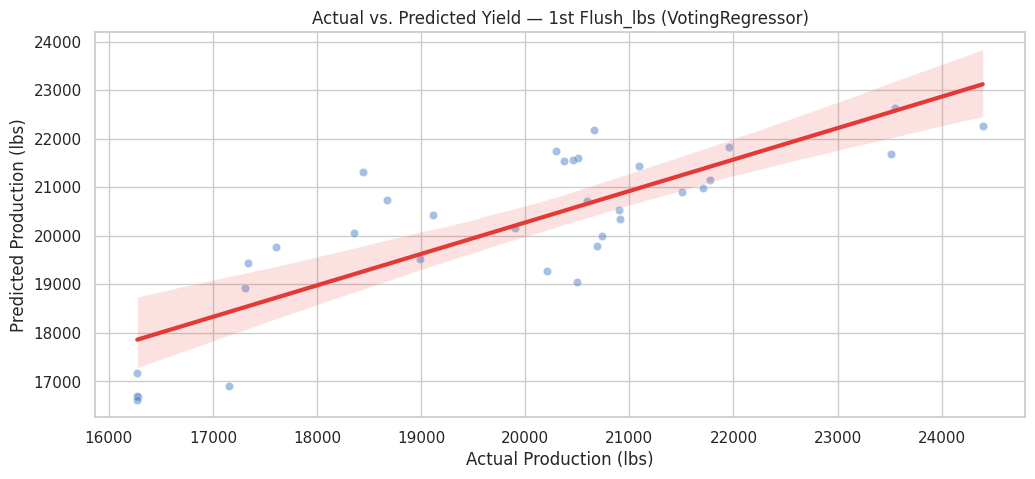


TARGET: 2nd Flush_lbs | Final model: AdaBoostRegressor
Test metrics -> R2: 0.3931 | RMSE: 930.5733 | MAE: 725.0814



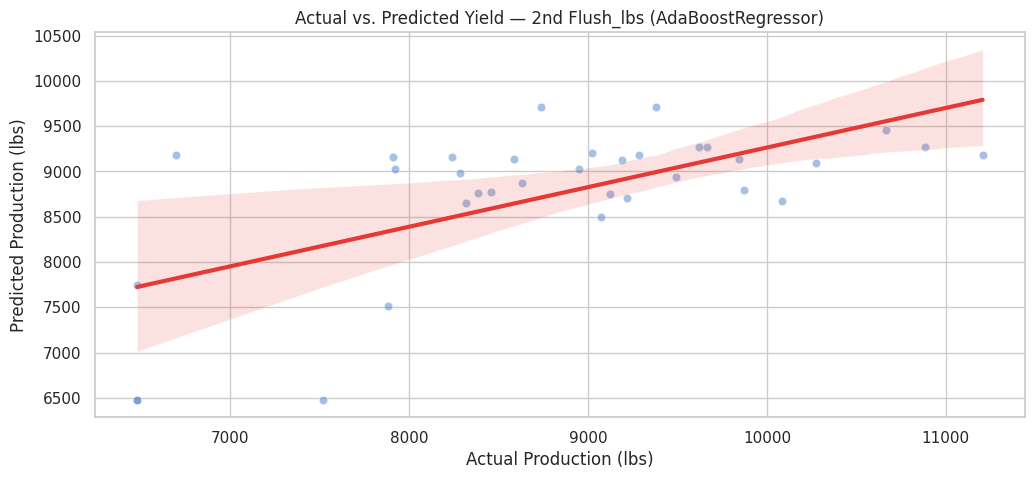


TARGET: 3rd Flush_lbs | Final model: RandomForestRegressor
Test metrics -> R2: 0.2483 | RMSE: 540.6830 | MAE: 400.1732



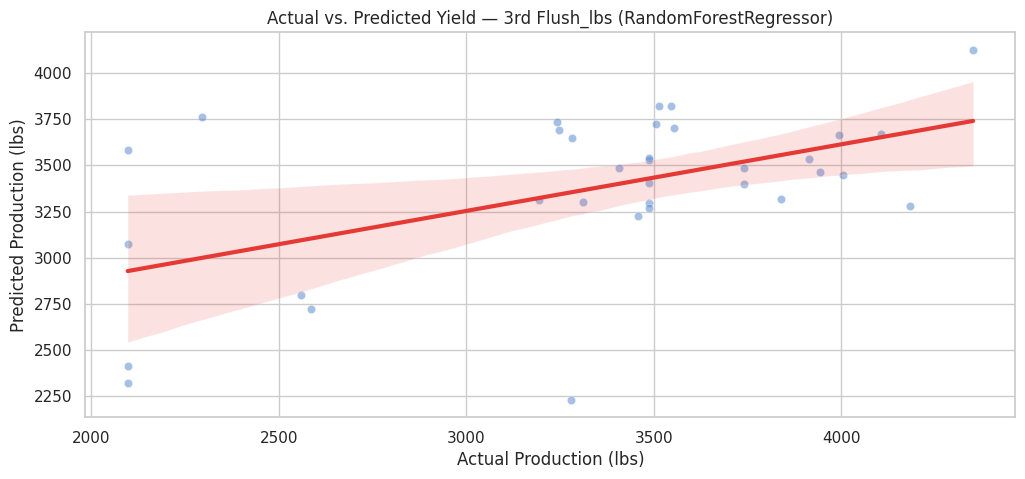

In [ ]:
for target, model in fitted_best_models.items():
    y_true = y_test[target]
    y_pred = model.predict(X_test_pre_pca)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    model_name = best_models_config[target]["Model_Name"]

    print("\n===================================================")
    print(f"TARGET: {target} | Final model: {model_name}")
    print(f"Test metrics -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    print("===================================================\n")

    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color="#4f83cc")
    sns.regplot(
        x=y_true,
        y=y_pred,
        scatter=False,
        color="#e53935",
        line_kws={"linewidth": 3},
        ci=95
    )

    plt.title(f"Actual vs. Predicted Yield — {target} ({model_name})")
    plt.xlabel("Actual Production (lbs)")
    plt.ylabel("Predicted Production (lbs)")
    plt.show()

**1st Flush_lbs — Actual vs. Predicted Yield (VotingRegressor)**

This plot shows a clear positive relationship between actual and predicted production for the first flush, which indicates that the model is capturing the main production pattern reasonably well. Most observations follow the expected trend, although there is still some dispersion, especially in a few medium- and high-yield cases.

From a business perspective, this is useful because the first flush usually represents the largest share of total production, so having a model that tracks this trend can support better harvest planning, labor allocation, packaging preparation, and short-term sales commitments. The remaining spread suggests that the model should be used as a decision-support tool rather than as an exact forecast for every individual case.

**2nd Flush_lbs — Actual vs. Predicted Yield (AdaBoostRegressor)**

For the second flush, the model also captures the general upward trend between actual and predicted yield, but the points appear more concentrated in a narrower prediction range. This suggests that the model recognizes the main direction of production changes, although it may smooth some variability and be less sensitive to very low or very high outcomes.

This means the model can still provide value for estimating expected second-flush production and improving operational planning, especially for labor, logistics, and inventory timing. However, because some extreme cases are not fully separated, managers should treat these predictions as an approximate planning reference and complement them with field knowledge when making higher-risk decisions.

**3rd Flush_lbs — Actual vs. Predicted Yield (RandomForestRegressor)**

This graph shows a positive relationship between actual and predicted yield for the third flush, meaning the model is able to detect the general production pattern even in a later and usually more variable harvest stage. At the same time, the dispersion around the trend line suggests that prediction uncertainty is higher for some observations, which is expected because third-flush yields are often smaller and less stable.

From a business perspective, this model is still valuable because it helps estimate whether the third flush is likely to produce enough output to justify labor, harvesting effort, and downstream handling. Even if predictions are not perfectly precise, they can support more informed operational decisions about resource allocation and production expectations in the final stage of the crop cycle.

### 2) Residuals vs Predicted

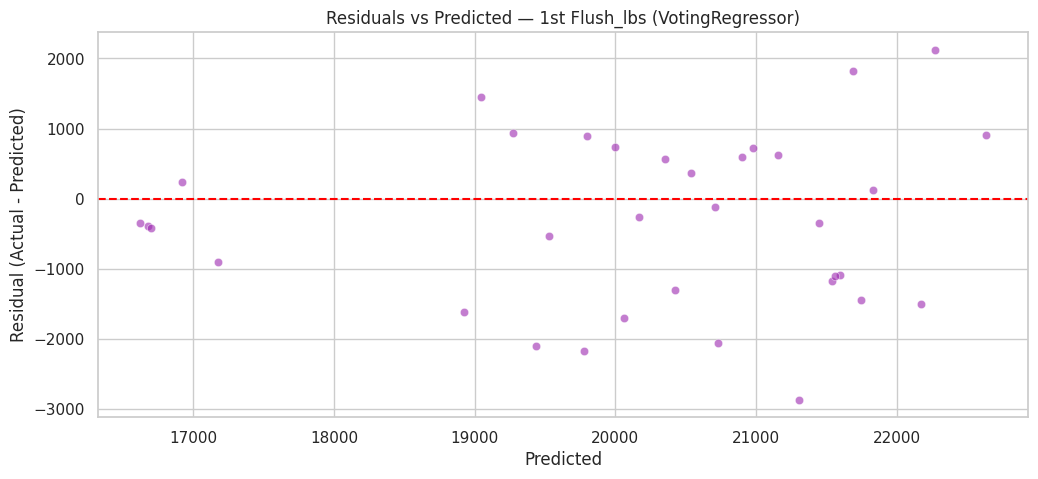

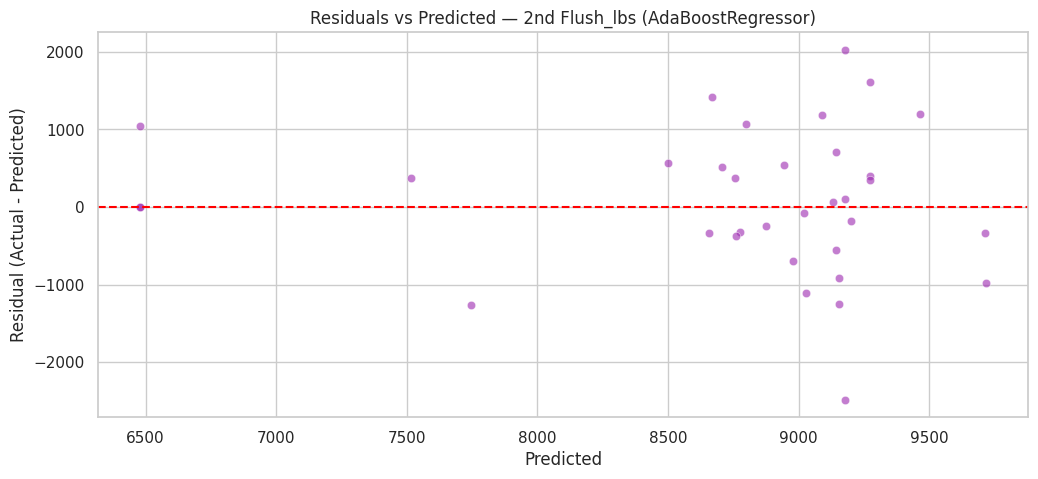

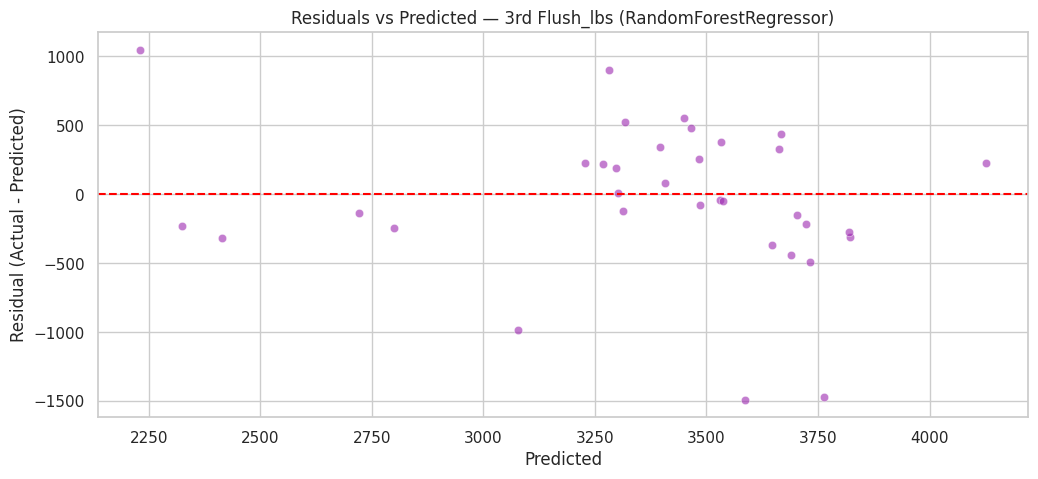

In [ ]:
for target, model in fitted_best_models.items():
    y_true = y_test[target]
    y_pred = model.predict(X_test_pre_pca)
    residuals = y_true - y_pred
    mean_residual = residuals.mean()
    model_name = best_models_config[target]["Model_Name"]

    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color="#9c27b0")
    plt.axhline(0, color="red", linestyle="--")

    plt.title(f"Residuals vs Predicted — {target} ({model_name})")
    plt.xlabel("Predicted")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.show()

**1st Flush_lbs — Residuals vs Predicted (VotingRegressor)**

Residuals are mostly distributed around zero, which suggests that the model does not show a strong systematic bias. However, some larger positive and negative errors are still present, meaning that a few cases are notably underpredicted or overpredicted.

From a business perspective, this means the model is useful for first-flush planning, such as labor, harvest scheduling, and sales preparation, but it should be used with some operational flexibility for unusual cases.

**2nd Flush_lbs — Residuals vs Predicted (AdaBoostRegressor)**

Residuals are also generally centered around zero, which indicates that the model is not consistently overestimating or underestimating production. Still, the spread of errors shows that prediction accuracy varies across observations.

From a business perspective, the model is valuable for general planning and expected supply estimation, but it should be treated as a support tool rather than an exact forecast in more sensitive decisions.

**3rd Flush_lbs — Residuals vs Predicted (RandomForestRegressor)**

The residuals for the third flush are also reasonably centered around zero, suggesting no severe systematic bias. Some larger errors remain, which is expected because later flushes tend to be more variable.

From a business perspective, the model still helps estimate whether remaining production justifies labor and harvesting effort, although decisions should remain cautious due to the higher uncertainty at this stage.

### 3) Residual Distribution

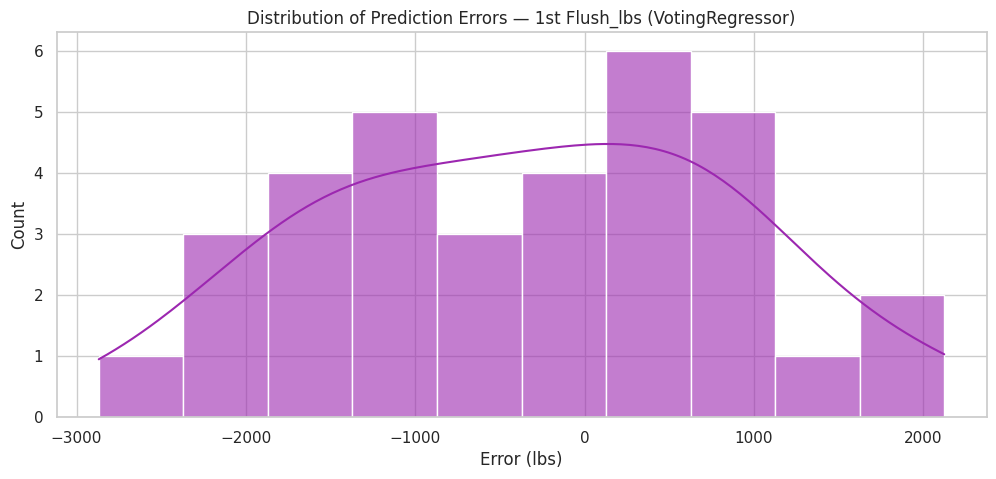

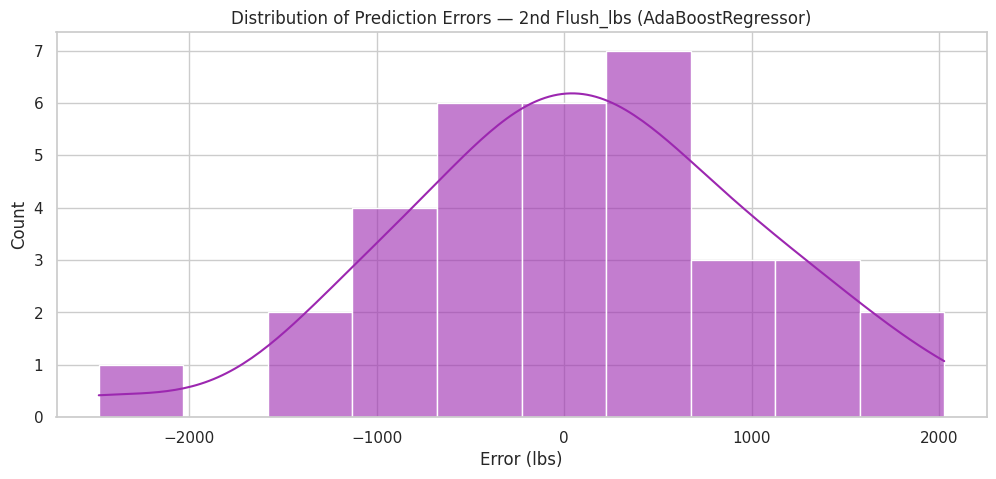

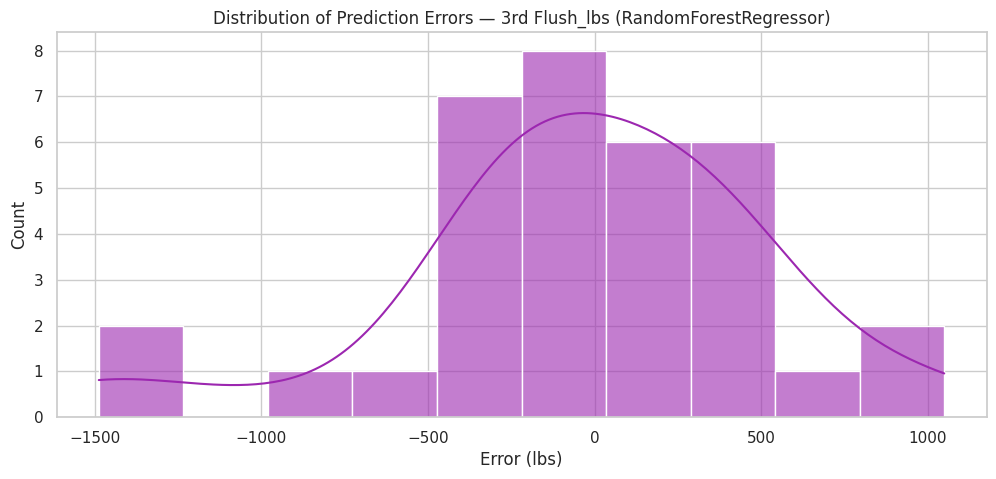

In [ ]:
for target, model in fitted_best_models.items():
    y_true = y_test[target]
    y_pred = model.predict(X_test_pre_pca)
    residuals = y_true - y_pred
    model_name = best_models_config[target]["Model_Name"]

    plt.figure(figsize=(12, 5))
    sns.histplot(
        residuals,
        bins=10,
        kde=True,
        color="#9c27b0",
        alpha=0.6,
        edgecolor="white"
    )
    plt.title(f"Distribution of Prediction Errors — {target} ({model_name})")
    plt.xlabel("Error (lbs)")
    plt.ylabel("Count")
    plt.show()

> Note: Some bars may appear missing or uneven because the test sample is relatively small and the residuals are not evenly distributed across all intervals. This means that some bins contain very few observations or none at all, which is normal in a histogram and does not indicate an error in the analysis.

**1st Flush_lbs — Distribution of Prediction Errors (VotingRegressor)**

Most errors are concentrated around zero, which suggests that the model is reasonably balanced and does not show a strong overall bias. However, the presence of some larger positive and negative errors indicates that a few first-flush cases are still harder to predict.

From a business perspective, this means the model is useful for planning expected first-flush output, but some buffer should remain in staffing, packaging, and commercial commitments.

**2nd Flush_lbs — Distribution of Prediction Errors (AdaBoostRegressor)**

The error distribution is also centered near zero, which suggests that the model provides a generally balanced forecast for the second flush. At the same time, the spread shows that some observations still have noticeable prediction error.

From a business perspective, this supports using the model for operational planning and supply estimation, while still leaving room for adjustment in cases with higher uncertainty.

**3rd Flush_lbs — Distribution of Prediction Errors (RandomForestRegressor)**

The third-flush errors are mostly concentrated around zero, although there are still some larger deviations on both sides. This is expected because later flushes are usually more variable and harder to predict.

From a business perspective, the model remains valuable for estimating remaining production and deciding how much effort to allocate to the final harvest stage, but with cautious expectations.

### 4) Feature Importance (Permutation Importance)

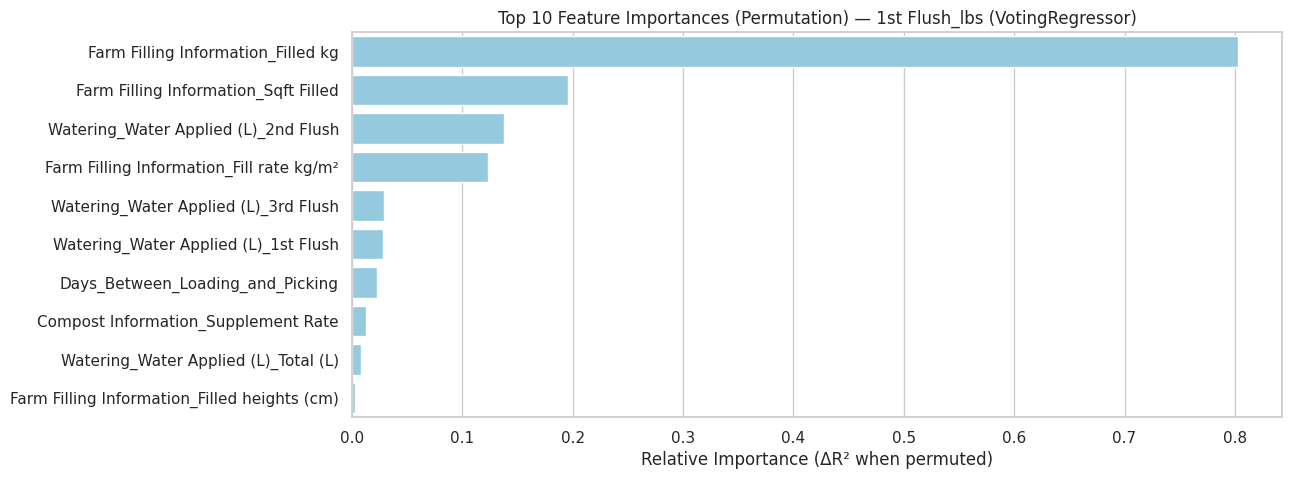

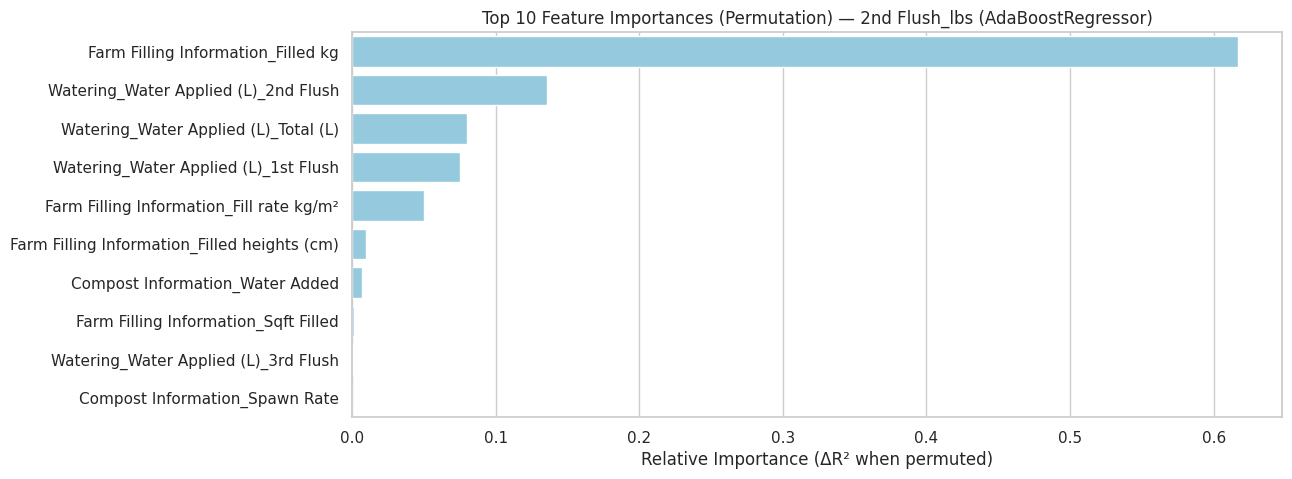

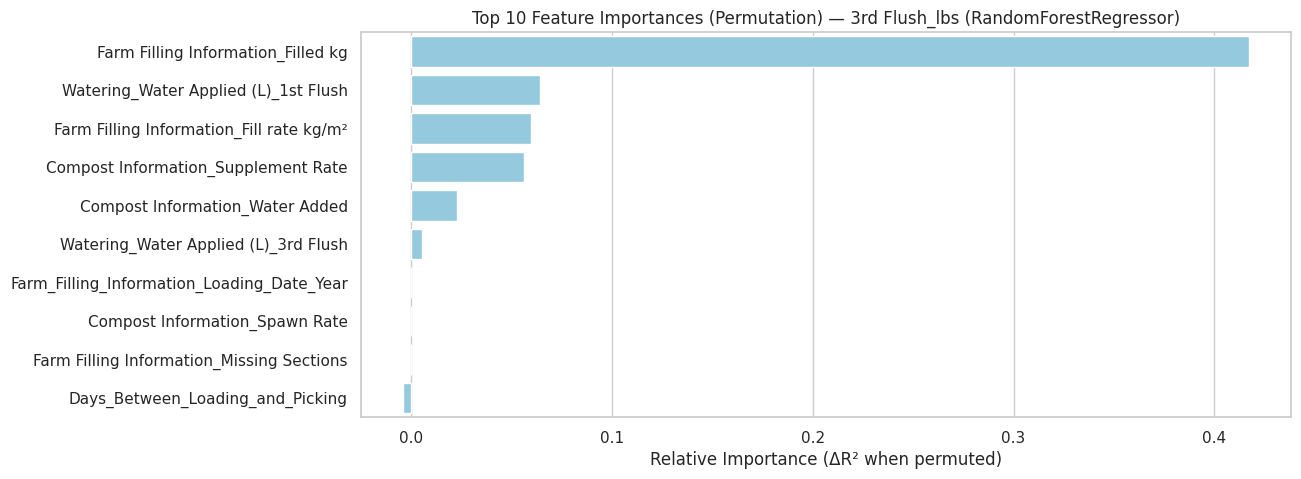

In [ ]:
TOP_N = 10

for target, model in fitted_best_models.items():
    y_true = y_test[target]
    model_name = best_models_config[target]["Model_Name"]

    perm = permutation_importance(
        model,
        X_test_pre_pca,
        y_true,
        n_repeats=10,
        random_state=42,
        scoring="r2",
        n_jobs=-1
    )

    if isinstance(X_test_pre_pca, pd.DataFrame):
        importances = pd.Series(
            perm.importances_mean,
            index=X_test_pre_pca.columns
        ).sort_values(ascending=False)
    else:
        importances = pd.Series(
            perm.importances_mean,
            index=[f"Feature_{i}" for i in range(X_test_pre_pca.shape[1])]
        ).sort_values(ascending=False)

    top_imp = importances.head(TOP_N)

    df_imp = top_imp.reset_index()
    df_imp.columns = ["Feature", "Importance"]
    df_imp = df_imp.sort_values("Importance", ascending=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=df_imp,
        x="Importance",
        y="Feature",
        color="#87ceeb",
        edgecolor="white"
    )
    plt.title(f"Top {TOP_N} Feature Importances (Permutation) — {target} ({model_name})")
    plt.xlabel("Relative Importance (ΔR² when permuted)")
    plt.ylabel("")
    plt.show()

    top_features = ", ".join(df_imp["Feature"].head(3).tolist())

**1st Flush_lbs — Permutation Feature Importance (VotingRegressor)**

**Filled kg** is the most important variable for predicting first-flush yield, followed by **Sqft Filled** and some watering and pin-count variables. This means the model is mainly driven by farm loading conditions and early production factors.

From a business perspective, this suggests that improving control over filling volume, space utilization, and early crop conditions could have the greatest impact on first-flush output.

**2nd Flush_lbs — Permutation Feature Importance ('AdaBoostRegressor')**

**Filled kg** remains the strongest predictor, while total watering and flush-specific watering variables are also important. This indicates that second-flush performance depends on both the initial load and water management during the cycle.

From a business perspective, this helps identify where operational control can improve production consistency and planning for later harvests.

**3rd Flush_lbs — Permutation Feature Importance (RandomForestRegressor)**

**Filled kg** is again the most influential variable, followed by fill rate, watering, supplement rate, and pin count. This shows that even late-stage production is still linked to controllable process variables.

From a business perspective, this helps managers focus on early-cycle decisions that can improve total yield and better judge whether the final flush is worth the remaining effort and cost.

## SHAP Plots

Let's create SHAP plots for the 2nd and 3rd flushes, the main target values where the company has some difficulty predicting the outcome. With these plots we will be able to see some of the features that have most importance for our best models.


--- Generating SHAP for specific model: 2nd Flush_lbs - AdaBoostRegressor (Tuned) ---
NaNs in X_test_shap after cleanup: 0
  Generating SHAP values for AdaBoostRegressor (Tuned)...
SHAP TreeExplainer failed: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._weight_boosting.AdaBoostRegressor'>
Trying KernelExplainer as fallback...


  0%|          | 0/34 [00:00<?, ?it/s]

/tmp/ipykernel_1461/3889118595.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain_sample, show=False)


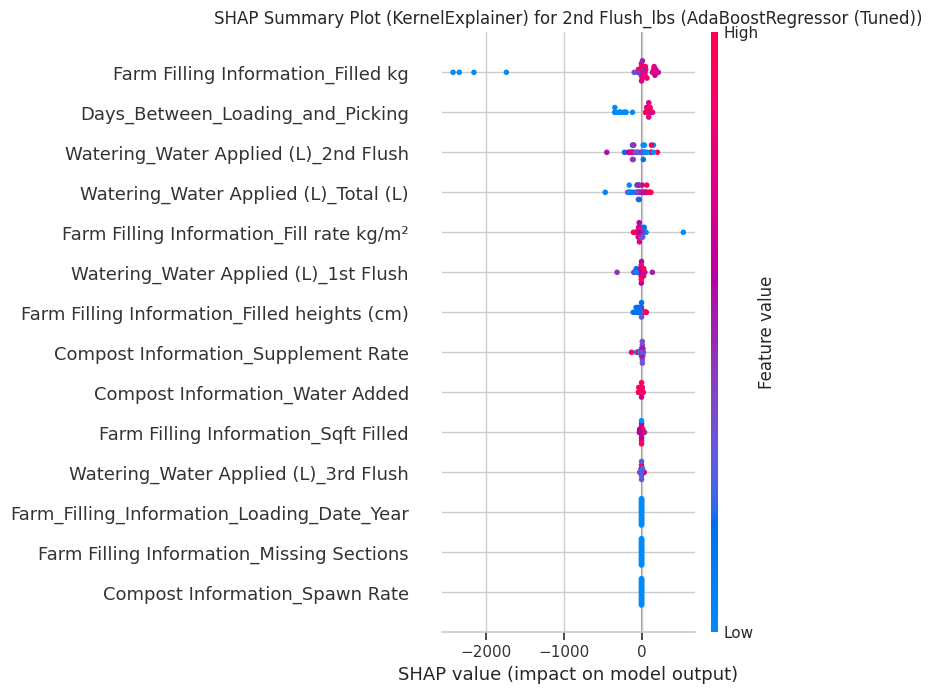


Finished generating specific SHAP plot.


In [ ]:
# Generate SHAP plot for: 2nd Flush_lbs - AdaBoostRegressor (Tuned)
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

specific_target = '2nd Flush_lbs'
specific_model_type = 'AdaBoostRegressor'
specific_model_full_name = specific_model_type + ' (Tuned)' # Adjusted for AdaBoostRegressor (Tuned)

print(f"\n--- Generating SHAP for specific model: {specific_target} - {specific_model_full_name} ---")

# Retrieve the already fitted model from the dictionary
fitted_model = fitted_best_models.get(specific_target)

if fitted_model is None:
    print(f"Error: Fitted model for {specific_target} not found in fitted_best_models.")
else:
    # -------------------------------------------------------
    # Ensure X_test_pre_pca is in DataFrame format for SHAP and numeric
    # -------------------------------------------------------
    if not isinstance(X_test_pre_pca, pd.DataFrame):
        X_test_shap = pd.DataFrame(X_test_pre_pca)
    else:
        X_test_shap = X_test_pre_pca.copy()

    X_test_shap = X_test_shap.apply(pd.to_numeric, errors='coerce').astype(float)
    # Fill NaNs if any appear after coercion (should be minimal after preprocessing)
    if X_test_shap.isna().sum().sum() > 0:
        # Use median from the training set (X_train_pre_pca) to fill NaNs, avoiding data leakage
        fill_values = X_train_pre_pca.median(numeric_only=True)
        X_test_shap = X_test_shap.fillna(fill_values)

    print(f"NaNs in X_test_shap after cleanup: {X_test_shap.isna().sum().sum()}")

    # -------------------------------------------------------
    # Generate SHAP values
    # -------------------------------------------------------
    print(f"  Generating SHAP values for {specific_model_full_name}...")

    try:
        # AdaBoostRegressor (with default DecisionTreeRegressor base) is tree-based.
        # TreeExplainer is more efficient for tree-based models.
        explainer = shap.TreeExplainer(fitted_model)

        # For tree explainers, shap_values can be directly calculated on X_test_shap
        # Take a sample if X_test_shap is too large for performance, but 50-item sample for background_data is usually sufficient
        if X_test_shap.shape[0] > 100: # Example threshold for sampling
            X_explain_sample = shap.sample(X_test_shap, 50, random_state=42)
            shap_values = explainer.shap_values(X_explain_sample)
        else:
            shap_values = explainer.shap_values(X_test_shap)

        print(f"  Displaying SHAP summary plot for {specific_model_full_name}.")
        plt.figure(figsize=(10, 8))
        # If shap_values is a list (for multi-output models like some tree explainers), use the first element
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_test_shap if X_test_shap.shape[0] <= 100 else X_explain_sample, show=False)
        else:
            shap.summary_plot(shap_values, X_test_shap if X_test_shap.shape[0] <= 100 else X_explain_sample, show=False)
        plt.title(f"SHAP Summary Plot for {specific_target} ({specific_model_full_name})")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"SHAP TreeExplainer failed: {e}")
        print("Trying KernelExplainer as fallback...")

        # Fallback to KernelExplainer which is model-agnostic
        background_data = shap.sample(X_train_pre_pca, min(50, len(X_train_pre_pca)), random_state=42)
        # For KernelExplainer, the explainer function should take input features and return predictions
        # Ensure it works correctly with the fitted_model
        explainer = shap.KernelExplainer(fitted_model.predict, background_data)

        X_explain_sample = shap.sample(X_test_shap, min(50, len(X_test_shap)), random_state=42)
        shap_values = explainer.shap_values(X_explain_sample, nsamples=100) # nsamples for approximation quality

        plt.figure(figsize=(10, 8))
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_explain_sample, show=False)
        else:
            shap.summary_plot(shap_values, X_explain_sample, show=False)
        plt.title(f"SHAP Summary Plot (KernelExplainer) for {specific_target} ({specific_model_full_name})")
        plt.tight_layout()
        plt.show()

print("\nFinished generating specific SHAP plot.")


--- Generating SHAP for specific model: 3rd Flush_lbs - RandomForestRegressor (without PCA) ---
  Generating SHAP values for RandomForestRegressor (without PCA)...
  Displaying SHAP summary plot for RandomForestRegressor (without PCA).


/tmp/ipykernel_1461/381977390.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_pre_pca, show=False)


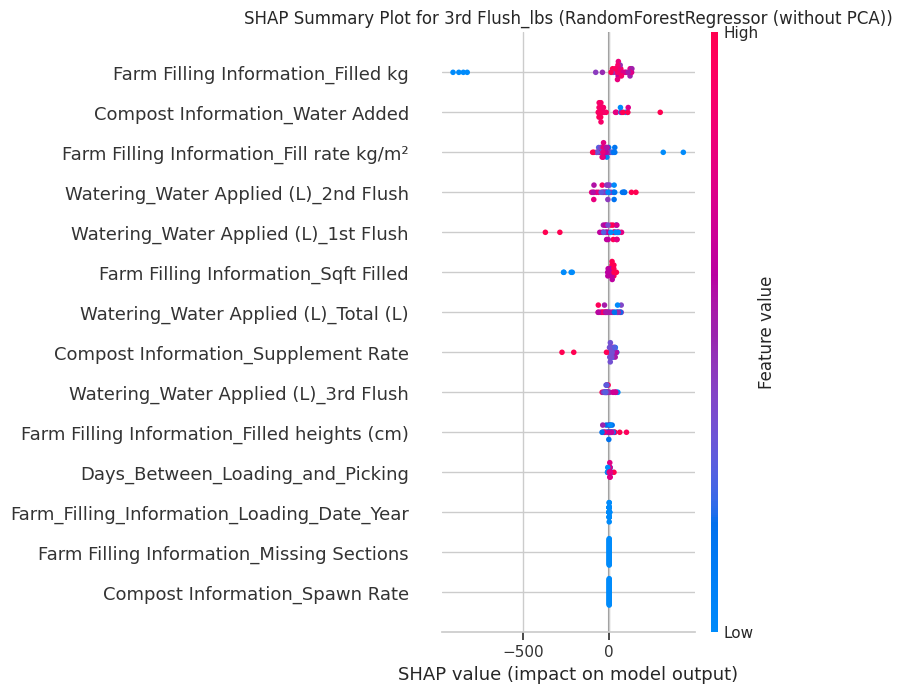


Finished generating specific SHAP plot.


In [ ]:
# Generate SHAP plot for the specific model requested by the user: '2nd Flush RandomForestRegressor (without PCA)'
import shap
import matplotlib.pyplot as plt

# Define the specific target and model type
specific_target = '3rd Flush_lbs'
specific_model_type = 'RandomForestRegressor'
specific_model_full_name = specific_model_type + ' (without PCA)'

print(f"\n--- Generating SHAP for specific model: {specific_target} - {specific_model_full_name} ---")

# Helper function to reconstruct a model given its name and parameters
def reconstruct_model(model_name_full, params):
    if 'RandomForestRegressor' in model_name_full:
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    elif 'Ridge' in model_name_full:
        return Ridge(**params, random_state=42)
    elif 'Lasso' in model_name_full:
        return Lasso(**params, random_state=42)
    elif 'DecisionTreeRegressor' in model_name_full:
        return DecisionTreeRegressor(**params, random_state=42)
    elif 'KNeighborsRegressor' in model_name_full:
        return KNeighborsRegressor(**params)
    elif 'SVR' in model_name_full:
        return SVR(**params)
    elif 'GradientBoostingRegressor' in model_name_full:
        return GradientBoostingRegressor(**params, random_state=42)
    elif 'Linear Regression' in model_name_full:
        return LinearRegression()
    else:
        raise ValueError(f"Unknown model type for reconstruction: {model_name_full}")

# Get the model entry from the tuned results (without PCA) for the specific model and target
model_entry = tuned_results_no_pca_df[
    (tuned_results_no_pca_df['Target'] == specific_target) &
    (tuned_results_no_pca_df['Model'] == specific_model_type)
]

if model_entry.empty:
    print(f"Error: Tuned {specific_model_type} for {specific_target} not found in tuned_results_no_pca_df.")
else:
    model_entry = model_entry.iloc[0]
    best_params = model_entry['Tuned_Best_Params']

    # Reconstruct the fitted model
    fitted_model = reconstruct_model(specific_model_type, best_params)
    fitted_model.fit(X_train_pre_pca, y_train[specific_target])

    print(f"  Generating SHAP values for {specific_model_full_name}...")

    # Determine explainer type (RandomForestRegressor is tree-based)
    explainer = shap.TreeExplainer(fitted_model)

    # Calculate SHAP values
    try:
        shap_values = explainer.shap_values(X_test_pre_pca)
    except Exception as e:
        print(f"  Error calculating SHAP values: {e}. Trying a smaller sample of X_test_pre_pca.")
        if X_test_pre_pca.shape[0] > 50:
            shap_values = explainer.shap_values(shap.sample(X_test_pre_pca, 50))
        else:
            raise e

    print(f"  Displaying SHAP summary plot for {specific_model_full_name}.")
    plt.figure(figsize=(10, 8))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X_test_pre_pca, show=False)
    else:
        shap.summary_plot(shap_values, X_test_pre_pca, show=False)
    plt.title(f"SHAP Summary Plot for {specific_target} ({specific_model_full_name})")
    plt.tight_layout()
    plt.show()

print("\nFinished generating specific SHAP plot.")

## Creation of HMI for customer to use model


Let's redefine the feature set `X` by dropping specified columns from `df_cleaned`, including target variables, previously excluded columns, and specific 'Stagger/Pincount' columns, to retain only controllable features for prediction. We will then filter `X` to ensure it contains only numerical data types and print its shape and columns to verify the changes.



In [ ]:
import pandas as pd
import numpy as np

# 1. Define target variables (y)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
y = df_cleaned[target_columns].copy()

# 2. Create a list columns_to_drop_from_X_base
# Columns explicitly dropped before to get to the initial X structure, excluding those that are now date features
columns_to_drop_from_X_base = target_columns + \
                         ['Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton', 'Total_Target','1st Flush_Day 1',
                          '1st Flush_Sep lbs', '1st Flush_Day 2', '1st Flush_Sep lbs_1', '1st Flush_Day 3',
                          '1st Flush_Day 4', '1st Flush_Day 5', '1st Flush_Day 6', '1st Flush_Day 7',
                          '1st Flush_Sep %', '1st Flush_lbs/sqft', '1st Flush_lbs/ton', '2nd Flush_Day 1',
                          '2nd Flush_Day 2', '2nd Flush_Day 3', '2nd Flush_Day 4', '2nd Flush_Day 5',
                          '2nd Flush_Day 6', '2nd Flush_Day 7', '2nd Flush_Day 8', '2nd Flush_Day 9', '2nd Flush_lbs/sqft',
                          '2nd Flush_lbs/ton', '3rd Flush_Day 1', '3rd Flush_Day 2', '3rd Flush_Day 3', '3rd Flush_Day 4',
                          '3rd Flush_Day 5', '3rd Flush_Day 6', '3rd Flush_Day 7', '3rd Flush_Day 8', '3rd Flush_Day 9',
                          '3rd Flush_lbs/sqft', '3rd Flush_lbs/ton', 'Farm Filling Information_Loading Date',
                          'Farm_Filling_Information_Loading_Date_Month','Farm_Filling_Information_Loading_Date_Day',
                          'Farm_Filling_Information_Loading_Date_DayOfWeek','Farm_Filling_Information_Loading_Date_WeekOfYear',
                          'Stagger/Pincount Info_Picking Date', 'Stagger/Pincount_Info_Picking_Date_Year'
                          ,'Stagger/Pincount_Info_Picking_Date_Month', 'Stagger/Pincount_Info_Picking_Date_Day',
                          'Stagger/Pincount_Info_Picking_Date_DayOfWeek','Stagger/Pincount_Info_Picking_Date_WeekOfYear',
                          'Stagger/Pincount Info_Picking Day_Actual','Stagger/Pincount Info_Picking Day_Target','Stagger/Pincount Info_Pin Count_Target'
                          'Stagger/Pincount Info_Stagger_Target','Stagger/Pincount Info_Stagger_Actual', 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons' ]

# 3. Create a list columns_to_remove_for_controllable_features
columns_to_remove_for_controllable_features = [
    'Stagger/Pincount Info_Stagger_Target',
    'Stagger/Pincount Info_Pin Count_Actual',
    'Stagger/Pincount Info_Pin Count_Target',
    'Stagger/Pincount Info_Stagger_Actual'
]

# 4. Combine all columns to drop
all_columns_to_drop_from_X = list(set(columns_to_drop_from_X_base + columns_to_remove_for_controllable_features))

# 5. Create X by dropping all identified columns
# Filter columns_to_drop to ensure only existing columns are dropped
existing_columns_to_drop = [col for col in all_columns_to_drop_from_X if col in df_cleaned.columns]
X = df_cleaned.drop(columns=existing_columns_to_drop, errors='ignore').copy()

# 6. Ensure only numerical and engineered categorical columns remain in X
X = X.select_dtypes(include=[np.number, pd.Int64Dtype()])

# 7. Print the shape of the new X DataFrame and a list of its column names
print(f"Shape of X after removing specified columns: {X.shape}")
print("New X columns:")
for col in X.columns.tolist():
    print(f"- {col}")

Shape of X after removing specified columns: (170, 14)
New X columns:
- Compost Information_Spawn Rate
- Compost Information_Supplement Rate
- Compost Information_Water Added
- Farm Filling Information_Sqft Filled
- Farm Filling Information_Missing Sections
- Farm Filling Information_Filled heights (cm)
- Farm Filling Information_Filled kg
- Farm Filling Information_Fill rate kg/m²
- Watering_Water Applied (L)_1st Flush
- Watering_Water Applied (L)_2nd Flush
- Watering_Water Applied (L)_3rd Flush
- Watering_Water Applied (L)_Total (L)
- Farm_Filling_Information_Loading_Date_Year
- Days_Between_Loading_and_Picking


Now, let's proceed with the data preparation steps, which include performing a train-test split on the newly defined `X` and `y`, applying `log1p` transformation, and then scaling the numerical features using `StandardScaler` without applying PCA. This will create `X_train_pre_pca` and `X_test_pre_pca` for subsequent model training.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 3. Rerun Data Preparation (without PCA)
# Re-run data splitting and transformations without PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Identify numerical columns in X_train for transformations
numerical_cols_X = X_train.columns

# Apply log1p transformation to numerical columns in X_train and X_test
for col in numerical_cols_X:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# --- ADDED: Impute NaNs introduced by log1p (e.g., from log1p(-1)) ---
for col in numerical_cols_X:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
    if X_test[col].isnull().any():
        # Use median from X_train to avoid data leakage
        median_val = X_train[col].median()
        X_test[col] = X_test[col].fillna(median_val)
# -------------------------------------------------------------------

# Store X_train and X_test before PCA for the 'no PCA' scenario
X_train_pre_pca = X_train.copy()
X_test_pre_pca = X_test.copy()

# Remove constant columns (zero variance) before scaling
constant_columns = X_train.columns[X_train.std() == 0]
if len(constant_columns) > 0:
    X_train_pre_pca = X_train_pre_pca.drop(columns=constant_columns)
    X_test_pre_pca = X_test_pre_pca.drop(columns=constant_columns)
    print(f"Removed constant columns with zero variance: {list(constant_columns)}")
else:
    print("No constant columns with zero variance found.")

# Initialize StandardScaler, fit on X_train_pre_pca, and transform both
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train_pre_pca)
X_test_scaled_array = scaler.transform(X_test_pre_pca)

# Convert scaled arrays back to DataFrame, retaining column names and index
X_train_pre_pca = pd.DataFrame(X_train_scaled_array, columns=X_train_pre_pca.columns, index=X_train_pre_pca.index)
X_test_pre_pca = pd.DataFrame(X_test_scaled_array, columns=X_test_pre_pca.columns, index=X_test_pre_pca.index)

print("Applied StandardScaler to numerical columns.")
print(f"Final shape of X_train_pre_pca: {X_train_pre_pca.shape}")
print(f"Final shape of X_test_pre_pca: {X_test_pre_pca.shape}")


Shape of X_train: (136, 14)
Shape of X_test: (34, 14)
Shape of y_train: (136, 3)
Shape of y_test: (34, 3)
No constant columns with zero variance found.
Applied StandardScaler to numerical columns.
Final shape of X_train_pre_pca: (136, 14)
Final shape of X_test_pre_pca: (34, 14)


Now, we will reconstruct and fit the best models ('DecisionTreeRegressor' for 1st flush, 'AdaBoostRegressor' for 2nd, and 'RandomForestRegressor' for the 3rd flush) using the `X_train_pre_pca` data (scaled and log1p-transformed without PCA) and the respective target variables from `y_train`. These fitted models will be stored in the `fitted_best_models` dictionary.



In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor
import numpy as np

# Dictionary to store the fitted best models
fitted_best_models = {}

# Helper function to create individual model instances with hyperparameters
def _create_base_model_instance(model_name, params):
    if model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(random_state=42, **params)
    elif model_name == 'RandomForestRegressor':
        return RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    elif model_name == 'Lasso':
        return Lasso(random_state=42, **params)
    elif model_name == 'Ridge':
        return Ridge(random_state=42, **params)
    elif model_name == 'SVR':
        return SVR(**params)
    elif model_name == 'KNeighborsRegressor':
        return KNeighborsRegressor(**params)
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(random_state=42, **params)
    elif model_name == 'AdaBoostRegressor':
        return AdaBoostRegressor(random_state=42, **params)
    elif model_name == 'Linear Regression': # Assuming default Linear Regression
        return LinearRegression()
    else:
        raise ValueError(f"Unknown model type for base estimator reconstruction: {model_name}")

# Helper function to reconstruct and fit a model
def reconstruct_and_fit_model_v2(config, X_train_data, y_train_target):
    model_name = config['Model_Name']
    hyperparameters = config.get('Hyperparameters', {})

    model = None
    if model_name == 'DecisionTreeRegressor':
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'RandomForestRegressor':
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'AdaBoostRegressor': # Added this condition
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'VotingRegressor':
        estimators = []
        for est_name, est_params in hyperparameters.get('estimators', []):
            # The `est_name` comes from the dictionary, e.g., 'decisiontree', 'randomforest'
            # We need to map it back to the full class name for _create_base_model_instance
            full_est_name = None
            if 'decisiontree' in est_name: full_est_name = 'DecisionTreeRegressor'
            elif 'randomforest' in est_name: full_est_name = 'RandomForestRegressor'
            elif 'lasso' in est_name: full_est_name = 'Lasso'
            elif 'ridge' in est_name: full_est_name = 'Ridge'
            elif 'svr' in est_name: full_est_name = 'SVR'
            elif 'kneighbors' in est_name: full_est_name = 'KNeighborsRegressor'
            elif 'gradientboosting' in est_name: full_est_name = 'GradientBoostingRegressor'
            elif 'adaboost' in est_name: full_est_name = 'AdaBoostRegressor'

            if full_est_name:
                estimators.append((est_name, _create_base_model_instance(full_est_name, est_params)))
            else:
                print(f"Warning: Could not identify full model name for base estimator '{est_name}'. Skipping.")

        weights = hyperparameters.get('weights')
        if estimators:
            model = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)
        else:
            print(f"Warning: No valid estimators for VotingRegressor for target {y_train_target.name}. Skipping.")
            return None

    elif model_name == 'StackingRegressor':
        estimators = []
        for est_name, est_params in hyperparameters.get('estimators', []):
            # Map short name to full class name
            full_est_name = None
            if 'randomforest' in est_name: full_est_name = 'RandomForestRegressor'
            elif 'lasso' in est_name: full_est_name = 'Lasso'
            elif 'ridge' in est_name: full_est_name = 'Ridge'
            elif 'decisiontree' in est_name: full_est_name = 'DecisionTreeRegressor'
            elif 'adaboost' in est_name: full_est_name = 'AdaBoostRegressor'

            if full_est_name:
                estimators.append((est_name, _create_base_model_instance(full_est_name, est_params)))
            else:
                print(f"Warning: Could not identify full model name for base estimator '{est_name}'. Skipping.")

        final_estimator_config = hyperparameters.get('final_estimator', {})
        final_estimator_name = final_estimator_config.get('name')
        final_estimator_params = {k: v for k, v in final_estimator_config.items() if k != 'name'}

        final_estimator_instance = None
        if final_estimator_name == 'Ridge':
            final_estimator_instance = Ridge(**final_estimator_params)

        if estimators and final_estimator_instance:
            model = StackingRegressor(estimators=estimators, final_estimator=final_estimator_instance, n_jobs=-1)
        else:
            print(f"Warning: StackingRegressor for target {y_train_target.name} could not be fully configured. Skipping.")
            return None

    if model is None:
        print(f"Skipping model reconstruction for {model_name}. No Scikit-learn model equivalent or handler.")
        return None

    # Fit the model
    model.fit(X_train_data, y_train_target)
    return model

for target, config in best_models_config.items():
    print(f"Reconstructing and fitting model for {target}...")

    # For this specific task, all models are specified to be 'without PCA',
    # so we always use X_train_pre_pca
    X_data = X_train_pre_pca

    fitted_model = reconstruct_and_fit_model_v2(config, X_data, y_train[target])
    if fitted_model is not None:
        fitted_best_models[target] = fitted_model

print("\nFitted best models for each target variable (user-specified, no PCA):")
for target, model_obj in fitted_best_models.items():
    print(f"- {target}: {model_obj}")

Reconstructing and fitting model for 1st Flush_lbs...
Reconstructing and fitting model for 2nd Flush_lbs...
Reconstructing and fitting model for 3rd Flush_lbs...

Fitted best models for each target variable (user-specified, no PCA):
- 1st Flush_lbs: VotingRegressor(estimators=[('decisiontree',
                             DecisionTreeRegressor(max_depth=10,
                                                   min_samples_split=10,
                                                   random_state=42)),
                            ('randomforest',
                             RandomForestRegressor(max_depth=20, n_jobs=-1,
                                                   random_state=42))],
                n_jobs=-1,
                weights=[np.float64(0.6674672895180437),
                         np.float64(0.591067473443388)])
- 2nd Flush_lbs: AdaBoostRegressor(learning_rate=0.5, random_state=42)
- 3rd Flush_lbs: RandomForestRegressor(max_depth=10, max_features=0.8, n_estimators=200,
    

Finally, let's create the interactive interface where the user is going to set the parameters the company wants to use for the prediction.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from datetime import datetime

# Re-define helper functions for input preprocessing, ensuring they are available in this scope
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    numbers.append(num / 100)
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

print("Preprocessing helper functions defined.")


# --- 1. Define Input Widgets for the Features in X_train_pre_pca ---

# Get the feature names in the correct order as expected by the models
feature_names = X_train_pre_pca.columns.tolist()

# Create a dictionary to hold input widgets
input_widgets = {}

# Recreate default values based on the *new* X features
def get_default_values(): # Changed to a function to encapsulate logic
    dv = {}
    for col in feature_names:
        if col in X.columns: # Use the original X (before log1p for medians) for default values
            if pd.api.types.is_numeric_dtype(X[col]):
                dv[col] = X[col].median()
            else:
                # For object types, assign a sensible default or median of processed values
                if col == 'Compost Information_Supplement Rate':
                    dv[col] = '0.0135' # Median after processing
                elif col == 'Compost Information_Water Added':
                    dv[col] = '5.14' # Median after processing
                elif col == 'Farm Filling Information_Filled heights (cm)':
                    dv[col] = '29' # Median after processing
                else:
                    dv[col] = '' # Fallback for other object types, though should be handled by now
        else:
            dv[col] = 0 # Fallback for any unexpected new features
    return dv

current_default_values = get_default_values()

# Generate widgets, ensuring full names are displayed
for feature in feature_names:
    truncated_description = feature.replace('_', ' ').title()
    common_style = {'description_width': 'initial'}
    common_layout = widgets.Layout(width='500px')

    if feature in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        input_widgets[feature] = widgets.Text(
            description=truncated_description,
            value=str(current_default_values.get(feature, '')),
            layout=common_layout
        )
    elif 'Year' in feature or 'Day' in feature: # Check for int-like features
        input_widgets[feature] = widgets.IntText(
            description=truncated_description,
            value=int(current_default_values.get(feature, 0)),
            layout=common_layout
        )
    else:
        input_widgets[feature] = widgets.FloatText(
            description=truncated_description,
            value=float(current_default_values.get(feature, 0.0)),
            layout=common_layout
        )

# --- 2. Define Preprocessing Function for User Input ---
def preprocess_input(input_values):
    # Create a DataFrame from the input values to maintain column order and structure
    input_df = pd.DataFrame([input_values], columns=feature_names)

    # Apply mixed-type parsing functions as done in preprocessing
    if 'Compost Information_Supplement Rate' in input_df.columns:
        input_df['Compost Information_Supplement Rate'] = input_df['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)
    if 'Compost Information_Water Added' in input_df.columns:
        input_df['Compost Information_Water Added'] = input_df['Compost Information_Water Added'].apply(parse_and_average_number)
    if 'Farm Filling Information_Filled heights (cm)' in input_df.columns:
        input_df['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(input_df['Farm Filling Information_Filled heights (cm)'], errors='coerce')

    # Impute NaNs with medians from training data (if any arise from parsing user input)
    # Use medians from X (pre-log1p, pre-scaling) for imputation of raw values
    for col in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        if col in input_df.columns and input_df[col].isnull().any():
            if col in X.columns:
                median_val = X[col].median()
                input_df[col] = input_df[col].fillna(median_val)

    # Apply log1p transformation to relevant numerical columns
    for col in feature_names:
        input_df[col] = np.log1p(input_df[col])

    # Scale the input using the fitted scaler
    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=feature_names)

    return input_scaled_df

# --- 3. Define the Prediction Function for the HMI ---
def predict_yield(**kwargs):
    # Convert kwargs to a dictionary of input values
    input_values = {name: value for name, value in kwargs.items()}

    # Preprocess the input data
    preprocessed_input_scaled_df = preprocess_input(input_values)

    results = []
    total_predicted_lbs = 0

    for target in target_columns:
        config = best_models_config[target]
        model = fitted_best_models[target]

        # For this task, all specified models use 'Used_PCA': False
        # So we always use preprocessed_input_scaled_df directly without PCA
        input_for_prediction_df = preprocessed_input_scaled_df

        # Make prediction
        predicted_lbs = model.predict(input_for_prediction_df)[0]

        results.append(f"<li><b>{target}</b>: {predicted_lbs:.2f} lbs</li>")
        total_predicted_lbs += predicted_lbs

    display(HTML(f"<h3>Prediction Results:</h3><ul>" + "".join(results) + f"<li><b>Total Predicted (all flushes)</b>: {total_predicted_lbs:.2f} lbs</li></ul>"))

# --- 4. Create and Display the Interactive HMI ---
# Arrange widgets in a VBox
input_widgets_list = [input_widgets[feature] for feature in feature_names]

# Add a button to trigger prediction (optional, interact does it automatically when values change)
predict_button = widgets.Button(description="Predict Yield")
output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        output_area.clear_output()
        predict_yield(**{name: widget.value for name, widget in input_widgets.items()})

predict_button.on_click(on_button_click)

# Display the widgets and button
display(widgets.VBox(input_widgets_list + [predict_button, output_area]))

print("Interactive HMI created successfully with updated inputs and models (no PCA).")

Preprocessing helper functions defined.


Interactive HMI created successfully with updated inputs and models (no PCA).


# Export of model and prediction tool
Now, let's save the trained `fitted_best_models` and `scaler` objects and generate a standalone `prediction_tool.py` script containing the necessary code and an interactive Human-Machine Interface (HMI) for predicting mushroom yield. Then, provide detailed instructions to the user on how to save and run this script locally, along with required library installations.

## Save Trained Models and Scaler

First, we need to import the `joblib` library to handle saving Python objects to disk. Then, I will save the `fitted_best_models` dictionary and the `scaler` object to their respective `.pkl` files.



In [ ]:
import joblib

# Save the fitted_best_models dictionary
joblib.dump(fitted_best_models, 'fitted_best_models.pkl')
print("fitted_best_models dictionary saved to fitted_best_models.pkl")

# Save the scaler object
joblib.dump(scaler, 'scaler.pkl')
print("scaler object saved to scaler.pkl")

fitted_best_models dictionary saved to fitted_best_models.pkl
scaler object saved to scaler.pkl


## Generate Standalone Prediction Script


Now, we require to generate a self-contained Python script named `prediction_tool.py` that includes all necessary code for predicting mushroom yield with an interactive HMI using `ipywidgets`. This involves consolidating imports, helper functions, model configurations, data loading, HMI widget definitions, preprocessing logic, and the prediction function into a single string. The `best_models_config` and `scaler` object (implicitly `hardcoded_medians_for_defaults`) are essential for the HMI default values and model structure.



In [ ]:
prediction_tool_script = """import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# sklearn imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler

# ipywidgets for the HMI
import ipywidgets as widgets
from IPython.display import display, HTML

# --- Helper functions ---
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    numbers.append(num / 100)
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

# --- Configuration ---
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# This dictionary is used to understand which models are chosen per target.
# The actual fitted models are loaded from 'fitted_best_models.pkl'.
best_models_config = {
    '1st Flush_lbs': {
        'Model_Name': 'VotingRegressor',
        'R2_Test': np.float64(0.6292673814807158),
        'RMSE_Test': np.float64(1291.7360242833538),
        'MAE_Test': np.float64(1013.4678302505083),
        'Hyperparameters': {
            'estimators': [
                ('decisiontree', {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}),
                ('randomforest', {'max_depth': 20, 'max_features': 1.0, 'n_estimators': 100})
            ],
            'weights': [
                np.float64(0.6674672895180437),
                np.float64(0.5910674734433877)
            ]
        },
        'Used_PCA': False
    },
    '2nd Flush_lbs': {
        'Model_Name': 'AdaBoostRegressor',
        'R2_Test': np.float64(0.2936465483462669),
        'RMSE_Test': np.float64(1003.8953792876476),
        'MAE_Test': np.float64(782.6941882270279),
        'Hyperparameters': {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 50},
        'Used_PCA': False
    },
    '3rd Flush_lbs': {
        'Model_Name': 'RandomForestRegressor',
        'R2_Test': np.float64(0.35977649664884237),
        'RMSE_Test': np.float64(498.9731067656133),
        'MAE_Test': np.float64(386.3018207404298),
        'Hyperparameters': {'max_depth': 10, 'max_features': 0.8, 'n_estimators': 200},
        'Used_PCA': False
    }
}

# --- Load Fitted Models and Scaler ---
try:
    fitted_best_models = joblib.load('fitted_best_models.pkl')
    scaler = joblib.load('scaler.pkl')
    print("Models and scaler loaded successfully.")
except FileNotFoundError:
    print("Error: Model or scaler files not found. Make sure 'fitted_best_models.pkl' and 'scaler.pkl' are in the same directory.")
    exit() # Exit if essential files are missing

# --- Feature Names and Default Values ---
# These features correspond to X_train_pre_pca.columns and need to be in the exact order
feature_names = [
    'Compost Information_Spawn Rate', 'Compost Information_Supplement Rate',
    'Compost Information_Water Added', 'Farm Filling Information_Sqft Filled',
    'Farm Filling Information_Missing Sections', 'Farm Filling Information_Filled heights (cm)',
    'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²',
    'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush',
    'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)',
    'Farm_Filling_Information_Loading_Date_Year', 'Days_Between_Loading_and_Picking'
]

# Hardcoded median values from the original X dataframe (before log1p/scaling)
# These are used as default values for the HMI to represent typical inputs
hardcoded_medians_for_defaults = {
    'Compost Information_Spawn Rate': 15.015348245,
    'Compost Information_Supplement Rate': 0.0135,
    'Compost Information_Water Added': 5.140000000000001,
    'Farm Filling Information_Sqft Filled': 4647.0,
    'Farm Filling Information_Missing Sections': 2.0,
    'Farm Filling Information_Filled heights (cm)': 29.0,
    'Farm Filling Information_Filled kg': 38140.0,
    'Farm Filling Information_Fill rate kg/m²': 88.779087905,
    'Watering_Water Applied (L)_1st Flush': 22.0,
    'Watering_Water Applied (L)_2nd Flush': 14.5,
    'Watering_Water Applied (L)_3rd Flush': 9.0,
    'Watering_Water Applied (L)_Total (L)': 31.0,
    'Farm_Filling_Information_Loading_Date_Year': 2025.0,
    'Days_Between_Loading_and_Picking': 15.0
}

def get_default_values():
    return hardcoded_medians_for_defaults

# --- Define Input Widgets for the Features ---
input_widgets = {}
current_default_values = get_default_values()

for feature in feature_names:
    truncated_description = feature.replace('_', ' ').title()
    common_layout = widgets.Layout(width='500px')

    # Specific handling for features that originally had complex string formats or special types
    if feature in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        input_widgets[feature] = widgets.Text(
            description=truncated_description,
            value=str(current_default_values.get(feature, '')),
            layout=common_layout
        )
    elif 'Year' in feature or 'Day' in feature or 'Week' in feature:
        input_widgets[feature] = widgets.IntText(
            description=truncated_description,
            value=int(current_default_values.get(feature, 0)),
            layout=common_layout
        )
    else: # Default for all other numerical features
        input_widgets[feature] = widgets.FloatText(
            description=truncated_description,
            value=float(current_default_values.get(feature, 0.0)),
            layout=common_layout
        )

# --- Define Preprocessing Function for User Input ---
def preprocess_input(input_values_dict):
    # Create a DataFrame from the input values to maintain column order and structure
    input_df = pd.DataFrame([input_values_dict], columns=feature_names)

    # Apply mixed-type parsing functions
    if 'Compost Information_Supplement Rate' in input_df.columns:
        input_df['Compost Information_Supplement Rate'] = input_df['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)
    if 'Compost Information_Water Added' in input_df.columns:
        input_df['Compost Information_Water Added'] = input_df['Compost Information_Water Added'].apply(parse_and_average_number)
    if 'Farm Filling Information_Filled heights (cm)' in input_df.columns:
        input_df['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(input_df['Compost Information_Filled heights (cm)'], errors='coerce')

    # Impute NaNs for specific columns using hardcoded medians (pre-log1p values)
    for col in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        if col in input_df.columns and input_df[col].isnull().any():
            input_df[col] = input_df[col].fillna(hardcoded_medians_for_defaults.get(col, 0.0))

    # Apply log1p transformation to all numerical columns.
    for col in feature_names:
        input_df[col] = np.log1p(input_df[col])
        # Fallback for log1p-introduced NaNs (if any, e.g. from negative inputs or invalid parsing results)
        if input_df[col].isnull().any():
            # Fill with log1p of the hardcoded median for that feature
            input_df[col] = input_df[col].fillna(np.log1p(hardcoded_medians_for_defaults.get(col, 0.0)))

    # Scale the input using the fitted scaler
    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=feature_names)

    return input_scaled_df

# --- Define the Prediction Function for the HMI ---
def predict_yield(**kwargs):
    input_values = {name: value for name, value in kwargs.items()}
    preprocessed_input_scaled_df = preprocess_input(input_values)

    results = []
    total_predicted_lbs = 0

    for target in target_columns:
        model = fitted_best_models[target] # Use the loaded fitted model directly
        predicted_lbs = model.predict(preprocessed_input_scaled_df)[0]
        results.append(f"<li><b>{target}</b>: {predicted_lbs:.2f} lbs</li>")
        total_predicted_lbs += predicted_lbs

    display(HTML(f"<h3>Prediction Results:</h3><ul>" + "".join(results) + f"<li><b>Total Predicted (all flushes)</b>: {total_predicted_lbs:.2f} lbs</li></ul>"))

# --- Create and Display the Interactive HMI ---
input_widgets_list = [input_widgets[feature] for feature in feature_names]

predict_button = widgets.Button(description="Predict Yield")
output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        output_area.clear_output()
        current_input_values = {name: widget.value for name, widget in input_widgets.items()}
        predict_yield(**current_input_values)

predict_button.on_click(on_button_click)

print("Interactive HMI generated. Copy and save the following script as 'prediction_tool.py'.")
display(widgets.VBox(input_widgets_list + [predict_button, output_area]))"""

print(prediction_tool_script)

import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# sklearn imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler

# ipywidgets for the HMI
import ipywidgets as widgets
from IPython.display import display, HTML

# --- Helper functions ---
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    numbers.append(num / 100)
                except ValueError:
                    continue
            if num

## Instructions to User

1.  **Save the Script:** Copy the entire output from the previous cell (the Python code string) and paste it into a new text file. Save this file as `prediction_tool.py` in a directory of your choice.
2.  **Ensure Model and Scaler Files are Present:** Make sure that the `fitted_best_models.pkl` and `scaler.pkl` files (generated in the 'Save Trained Models and Scaler' step) are in the *same directory* as your `prediction_tool.py` script.
3.  **Install Required Libraries:** Open your terminal or command prompt and navigate to the directory where you saved `prediction_tool.py`. Run the following command to install all necessary Python libraries:
    `pip install pandas numpy scikit-learn ipywidgets jupyter`
    (Note: `ipywidgets` and `jupyter` are needed to render the interactive HMI in a compatible environment like Jupyter Notebook or JupyterLab, which is typically used for running `.py` scripts containing `ipywidgets`).
4.  **Run the Script:** To run the interactive HMI, execute the following command in your terminal within a Jupyter environment (e.g., Jupyter Notebook, JupyterLab):
    `jupyter notebook` or `jupyter lab`
    Once the Jupyter interface opens in your browser, navigate to the directory where you saved `prediction_tool.py`. Open the Python script (`prediction_tool.py`) within Jupyter. The interactive widgets should then appear, allowing you to input values and get predictions.